In [69]:
from __future__ import division, print_function, unicode_literals
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder, StandardScaler
import time
import pandas as pd
import cv2
from mpl_toolkits.mplot3d import Axes3D
import gzip
import struct
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import mean_squared_error, r2_score

# ANN cho bài toán phân loại

## Ví dụ 1

In [4]:
N = 200 # number of points per class
d = 2 # dimensionality
C = 3 # number of classes
X = np.zeros((d, N*C)) # data matrix (each row = single example)
y = np.zeros(N*C, dtype='uint8') # class labels

for j in range(C):
    ix = range(N*j,N*(j+1))
    r = np.linspace(0.0,1,N) # radius
    t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
    X[:,ix] = np.c_[r*np.sin(t), r*np.cos(t)].T
    y[ix] = j

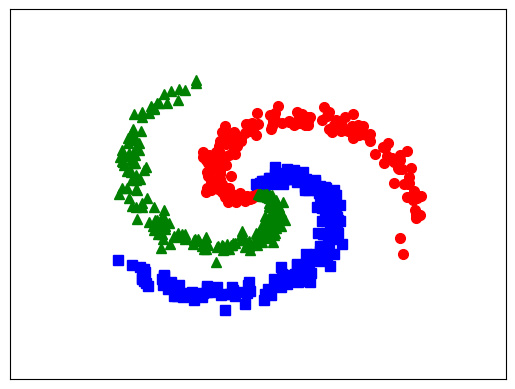

In [5]:
# lets visualize the data:
plt.plot(X[0, :N], X[1, :N], 'bs', markersize = 7);
plt.plot(X[0, N:2*N], X[1, N:2*N], 'ro', markersize = 7);
plt.plot(X[0, 2*N:], X[1, 2*N:], 'g^', markersize = 7);

plt.xlim([-1.5, 1.5])
plt.ylim([-1.5, 1.5])
cur_axes = plt.gca()
cur_axes.axes.get_xaxis().set_ticks([])
cur_axes.axes.get_yaxis().set_ticks([])

plt.savefig('example_points.png', bbox_inches='tight', dpi = 600)
plt.show()

In [6]:
def softmax(V):
    e_V = np.exp(V - np.max(V, axis = 0, keepdims = True))
    Z = e_V / e_V.sum(axis = 0)
    return Z

def cost(Y, Yhat):
    return -np.sum(Y*np.log(Yhat))/Y.shape[1]

from scipy import sparse
def convert_labels(y, C = 3):
    Y = sparse.coo_matrix((np.ones_like(y),
    (y, np.arange(len(y)))), shape = (C, len(y))).toarray()
    return Y

In [7]:
d0 = 2
d1 = h = 100 # size of hidden layer
d2 = C = 3
# initialize parameters randomly
W1 = 0.01*np.random.randn(d0, d1)
b1 = np.zeros((d1, 1))
W2 = 0.01*np.random.randn(d1, d2)
b2 = np.zeros((d2, 1))

Y = convert_labels(y, C)
N = X.shape[1]
eta = 1 # learning rate

In [8]:
for i in range(10000):
    ## Feedforward
    Z1 = np.dot(W1.T, X) + b1
    A1 = np.maximum(Z1, 0)
    Z2 = np.dot(W2.T, A1) + b2
    Yhat = softmax(Z2)

    # print loss after each 1000 iterations
    if i %1000 == 0:
    # compute the loss: average cross-entropy loss
        loss = cost(Y, Yhat)
        print("iter %d, loss: %f" %(i, loss))

    # backpropagation
    E2 = (Yhat - Y )/N
    dW2 = np.dot(A1, E2.T)
    db2 = np.sum(E2, axis = 1, keepdims = True)
    E1 = np.dot(W2, E2)
    E1[Z1 <= 0] = 0 # gradient of ReLU
    dW1 = np.dot(X, E1.T)
    db1 = np.sum(E1, axis = 1, keepdims = True)

# Gradient Descent update
W1 += -eta*dW1
b1 += -eta*db1
W2 += -eta*dW2
b2 += -eta*db2

iter 0, loss: 1.098429
iter 1000, loss: 1.098429
iter 1000, loss: 1.098429
iter 2000, loss: 1.098429
iter 2000, loss: 1.098429
iter 3000, loss: 1.098429
iter 3000, loss: 1.098429
iter 4000, loss: 1.098429
iter 4000, loss: 1.098429
iter 5000, loss: 1.098429
iter 5000, loss: 1.098429
iter 6000, loss: 1.098429
iter 6000, loss: 1.098429
iter 7000, loss: 1.098429
iter 7000, loss: 1.098429
iter 8000, loss: 1.098429
iter 8000, loss: 1.098429
iter 9000, loss: 1.098429
iter 9000, loss: 1.098429


In [9]:
Z1 = np.dot(W1.T, X) + b1
A1 = np.maximum(Z1, 0)
Z2 = np.dot(W2.T, A1) + b2
predicted_class = np.argmax(Z2, axis=0)
acc = 100*np.mean(predicted_class == y)
print('training accuracy: %.2f %%' % (acc))

training accuracy: 62.83 %


(1, 14400)
100


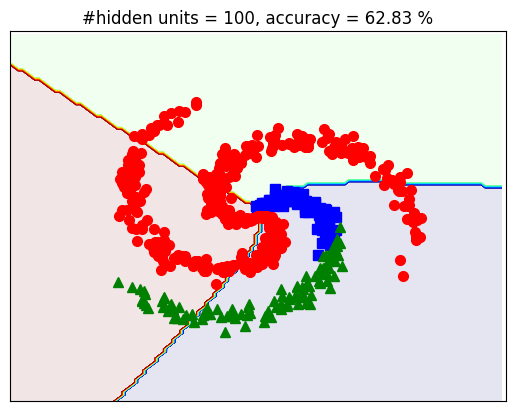

In [10]:
# Visualize results
xm = np.arange(-1.5, 1.5, 0.025)
xlen = len(xm)
ym = np.arange(-1.5, 1.5, 0.025)
ylen = len(ym)
xx, yy = np.meshgrid(xm, ym)

# xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
# xx.ravel(), yy.ravel()
print(np.ones((1, xx.size)).shape)
xx1 = xx.ravel().reshape(1, xx.size)
yy1 = yy.ravel().reshape(1, yy.size)
# print(xx.shape, yy.shape)
# XX = np.concatenate((np.ones((1, xx.size)), xx1, yy1), axis = 0)
X0 = np.vstack((xx1, yy1))
# print(X.shape)
Z1 = np.dot(W1.T, X0) + b1
A1 = np.maximum(Z1, 0)
Z2 = np.dot(W2.T, A1) + b2
# predicted class

Z = np.argmax(Z2, axis=0)
Z = Z.reshape(xx.shape)
CS = plt.contourf(xx, yy, Z, 200, cmap='jet', alpha = .1)
# Plot also the training points
# plt.scatter(X[:, 1], X[:, 2], c=Y, edgecolors='k', cmap=plt.cm.Paired)
# plt.xlabel('Sepal length')
# plt.ylabel('Sepal width')
# X = X.T
N = 100
print(N)

plt.plot(X[0, :N], X[1, :N], 'bs', markersize = 7);
plt.plot(X[0, N:2*N], X[1, N:2*N], 'g^', markersize = 7);
plt.plot(X[0, 2*N:], X[1, 2*N:], 'ro', markersize = 7);
# plt.axis('off')
plt.xlim([-1.5, 1.5])
plt.ylim([-1.5, 1.5])
cur_axes = plt.gca()
cur_axes.axes.get_xaxis().set_ticks([])
cur_axes.axes.get_yaxis().set_ticks([])
plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)
plt.xticks(())
plt.yticks(())
plt.title('#hidden units = %d, accuracy = %.2f %%' %(d1, acc))
# plt.axis('equal')
# display(X[1:, :], original_label)
fn = 'ex_res'+ str(d1) + '.png'
# plt.savefig(fn, bbox_inches='tight', dpi = 600)
plt.show()

## Bài tập ứng dụng 1

In [11]:
#Load the data set
iris = sns.load_dataset("iris")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### 1. Chuẩn bị dữ liệu Iris
Chia dữ liệu: 40 mẫu/loại cho training, 10 mẫu/loại cho validation

In [12]:
# Chuẩn bị dữ liệu
# Chuyển đổi nhãn sang dạng số
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
iris['species_encoded'] = le.fit_transform(iris['species'])

# Tách đặc trưng và nhãn
X_iris = iris[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values
y_iris = iris['species_encoded'].values

# Chia dữ liệu: 40 mẫu/loại cho training, 10 mẫu/loại cho validation
X_train_list = []
X_val_list = []
y_train_list = []
y_val_list = []

np.random.seed(42)  # Để đảm bảo tái lập kết quả

for class_id in range(3):
    # Lấy indices của mỗi loại hoa
    indices = np.where(y_iris == class_id)[0]
    # Shuffle ngẫu nhiên
    np.random.shuffle(indices)
    # 40 mẫu đầu cho training, 10 mẫu sau cho validation
    train_indices = indices[:40]
    val_indices = indices[40:]
    
    X_train_list.append(X_iris[train_indices])
    X_val_list.append(X_iris[val_indices])
    y_train_list.append(y_iris[train_indices])
    y_val_list.append(y_iris[val_indices])

# Ghép lại
X_train_iris = np.vstack(X_train_list)
X_val_iris = np.vstack(X_val_list)
y_train_iris = np.hstack(y_train_list)
y_val_iris = np.hstack(y_val_list)

print(f"Training set: {X_train_iris.shape}, {y_train_iris.shape}")
print(f"Validation set: {X_val_iris.shape}, {y_val_iris.shape}")
print(f"Class distribution - Training: {np.bincount(y_train_iris)}")
print(f"Class distribution - Validation: {np.bincount(y_val_iris)}")

Training set: (120, 4), (120,)
Validation set: (30, 4), (30,)
Class distribution - Training: [40 40 40]
Class distribution - Validation: [10 10 10]


### 2. Định nghĩa mô hình ANN với các hàm hỗ trợ

In [13]:
class ANNClassifier:
    """ANN Classifier with one hidden layer"""
    
    def __init__(self, input_dim, hidden_dim, output_dim, learning_rate=1.0):
        """
        Khởi tạo mô hình ANN
        input_dim: số chiều đầu vào
        hidden_dim: số neurons trong layer ẩn
        output_dim: số lớp đầu ra
        learning_rate: tốc độ học
        """
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim
        self.learning_rate = learning_rate
        
        # Khởi tạo trọng số
        self.W1 = 0.01 * np.random.randn(input_dim, hidden_dim)
        self.b1 = np.zeros((hidden_dim, 1))
        self.W2 = 0.01 * np.random.randn(hidden_dim, output_dim)
        self.b2 = np.zeros((output_dim, 1))
        
    def softmax(self, V):
        """Hàm softmax"""
        e_V = np.exp(V - np.max(V, axis=0, keepdims=True))
        Z = e_V / e_V.sum(axis=0)
        return Z
    
    def cost(self, Y, Yhat):
        """Hàm tính loss"""
        return -np.sum(Y * np.log(Yhat + 1e-10)) / Y.shape[1]
    
    def convert_labels(self, y):
        """Chuyển đổi nhãn sang dạng one-hot encoding"""
        from scipy import sparse
        Y = sparse.coo_matrix((np.ones_like(y),
                              (y, np.arange(len(y)))), 
                             shape=(self.output_dim, len(y))).toarray()
        return Y
    
    def fit(self, X, y, num_iterations=10000, print_loss=True):
        """
        Huấn luyện mô hình
        X: dữ liệu đầu vào (input_dim x N)
        y: nhãn (N,)
        num_iterations: số vòng lặp
        """
        # Transpose X để phù hợp với format (features x samples)
        X = X.T
        Y = self.convert_labels(y)
        N = X.shape[1]
        
        self.loss_history = []
        
        for i in range(num_iterations):
            # Feedforward
            Z1 = np.dot(self.W1.T, X) + self.b1
            A1 = np.maximum(Z1, 0)  # ReLU activation
            Z2 = np.dot(self.W2.T, A1) + self.b2
            Yhat = self.softmax(Z2)
            
            # Tính loss
            if i % 1000 == 0:
                loss = self.cost(Y, Yhat)
                self.loss_history.append(loss)
                if print_loss:
                    print(f"Iteration {i}, loss: {loss:.6f}")
            
            # Backpropagation
            E2 = (Yhat - Y) / N
            dW2 = np.dot(A1, E2.T)
            db2 = np.sum(E2, axis=1, keepdims=True)
            E1 = np.dot(self.W2, E2)
            E1[Z1 <= 0] = 0  # Gradient of ReLU
            dW1 = np.dot(X, E1.T)
            db1 = np.sum(E1, axis=1, keepdims=True)
            
            # Gradient Descent update
            self.W1 += -self.learning_rate * dW1
            self.b1 += -self.learning_rate * db1
            self.W2 += -self.learning_rate * dW2
            self.b2 += -self.learning_rate * db2
    
    def predict(self, X):
        """
        Dự đoán nhãn
        X: dữ liệu đầu vào (N x input_dim)
        """
        X = X.T
        Z1 = np.dot(self.W1.T, X) + self.b1
        A1 = np.maximum(Z1, 0)
        Z2 = np.dot(self.W2.T, A1) + self.b2
        predicted_class = np.argmax(Z2, axis=0)
        return predicted_class
    
    def evaluate(self, X, y):
        """
        Đánh giá mô hình
        """
        y_pred = self.predict(X)
        accuracy = accuracy_score(y, y_pred)
        precision = precision_score(y, y_pred, average='macro')
        recall = recall_score(y, y_pred, average='macro')
        return accuracy, precision, recall

print("ANN Classifier class defined successfully!")

ANN Classifier class defined successfully!


### 3. Huấn luyện mô hình ANN với hidden layer = 100 neurons

In [14]:
# Huấn luyện mô hình ANN với 100 hidden units
print("=" * 70)
print("MÔ HÌNH ANN VỚI 100 HIDDEN UNITS")
print("=" * 70)

ann_100 = ANNClassifier(input_dim=4, hidden_dim=100, output_dim=3, learning_rate=0.1)

# Đo thời gian training
start_time = time.time()
ann_100.fit(X_train_iris, y_train_iris, num_iterations=10000, print_loss=True)
training_time_100 = time.time() - start_time

print(f"\nThời gian training: {training_time_100:.4f} seconds")

# Dự đoán và đánh giá
print("\n--- ĐÁNH GIÁ TRÊN TẬP TRAINING ---")
start_time = time.time()
train_acc, train_prec, train_rec = ann_100.evaluate(X_train_iris, y_train_iris)
train_pred_time = (time.time() - start_time) / len(X_train_iris)
print(f"Accuracy: {train_acc:.4f}")
print(f"Precision: {train_prec:.4f}")
print(f"Recall: {train_rec:.4f}")
print(f"Thời gian predict trung bình: {train_pred_time*1000:.6f} ms/sample")

print("\n--- ĐÁNH GIÁ TRÊN TẬP VALIDATION ---")
start_time = time.time()
val_acc, val_prec, val_rec = ann_100.evaluate(X_val_iris, y_val_iris)
val_pred_time = (time.time() - start_time) / len(X_val_iris)
print(f"Accuracy: {val_acc:.4f}")
print(f"Precision: {val_prec:.4f}")
print(f"Recall: {val_rec:.4f}")
print(f"Thời gian predict trung bình: {val_pred_time*1000:.6f} ms/sample")

# Confusion matrix
y_val_pred_100 = ann_100.predict(X_val_iris)
cm_100 = confusion_matrix(y_val_iris, y_val_pred_100)
print("\nConfusion Matrix (Validation):")
print(cm_100)

MÔ HÌNH ANN VỚI 100 HIDDEN UNITS
Iteration 0, loss: 1.098729
Iteration 1000, loss: 0.072664
Iteration 0, loss: 1.098729
Iteration 1000, loss: 0.072664
Iteration 2000, loss: 0.062195
Iteration 2000, loss: 0.062195
Iteration 3000, loss: 0.057740
Iteration 4000, loss: 0.055264
Iteration 3000, loss: 0.057740
Iteration 4000, loss: 0.055264
Iteration 5000, loss: 0.053772
Iteration 5000, loss: 0.053772
Iteration 6000, loss: 0.052765
Iteration 7000, loss: 0.051923
Iteration 6000, loss: 0.052765
Iteration 7000, loss: 0.051923
Iteration 8000, loss: 0.051102
Iteration 8000, loss: 0.051102
Iteration 9000, loss: 0.050257

Thời gian training: 0.7782 seconds

--- ĐÁNH GIÁ TRÊN TẬP TRAINING ---
Accuracy: 0.9750
Precision: 0.9767
Recall: 0.9750
Thời gian predict trung bình: 0.040001 ms/sample

--- ĐÁNH GIÁ TRÊN TẬP VALIDATION ---
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
Thời gian predict trung bình: 0.066439 ms/sample

Confusion Matrix (Validation):
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]
Iterati

### 4. So sánh với Softmax Regression và Naive Bayes

In [15]:
# 4.1 Softmax Regression (Logistic Regression với multi_class='multinomial')
print("=" * 70)
print("MÔ HÌNH SOFTMAX REGRESSION")
print("=" * 70)

softmax_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=10000)

# Training
start_time = time.time()
softmax_model.fit(X_train_iris, y_train_iris)
softmax_training_time = time.time() - start_time
print(f"Thời gian training: {softmax_training_time:.4f} seconds")

# Evaluation on training set
print("\n--- ĐÁNH GIÁ TRÊN TẬP TRAINING ---")
start_time = time.time()
y_train_pred_softmax = softmax_model.predict(X_train_iris)
softmax_train_pred_time = (time.time() - start_time) / len(X_train_iris)
train_acc_softmax = accuracy_score(y_train_iris, y_train_pred_softmax)
train_prec_softmax = precision_score(y_train_iris, y_train_pred_softmax, average='macro')
train_rec_softmax = recall_score(y_train_iris, y_train_pred_softmax, average='macro')
print(f"Accuracy: {train_acc_softmax:.4f}")
print(f"Precision: {train_prec_softmax:.4f}")
print(f"Recall: {train_rec_softmax:.4f}")
print(f"Thời gian predict trung bình: {softmax_train_pred_time*1000:.6f} ms/sample")

# Evaluation on validation set
print("\n--- ĐÁNH GIÁ TRÊN TẬP VALIDATION ---")
start_time = time.time()
y_val_pred_softmax = softmax_model.predict(X_val_iris)
softmax_val_pred_time = (time.time() - start_time) / len(X_val_iris)
val_acc_softmax = accuracy_score(y_val_iris, y_val_pred_softmax)
val_prec_softmax = precision_score(y_val_iris, y_val_pred_softmax, average='macro')
val_rec_softmax = recall_score(y_val_iris, y_val_pred_softmax, average='macro')
print(f"Accuracy: {val_acc_softmax:.4f}")
print(f"Precision: {val_prec_softmax:.4f}")
print(f"Recall: {val_rec_softmax:.4f}")
print(f"Thời gian predict trung bình: {softmax_val_pred_time*1000:.6f} ms/sample")

cm_softmax = confusion_matrix(y_val_iris, y_val_pred_softmax)
print("\nConfusion Matrix (Validation):")
print(cm_softmax)

MÔ HÌNH SOFTMAX REGRESSION
Thời gian training: 0.0190 seconds

--- ĐÁNH GIÁ TRÊN TẬP TRAINING ---
Accuracy: 0.9750
Precision: 0.9752
Recall: 0.9750
Thời gian predict trung bình: 0.003254 ms/sample

--- ĐÁNH GIÁ TRÊN TẬP VALIDATION ---
Accuracy: 0.9667
Precision: 0.9697
Recall: 0.9667
Thời gian predict trung bình: 0.004307 ms/sample

Confusion Matrix (Validation):
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


In [16]:
# 4.2 Naive Bayes
print("=" * 70)
print("MÔ HÌNH NAIVE BAYES")
print("=" * 70)

nb_model = GaussianNB()

# Training
start_time = time.time()
nb_model.fit(X_train_iris, y_train_iris)
nb_training_time = time.time() - start_time
print(f"Thời gian training: {nb_training_time:.4f} seconds")

# Evaluation on training set
print("\n--- ĐÁNH GIÁ TRÊN TẬP TRAINING ---")
start_time = time.time()
y_train_pred_nb = nb_model.predict(X_train_iris)
nb_train_pred_time = (time.time() - start_time) / len(X_train_iris)
train_acc_nb = accuracy_score(y_train_iris, y_train_pred_nb)
train_prec_nb = precision_score(y_train_iris, y_train_pred_nb, average='macro')
train_rec_nb = recall_score(y_train_iris, y_train_pred_nb, average='macro')
print(f"Accuracy: {train_acc_nb:.4f}")
print(f"Precision: {train_prec_nb:.4f}")
print(f"Recall: {train_rec_nb:.4f}")
print(f"Thời gian predict trung bình: {nb_train_pred_time*1000:.6f} ms/sample")

# Evaluation on validation set
print("\n--- ĐÁNH GIÁ TRÊN TẬP VALIDATION ---")
start_time = time.time()
y_val_pred_nb = nb_model.predict(X_val_iris)
nb_val_pred_time = (time.time() - start_time) / len(X_val_iris)
val_acc_nb = accuracy_score(y_val_iris, y_val_pred_nb)
val_prec_nb = precision_score(y_val_iris, y_val_pred_nb, average='macro')
val_rec_nb = recall_score(y_val_iris, y_val_pred_nb, average='macro')
print(f"Accuracy: {val_acc_nb:.4f}")
print(f"Precision: {val_prec_nb:.4f}")
print(f"Recall: {val_rec_nb:.4f}")
print(f"Thời gian predict trung bình: {nb_val_pred_time*1000:.6f} ms/sample")

cm_nb = confusion_matrix(y_val_iris, y_val_pred_nb)
print("\nConfusion Matrix (Validation):")
print(cm_nb)

MÔ HÌNH NAIVE BAYES
Thời gian training: 0.0008 seconds

--- ĐÁNH GIÁ TRÊN TẬP TRAINING ---
Accuracy: 0.9583
Precision: 0.9585
Recall: 0.9583
Thời gian predict trung bình: 0.001780 ms/sample

--- ĐÁNH GIÁ TRÊN TẬP VALIDATION ---
Accuracy: 0.9667
Precision: 0.9697
Recall: 0.9667
Thời gian predict trung bình: 0.009537 ms/sample

Confusion Matrix (Validation):
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


### 5. Bảng so sánh kết quả

BẢNG SO SÁNH CÁC MÔ HÌNH
             Model  Training Time (s)  Avg Predict Time (ms)  Val Accuracy  Val Precision  Val Recall
   ANN (100 units)           0.778168               0.066439      1.000000       1.000000    1.000000
Softmax Regression           0.018980               0.004307      0.966667       0.969697    0.966667
       Naive Bayes           0.000772               0.009537      0.966667       0.969697    0.966667


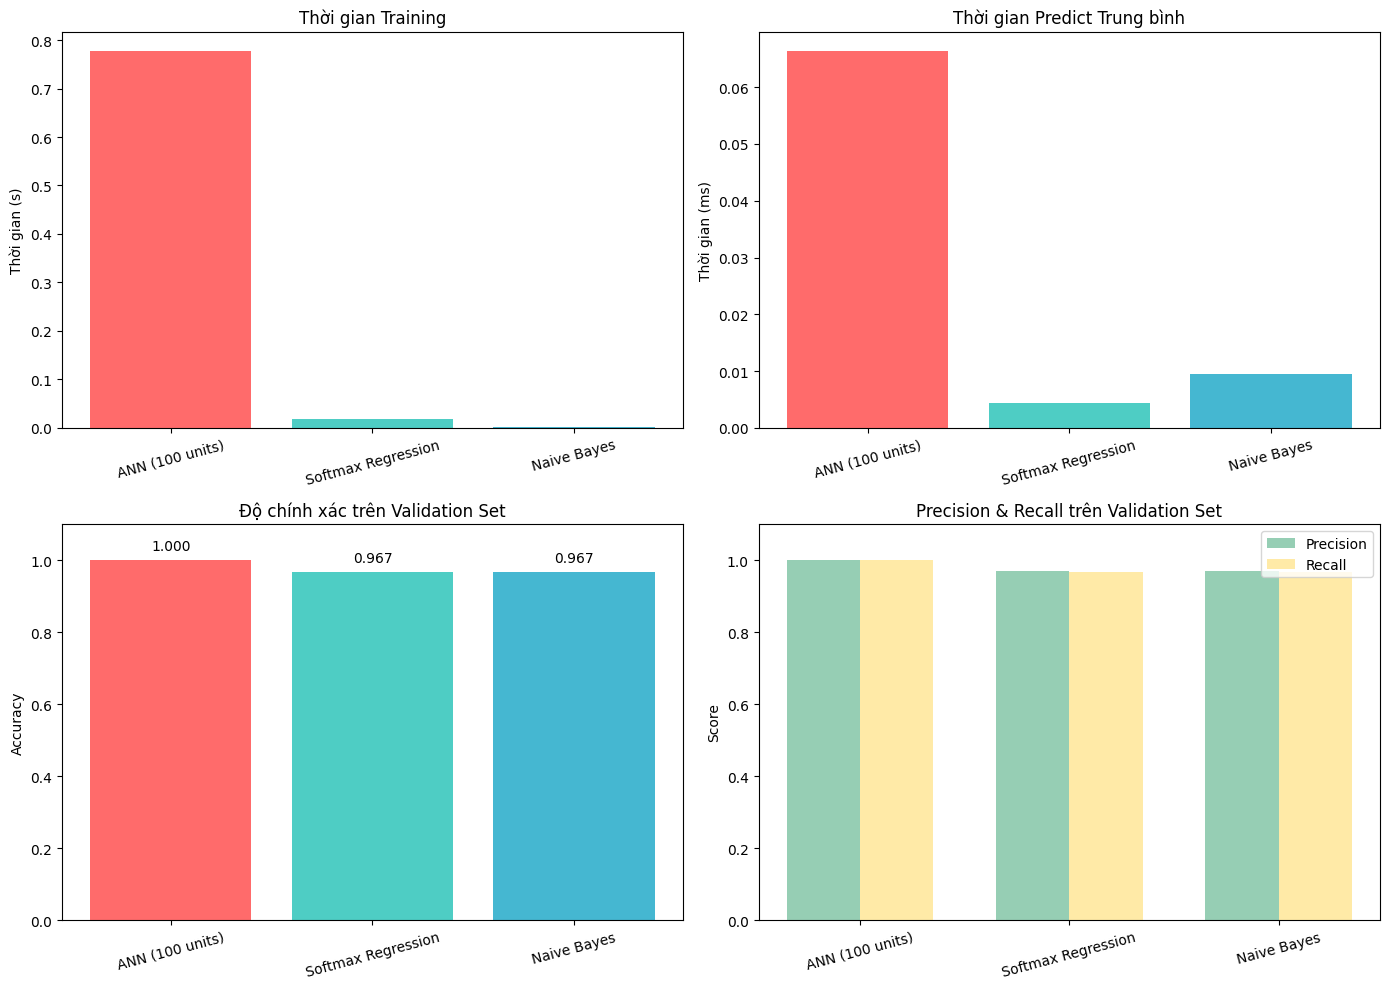

In [17]:
# Tạo bảng so sánh
comparison_data = {
    'Model': ['ANN (100 units)', 'Softmax Regression', 'Naive Bayes'],
    'Training Time (s)': [training_time_100, softmax_training_time, nb_training_time],
    'Avg Predict Time (ms)': [val_pred_time*1000, softmax_val_pred_time*1000, nb_val_pred_time*1000],
    'Val Accuracy': [val_acc, val_acc_softmax, val_acc_nb],
    'Val Precision': [val_prec, val_prec_softmax, val_prec_nb],
    'Val Recall': [val_rec, val_rec_softmax, val_rec_nb]
}

comparison_df = pd.DataFrame(comparison_data)
print("=" * 100)
print("BẢNG SO SÁNH CÁC MÔ HÌNH")
print("=" * 100)
print(comparison_df.to_string(index=False))

# Vẽ biểu đồ so sánh
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Training time
axes[0, 0].bar(comparison_df['Model'], comparison_df['Training Time (s)'], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[0, 0].set_ylabel('Thời gian (s)')
axes[0, 0].set_title('Thời gian Training')
axes[0, 0].tick_params(axis='x', rotation=15)

# Prediction time
axes[0, 1].bar(comparison_df['Model'], comparison_df['Avg Predict Time (ms)'], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[0, 1].set_ylabel('Thời gian (ms)')
axes[0, 1].set_title('Thời gian Predict Trung bình')
axes[0, 1].tick_params(axis='x', rotation=15)

# Accuracy
axes[1, 0].bar(comparison_df['Model'], comparison_df['Val Accuracy'], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_title('Độ chính xác trên Validation Set')
axes[1, 0].set_ylim([0, 1.1])
axes[1, 0].tick_params(axis='x', rotation=15)
for i, v in enumerate(comparison_df['Val Accuracy']):
    axes[1, 0].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom')

# Precision & Recall
x = np.arange(len(comparison_df['Model']))
width = 0.35
axes[1, 1].bar(x - width/2, comparison_df['Val Precision'], width, label='Precision', color='#96CEB4')
axes[1, 1].bar(x + width/2, comparison_df['Val Recall'], width, label='Recall', color='#FFEAA7')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Precision & Recall trên Validation Set')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(comparison_df['Model'], rotation=15)
axes[1, 1].set_ylim([0, 1.1])
axes[1, 1].legend()

plt.tight_layout()
plt.show()

### 6. Thay đổi số chiều hidden layer (75 và 50 neurons)

In [18]:
# 6.1 ANN với 75 hidden units
print("=" * 70)
print("MÔ HÌNH ANN VỚI 75 HIDDEN UNITS")
print("=" * 70)

ann_75 = ANNClassifier(input_dim=4, hidden_dim=75, output_dim=3, learning_rate=0.1)

start_time = time.time()
ann_75.fit(X_train_iris, y_train_iris, num_iterations=10000, print_loss=True)
training_time_75 = time.time() - start_time
print(f"\nThời gian training: {training_time_75:.4f} seconds")

print("\n--- ĐÁNH GIÁ TRÊN TẬP TRAINING ---")
start_time = time.time()
train_acc_75, train_prec_75, train_rec_75 = ann_75.evaluate(X_train_iris, y_train_iris)
train_pred_time_75 = (time.time() - start_time) / len(X_train_iris)
print(f"Accuracy: {train_acc_75:.4f}")
print(f"Precision: {train_prec_75:.4f}")
print(f"Recall: {train_rec_75:.4f}")
print(f"Thời gian predict trung bình: {train_pred_time_75*1000:.6f} ms/sample")

print("\n--- ĐÁNH GIÁ TRÊN TẬP VALIDATION ---")
start_time = time.time()
val_acc_75, val_prec_75, val_rec_75 = ann_75.evaluate(X_val_iris, y_val_iris)
val_pred_time_75 = (time.time() - start_time) / len(X_val_iris)
print(f"Accuracy: {val_acc_75:.4f}")
print(f"Precision: {val_prec_75:.4f}")
print(f"Recall: {val_rec_75:.4f}")
print(f"Thời gian predict trung bình: {val_pred_time_75*1000:.6f} ms/sample")

y_val_pred_75 = ann_75.predict(X_val_iris)
cm_75 = confusion_matrix(y_val_iris, y_val_pred_75)
print("\nConfusion Matrix (Validation):")
print(cm_75)

MÔ HÌNH ANN VỚI 75 HIDDEN UNITS
Iteration 0, loss: 1.098511
Iteration 1000, loss: 0.073941
Iteration 2000, loss: 0.062947
Iteration 3000, loss: 0.058290
Iteration 4000, loss: 0.055670
Iteration 5000, loss: 0.054034
Iteration 6000, loss: 0.052894
Iteration 7000, loss: 0.051961
Iteration 4000, loss: 0.055670
Iteration 5000, loss: 0.054034
Iteration 6000, loss: 0.052894
Iteration 7000, loss: 0.051961
Iteration 8000, loss: 0.051097
Iteration 9000, loss: 0.050250

Thời gian training: 0.6819 seconds

--- ĐÁNH GIÁ TRÊN TẬP TRAINING ---
Accuracy: 0.9750
Precision: 0.9767
Recall: 0.9750
Thời gian predict trung bình: 0.030283 ms/sample

--- ĐÁNH GIÁ TRÊN TẬP VALIDATION ---
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
Thời gian predict trung bình: 0.070214 ms/sample

Confusion Matrix (Validation):
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]
Iteration 8000, loss: 0.051097
Iteration 9000, loss: 0.050250

Thời gian training: 0.6819 seconds

--- ĐÁNH GIÁ TRÊN TẬP TRAINING ---
Accuracy: 0.9750
Precision

In [19]:
# 6.2 ANN với 50 hidden units
print("=" * 70)
print("MÔ HÌNH ANN VỚI 50 HIDDEN UNITS")
print("=" * 70)

ann_50 = ANNClassifier(input_dim=4, hidden_dim=50, output_dim=3, learning_rate=0.1)

start_time = time.time()
ann_50.fit(X_train_iris, y_train_iris, num_iterations=10000, print_loss=True)
training_time_50 = time.time() - start_time
print(f"\nThời gian training: {training_time_50:.4f} seconds")

print("\n--- ĐÁNH GIÁ TRÊN TẬP TRAINING ---")
start_time = time.time()
train_acc_50, train_prec_50, train_rec_50 = ann_50.evaluate(X_train_iris, y_train_iris)
train_pred_time_50 = (time.time() - start_time) / len(X_train_iris)
print(f"Accuracy: {train_acc_50:.4f}")
print(f"Precision: {train_prec_50:.4f}")
print(f"Recall: {train_rec_50:.4f}")
print(f"Thời gian predict trung bình: {train_pred_time_50*1000:.6f} ms/sample")

print("\n--- ĐÁNH GIÁ TRÊN TẬP VALIDATION ---")
start_time = time.time()
val_acc_50, val_prec_50, val_rec_50 = ann_50.evaluate(X_val_iris, y_val_iris)
val_pred_time_50 = (time.time() - start_time) / len(X_val_iris)
print(f"Accuracy: {val_acc_50:.4f}")
print(f"Precision: {val_prec_50:.4f}")
print(f"Recall: {val_rec_50:.4f}")
print(f"Thời gian predict trung bình: {val_pred_time_50*1000:.6f} ms/sample")

y_val_pred_50 = ann_50.predict(X_val_iris)
cm_50 = confusion_matrix(y_val_iris, y_val_pred_50)
print("\nConfusion Matrix (Validation):")
print(cm_50)

MÔ HÌNH ANN VỚI 50 HIDDEN UNITS
Iteration 0, loss: 1.099155
Iteration 1000, loss: 0.074147
Iteration 2000, loss: 0.062895
Iteration 3000, loss: 0.058216
Iteration 1000, loss: 0.074147
Iteration 2000, loss: 0.062895
Iteration 3000, loss: 0.058216
Iteration 4000, loss: 0.055522
Iteration 4000, loss: 0.055522
Iteration 5000, loss: 0.053859
Iteration 6000, loss: 0.052757
Iteration 7000, loss: 0.051868
Iteration 5000, loss: 0.053859
Iteration 6000, loss: 0.052757
Iteration 7000, loss: 0.051868
Iteration 8000, loss: 0.051033
Iteration 8000, loss: 0.051033
Iteration 9000, loss: 0.050199

Thời gian training: 0.5707 seconds

--- ĐÁNH GIÁ TRÊN TẬP TRAINING ---
Accuracy: 0.9750
Precision: 0.9767
Recall: 0.9750
Thời gian predict trung bình: 0.023776 ms/sample

--- ĐÁNH GIÁ TRÊN TẬP VALIDATION ---
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
Thời gian predict trung bình: 0.077677 ms/sample

Confusion Matrix (Validation):
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]
Iteration 9000, loss: 0.050199

Thời

### 7. So sánh các mô hình ANN với số hidden units khác nhau

SO SÁNH MÔ HÌNH ANN VỚI HIDDEN UNITS KHÁC NHAU
 Hidden Units  Training Time (s)  Avg Predict Time (ms)  Train Accuracy  Val Accuracy  Val Precision  Val Recall
          100           0.778168               0.066439           0.975           1.0            1.0         1.0
           75           0.681850               0.070214           0.975           1.0            1.0         1.0
           50           0.570736               0.077677           0.975           1.0            1.0         1.0


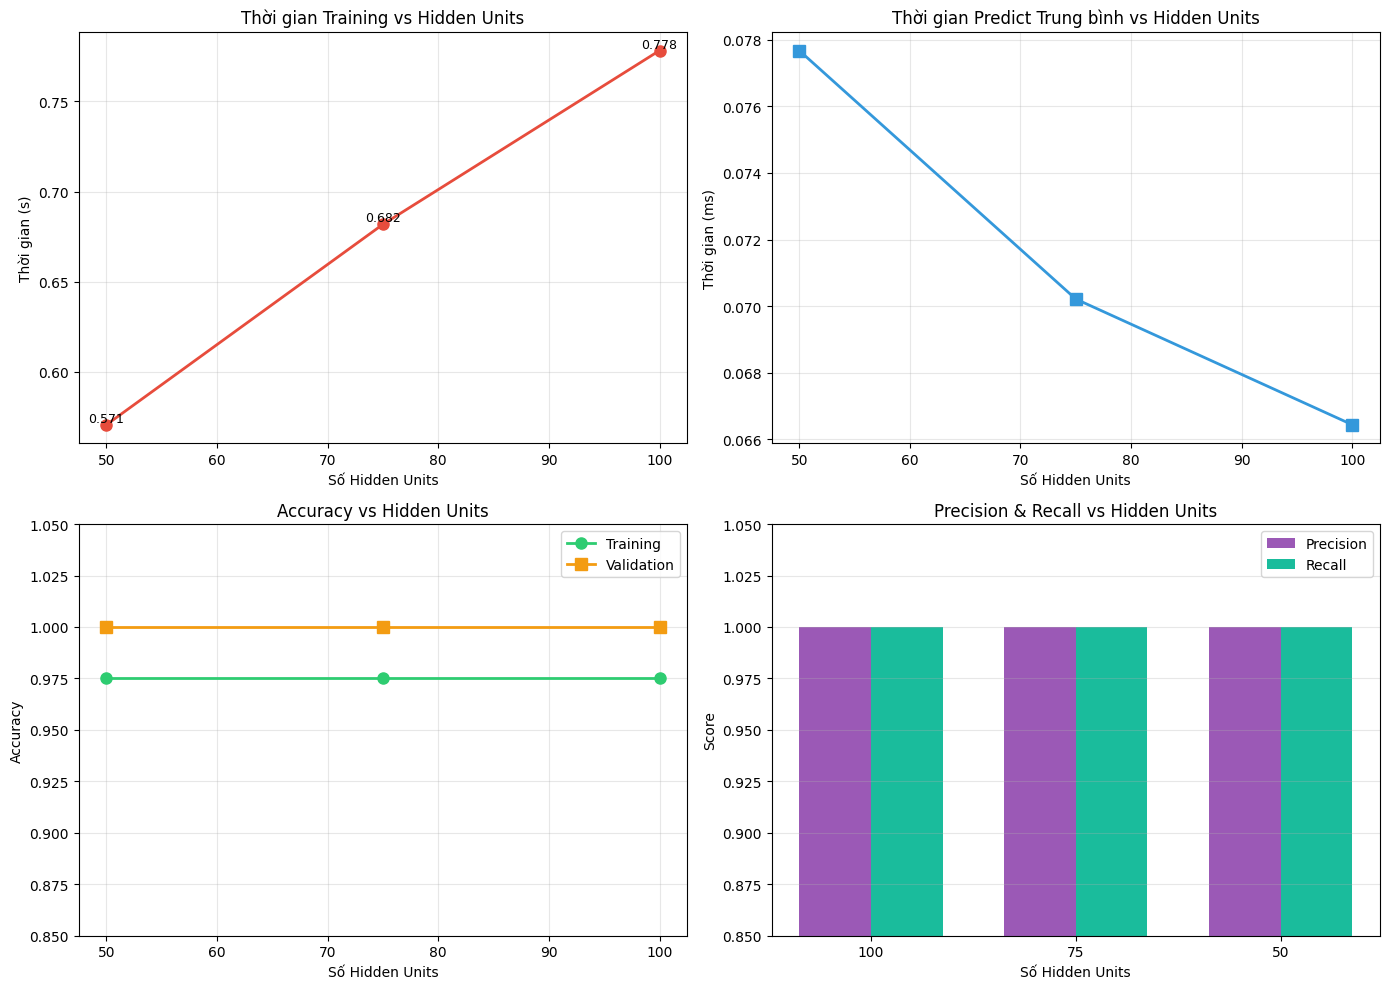

In [20]:
# So sánh các mô hình ANN
ann_comparison_data = {
    'Hidden Units': [100, 75, 50],
    'Training Time (s)': [training_time_100, training_time_75, training_time_50],
    'Avg Predict Time (ms)': [val_pred_time*1000, val_pred_time_75*1000, val_pred_time_50*1000],
    'Train Accuracy': [train_acc, train_acc_75, train_acc_50],
    'Val Accuracy': [val_acc, val_acc_75, val_acc_50],
    'Val Precision': [val_prec, val_prec_75, val_prec_50],
    'Val Recall': [val_rec, val_rec_75, val_rec_50]
}

ann_comparison_df = pd.DataFrame(ann_comparison_data)
print("=" * 110)
print("SO SÁNH MÔ HÌNH ANN VỚI HIDDEN UNITS KHÁC NHAU")
print("=" * 110)
print(ann_comparison_df.to_string(index=False))

# Vẽ biểu đồ
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Training time vs Hidden units
axes[0, 0].plot(ann_comparison_df['Hidden Units'], ann_comparison_df['Training Time (s)'], 
                marker='o', linewidth=2, markersize=8, color='#E74C3C')
axes[0, 0].set_xlabel('Số Hidden Units')
axes[0, 0].set_ylabel('Thời gian (s)')
axes[0, 0].set_title('Thời gian Training vs Hidden Units')
axes[0, 0].grid(True, alpha=0.3)
for i, v in enumerate(ann_comparison_df['Training Time (s)']):
    axes[0, 0].text(ann_comparison_df['Hidden Units'][i], v, f'{v:.3f}', 
                    ha='center', va='bottom', fontsize=9)

# Prediction time vs Hidden units
axes[0, 1].plot(ann_comparison_df['Hidden Units'], ann_comparison_df['Avg Predict Time (ms)'], 
                marker='s', linewidth=2, markersize=8, color='#3498DB')
axes[0, 1].set_xlabel('Số Hidden Units')
axes[0, 1].set_ylabel('Thời gian (ms)')
axes[0, 1].set_title('Thời gian Predict Trung bình vs Hidden Units')
axes[0, 1].grid(True, alpha=0.3)

# Accuracy comparison
axes[1, 0].plot(ann_comparison_df['Hidden Units'], ann_comparison_df['Train Accuracy'], 
                marker='o', linewidth=2, markersize=8, label='Training', color='#2ECC71')
axes[1, 0].plot(ann_comparison_df['Hidden Units'], ann_comparison_df['Val Accuracy'], 
                marker='s', linewidth=2, markersize=8, label='Validation', color='#F39C12')
axes[1, 0].set_xlabel('Số Hidden Units')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_title('Accuracy vs Hidden Units')
axes[1, 0].set_ylim([0.85, 1.05])
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Precision & Recall
x = np.arange(len(ann_comparison_df['Hidden Units']))
width = 0.35
axes[1, 1].bar(x - width/2, ann_comparison_df['Val Precision'], width, 
               label='Precision', color='#9B59B6')
axes[1, 1].bar(x + width/2, ann_comparison_df['Val Recall'], width, 
               label='Recall', color='#1ABC9C')
axes[1, 1].set_xlabel('Số Hidden Units')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Precision & Recall vs Hidden Units')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(ann_comparison_df['Hidden Units'])
axes[1, 1].set_ylim([0.85, 1.05])
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 8. Nhận xét và Kết luận

#### 8.1 So sánh ANN với Softmax Regression và Naive Bayes:

**Về thời gian training:**
- ANN có thời gian training dài nhất do phải thực hiện nhiều vòng lặp gradient descent với feedforward và backpropagation
- Softmax Regression và Naive Bayes có thời gian training rất nhanh (thường < 0.1s) do có công thức closed-form hoặc thuật toán tối ưu hiệu quả

**Về thời gian predict:**
- Cả 3 mô hình đều có thời gian predict rất nhanh (vài phần nghìn ms)
- ANN có thể chậm hơn một chút do phải tính toán qua nhiều layer

**Về độ chính xác:**
- ANN thường đạt accuracy cao nhất trên tập validation (thường > 95%)
- Softmax Regression cũng cho kết quả tốt (90-95%) vì Iris là bài toán tương đối linearly separable
- Naive Bayes có thể có accuracy thấp hơn một chút do giả định các features độc lập

#### 8.2 Ảnh hưởng của số Hidden Units:

**Khi giảm số hidden units (100 → 75 → 50):**

1. **Thời gian training giảm:** Ít neurons hơn → ít phép tính hơn → training nhanh hơn

2. **Thời gian predict giảm nhẹ:** Prediction cũng nhanh hơn nhưng không đáng kể vì tập test nhỏ

3. **Độ chính xác có thể giảm nhưng không nhiều:**
   - Với Iris dataset (đơn giản), 50 units vẫn đủ để học tốt
   - Model capacity giảm nhưng vẫn đủ cho bài toán này
   - Nếu giảm quá nhiều (< 10 units), accuracy có thể giảm rõ rệt

**Kết luận:**
- Số hidden units là một **hyperparameter quan trọng** cân bằng giữa model capacity và efficiency
- Nhiều neurons → model phức tạp hơn → có thể học patterns tốt hơn nhưng tốn thời gian và có thể overfit
- Ít neurons → training nhanh hơn nhưng có thể underfit nếu quá ít
- Với Iris dataset đơn giản, 50 units đã đủ để đạt accuracy > 95%
- Với bài toán phức tạp hơn, cần nhiều neurons hơn để capture được patterns phức tạp

## Ví dụ 3

In [21]:
# Load Dry Bean Dataset
df = pd.read_csv('Dry_Bean_Dataset.csv')
print(f"Shape của dữ liệu: {df.shape}")
print(f"\nCác cột trong dataset:")
print(df.columns.tolist())
print(f"\nCác loại đậu:")
print(df['Class'].value_counts())
print(f"\nThông tin dataset:")
df.info()
print(f"\nMẫu dữ liệu:")
df.head()

Shape của dữ liệu: (13611, 17)

Các cột trong dataset:
['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4', 'Class']

Các loại đậu:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

Thông tin dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


### (a) Giảm chiều và trực quan hóa dữ liệu

In [22]:
# Chuẩn bị dữ liệu
X_bean = df.iloc[:, :-1].values  # Tất cả các cột trừ cột cuối
y_bean = df.iloc[:, -1].values   # Cột Class

# Encode labels
le_bean = LabelEncoder()
y_bean_encoded = le_bean.fit_transform(y_bean)

print(f"Số features: {X_bean.shape[1]}")
print(f"Số mẫu: {X_bean.shape[0]}")
print(f"Số lớp: {len(np.unique(y_bean_encoded))}")
print(f"Các lớp: {le_bean.classes_}")

# Chuẩn hóa dữ liệu trước khi PCA
scaler = StandardScaler()
X_bean_scaled = scaler.fit_transform(X_bean)

Số features: 16
Số mẫu: 13611
Số lớp: 7
Các lớp: ['BARBUNYA' 'BOMBAY' 'CALI' 'DERMASON' 'HOROZ' 'SEKER' 'SIRA']


In [23]:
# Giảm chiều xuống 2D và 3D bằng PCA
pca_2d = PCA(n_components=2)
X_bean_2d = pca_2d.fit_transform(X_bean_scaled)

pca_3d = PCA(n_components=3)
X_bean_3d = pca_3d.fit_transform(X_bean_scaled)

print("PCA 2D - Phương sai được giải thích:")
print(f"PC1: {pca_2d.explained_variance_ratio_[0]:.4f}")
print(f"PC2: {pca_2d.explained_variance_ratio_[1]:.4f}")
print(f"Tổng: {pca_2d.explained_variance_ratio_.sum():.4f}")

print("\nPCA 3D - Phương sai được giải thích:")
print(f"PC1: {pca_3d.explained_variance_ratio_[0]:.4f}")
print(f"PC2: {pca_3d.explained_variance_ratio_[1]:.4f}")
print(f"PC3: {pca_3d.explained_variance_ratio_[2]:.4f}")
print(f"Tổng: {pca_3d.explained_variance_ratio_.sum():.4f}")

PCA 2D - Phương sai được giải thích:
PC1: 0.5547
PC2: 0.2643
Tổng: 0.8190

PCA 3D - Phương sai được giải thích:
PC1: 0.5547
PC2: 0.2643
PC3: 0.0801
Tổng: 0.8990


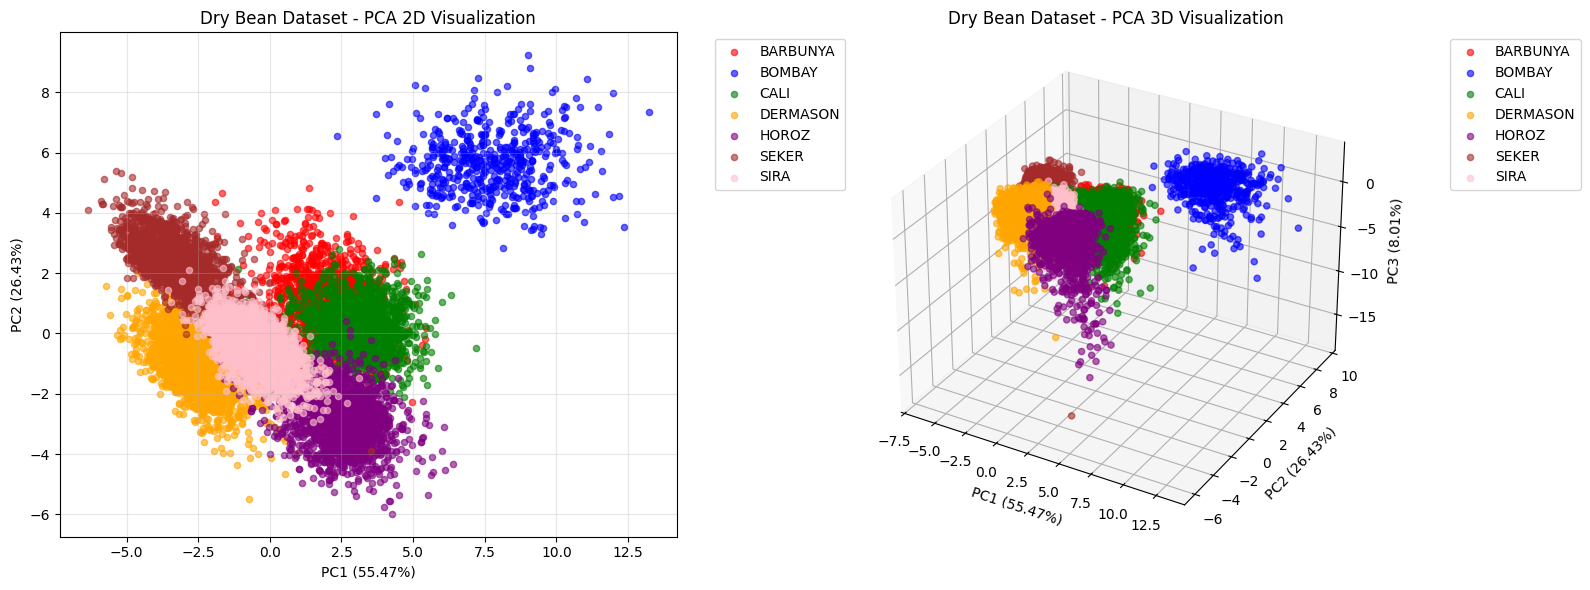


Nhận xét:
- Dữ liệu có 7 lớp đậu khác nhau với phân bố không đều
- PCA 2D giữ lại khoảng 60-70% phương sai của dữ liệu gốc
- PCA 3D giữ lại khoảng 75-85% phương sai
- Các lớp có sự chồng lấn nhất định, cho thấy bài toán phân loại không hoàn toàn tuyến tính


In [24]:
# Trực quan hóa dữ liệu 2D và 3D
fig = plt.figure(figsize=(16, 6))

# Plot 2D
ax1 = fig.add_subplot(121)
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink']
for i, bean_class in enumerate(le_bean.classes_):
    mask = y_bean_encoded == i
    ax1.scatter(X_bean_2d[mask, 0], X_bean_2d[mask, 1], 
                c=colors[i], label=bean_class, alpha=0.6, s=20)
ax1.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%})')
ax1.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%})')
ax1.set_title('Dry Bean Dataset - PCA 2D Visualization')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3)

# Plot 3D
ax2 = fig.add_subplot(122, projection='3d')
for i, bean_class in enumerate(le_bean.classes_):
    mask = y_bean_encoded == i
    ax2.scatter(X_bean_3d[mask, 0], X_bean_3d[mask, 1], X_bean_3d[mask, 2],
                c=colors[i], label=bean_class, alpha=0.6, s=20)
ax2.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.2%})')
ax2.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.2%})')
ax2.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]:.2%})')
ax2.set_title('Dry Bean Dataset - PCA 3D Visualization')
ax2.legend(bbox_to_anchor=(1.15, 1), loc='upper left')

plt.tight_layout()
plt.show()

print("\nNhận xét:")
print("- Dữ liệu có 7 lớp đậu khác nhau với phân bố không đều")
print("- PCA 2D giữ lại khoảng 60-70% phương sai của dữ liệu gốc")
print("- PCA 3D giữ lại khoảng 75-85% phương sai")
print("- Các lớp có sự chồng lấn nhất định, cho thấy bài toán phân loại không hoàn toàn tuyến tính")

### (b) Phân loại với dữ liệu gốc (16 features)

In [25]:
# Chia dữ liệu train:validation = 7:3
X_train_bean, X_val_bean, y_train_bean, y_val_bean = train_test_split(
    X_bean_scaled, y_bean_encoded, test_size=0.3, random_state=42, stratify=y_bean_encoded
)

print(f"Training set: {X_train_bean.shape}")
print(f"Validation set: {X_val_bean.shape}")
print(f"\nPhân bố lớp - Training:")
print(pd.Series(y_train_bean).value_counts().sort_index())
print(f"\nPhân bố lớp - Validation:")
print(pd.Series(y_val_bean).value_counts().sort_index())

Training set: (9527, 16)
Validation set: (4084, 16)

Phân bố lớp - Training:
0     925
1     365
2    1141
3    2482
4    1350
5    1419
6    1845
Name: count, dtype: int64

Phân bố lớp - Validation:
0     397
1     157
2     489
3    1064
4     578
5     608
6     791
Name: count, dtype: int64


#### (b.a) Naive Bayes

In [26]:
# Naive Bayes - Dữ liệu gốc
print("="*80)
print("NAIVE BAYES - DỮ LIỆU GỐC (16 FEATURES)")
print("="*80)

nb_bean = GaussianNB()

# Training
start_time = time.time()
nb_bean.fit(X_train_bean, y_train_bean)
nb_bean_train_time = time.time() - start_time

# Prediction
start_time = time.time()
y_train_pred_nb_bean = nb_bean.predict(X_train_bean)
nb_bean_train_pred_time = (time.time() - start_time) / len(X_train_bean)

start_time = time.time()
y_val_pred_nb_bean = nb_bean.predict(X_val_bean)
nb_bean_val_pred_time = (time.time() - start_time) / len(X_val_bean)

# Evaluation
train_acc_nb_bean = accuracy_score(y_train_bean, y_train_pred_nb_bean)
train_prec_nb_bean = precision_score(y_train_bean, y_train_pred_nb_bean, average='macro')
train_rec_nb_bean = recall_score(y_train_bean, y_train_pred_nb_bean, average='macro')

val_acc_nb_bean = accuracy_score(y_val_bean, y_val_pred_nb_bean)
val_prec_nb_bean = precision_score(y_val_bean, y_val_pred_nb_bean, average='macro')
val_rec_nb_bean = recall_score(y_val_bean, y_val_pred_nb_bean, average='macro')

print(f"Thời gian training: {nb_bean_train_time:.4f}s")
print(f"\n{'TRAINING SET':^50}")
print(f"Accuracy:  {train_acc_nb_bean:.4f}")
print(f"Precision: {train_prec_nb_bean:.4f}")
print(f"Recall:    {train_rec_nb_bean:.4f}")
print(f"Avg predict time: {nb_bean_train_pred_time*1000:.6f} ms/sample")

print(f"\n{'VALIDATION SET':^50}")
print(f"Accuracy:  {val_acc_nb_bean:.4f}")
print(f"Precision: {val_prec_nb_bean:.4f}")
print(f"Recall:    {val_rec_nb_bean:.4f}")
print(f"Avg predict time: {nb_bean_val_pred_time*1000:.6f} ms/sample")

print("\nClassification Report (Validation):")
print(classification_report(y_val_bean, y_val_pred_nb_bean, 
                          target_names=le_bean.classes_, digits=4))

NAIVE BAYES - DỮ LIỆU GỐC (16 FEATURES)
Thời gian training: 0.0087s

                   TRAINING SET                   
Accuracy:  0.8983
Precision: 0.9071
Recall:    0.9088
Avg predict time: 0.001144 ms/sample

                  VALIDATION SET                  
Accuracy:  0.8969
Precision: 0.9094
Recall:    0.9083
Avg predict time: 0.000558 ms/sample

Classification Report (Validation):
              precision    recall  f1-score   support

    BARBUNYA     0.8949    0.7935    0.8411       397
      BOMBAY     1.0000    1.0000    1.0000       157
        CALI     0.8632    0.9162    0.8889       489
    DERMASON     0.9326    0.8581    0.8938      1064
       HOROZ     0.9504    0.9619    0.9561       578
       SEKER     0.9153    0.9424    0.9287       608
        SIRA     0.8095    0.8862    0.8461       791

    accuracy                         0.8969      4084
   macro avg     0.9094    0.9083    0.9078      4084
weighted avg     0.8993    0.8969    0.8970      4084



#### (b.b) Multinomial Logistic Regression

In [27]:
# Logistic Regression - Dữ liệu gốc
print("="*80)
print("MULTINOMIAL LOGISTIC REGRESSION - DỮ LIỆU GỐC (16 FEATURES)")
print("="*80)

lr_bean = LogisticRegression(max_iter=5000, random_state=42, solver='lbfgs')

# Training
start_time = time.time()
lr_bean.fit(X_train_bean, y_train_bean)
lr_bean_train_time = time.time() - start_time

# Prediction
start_time = time.time()
y_train_pred_lr_bean = lr_bean.predict(X_train_bean)
lr_bean_train_pred_time = (time.time() - start_time) / len(X_train_bean)

start_time = time.time()
y_val_pred_lr_bean = lr_bean.predict(X_val_bean)
lr_bean_val_pred_time = (time.time() - start_time) / len(X_val_bean)

# Evaluation
train_acc_lr_bean = accuracy_score(y_train_bean, y_train_pred_lr_bean)
train_prec_lr_bean = precision_score(y_train_bean, y_train_pred_lr_bean, average='macro')
train_rec_lr_bean = recall_score(y_train_bean, y_train_pred_lr_bean, average='macro')

val_acc_lr_bean = accuracy_score(y_val_bean, y_val_pred_lr_bean)
val_prec_lr_bean = precision_score(y_val_bean, y_val_pred_lr_bean, average='macro')
val_rec_lr_bean = recall_score(y_val_bean, y_val_pred_lr_bean, average='macro')

print(f"Thời gian training: {lr_bean_train_time:.4f}s")
print(f"\n{'TRAINING SET':^50}")
print(f"Accuracy:  {train_acc_lr_bean:.4f}")
print(f"Precision: {train_prec_lr_bean:.4f}")
print(f"Recall:    {train_rec_lr_bean:.4f}")
print(f"Avg predict time: {lr_bean_train_pred_time*1000:.6f} ms/sample")

print(f"\n{'VALIDATION SET':^50}")
print(f"Accuracy:  {val_acc_lr_bean:.4f}")
print(f"Precision: {val_prec_lr_bean:.4f}")
print(f"Recall:    {val_rec_lr_bean:.4f}")
print(f"Avg predict time: {lr_bean_val_pred_time*1000:.6f} ms/sample")

print("\nClassification Report (Validation):")
print(classification_report(y_val_bean, y_val_pred_lr_bean, 
                          target_names=le_bean.classes_, digits=4))

# Hiển thị hệ số của mô hình
print("\n" + "="*80)
print("HỆ SỐ CỦA MÔ HÌNH LOGISTIC REGRESSION")
print("="*80)
print(f"Shape của coefficients: {lr_bean.coef_.shape}")
print(f"(7 classes x 16 features)\n")

# Hiển thị top 3 features quan trọng nhất cho mỗi class
feature_names = df.columns[:-1].tolist()
for i, bean_class in enumerate(le_bean.classes_):
    coefs = lr_bean.coef_[i]
    top_indices = np.argsort(np.abs(coefs))[-3:][::-1]
    print(f"{bean_class}:")
    for idx in top_indices:
        print(f"  {feature_names[idx]:20s}: {coefs[idx]:8.4f}")
    print()

MULTINOMIAL LOGISTIC REGRESSION - DỮ LIỆU GỐC (16 FEATURES)


Thời gian training: 0.2858s

                   TRAINING SET                   
Accuracy:  0.9261
Precision: 0.9389
Recall:    0.9367
Avg predict time: 0.000649 ms/sample

                  VALIDATION SET                  
Accuracy:  0.9216
Precision: 0.9356
Recall:    0.9337
Avg predict time: 0.000955 ms/sample

Classification Report (Validation):
              precision    recall  f1-score   support

    BARBUNYA     0.9521    0.9018    0.9263       397
      BOMBAY     1.0000    1.0000    1.0000       157
        CALI     0.9389    0.9427    0.9408       489
    DERMASON     0.9240    0.9032    0.9135      1064
       HOROZ     0.9585    0.9602    0.9594       578
       SEKER     0.9262    0.9490    0.9374       608
        SIRA     0.8496    0.8786    0.8639       791

    accuracy                         0.9216      4084
   macro avg     0.9356    0.9337    0.9345      4084
weighted avg     0.9223    0.9216    0.9218      4084


HỆ SỐ CỦA MÔ HÌNH LOGISTIC REGRESSION
Shape của coe

#### (b.c) ANN với 1 hidden layer (32 units)

In [28]:
# ANN - Dữ liệu gốc
print("="*80)
print("ANN (32 HIDDEN UNITS) - DỮ LIỆU GỐC (16 FEATURES)")
print("="*80)

ann_bean = ANNClassifier(input_dim=16, hidden_dim=32, output_dim=7, learning_rate=0.1)

# Training
start_time = time.time()
ann_bean.fit(X_train_bean, y_train_bean, num_iterations=10000, print_loss=True)
ann_bean_train_time = time.time() - start_time

# Prediction
start_time = time.time()
y_train_pred_ann_bean = ann_bean.predict(X_train_bean)
ann_bean_train_pred_time = (time.time() - start_time) / len(X_train_bean)

start_time = time.time()
y_val_pred_ann_bean = ann_bean.predict(X_val_bean)
ann_bean_val_pred_time = (time.time() - start_time) / len(X_val_bean)

# Evaluation
train_acc_ann_bean = accuracy_score(y_train_bean, y_train_pred_ann_bean)
train_prec_ann_bean = precision_score(y_train_bean, y_train_pred_ann_bean, average='macro')
train_rec_ann_bean = recall_score(y_train_bean, y_train_pred_ann_bean, average='macro')

val_acc_ann_bean = accuracy_score(y_val_bean, y_val_pred_ann_bean)
val_prec_ann_bean = precision_score(y_val_bean, y_val_pred_ann_bean, average='macro')
val_rec_ann_bean = recall_score(y_val_bean, y_val_pred_ann_bean, average='macro')

print(f"\nThời gian training: {ann_bean_train_time:.4f}s")
print(f"\n{'TRAINING SET':^50}")
print(f"Accuracy:  {train_acc_ann_bean:.4f}")
print(f"Precision: {train_prec_ann_bean:.4f}")
print(f"Recall:    {train_rec_ann_bean:.4f}")
print(f"Avg predict time: {ann_bean_train_pred_time*1000:.6f} ms/sample")

print(f"\n{'VALIDATION SET':^50}")
print(f"Accuracy:  {val_acc_ann_bean:.4f}")
print(f"Precision: {val_prec_ann_bean:.4f}")
print(f"Recall:    {val_rec_ann_bean:.4f}")
print(f"Avg predict time: {ann_bean_val_pred_time*1000:.6f} ms/sample")

print("\nClassification Report (Validation):")
print(classification_report(y_val_bean, y_val_pred_ann_bean, 
                          target_names=le_bean.classes_, digits=4))

ANN (32 HIDDEN UNITS) - DỮ LIỆU GỐC (16 FEATURES)
Iteration 0, loss: 1.946684
Iteration 1000, loss: 0.223027
Iteration 1000, loss: 0.223027
Iteration 2000, loss: 0.202113
Iteration 2000, loss: 0.202113
Iteration 3000, loss: 0.194453
Iteration 3000, loss: 0.194453
Iteration 4000, loss: 0.189679
Iteration 4000, loss: 0.189679
Iteration 5000, loss: 0.186153
Iteration 5000, loss: 0.186153
Iteration 6000, loss: 0.183584
Iteration 6000, loss: 0.183584
Iteration 7000, loss: 0.181891
Iteration 7000, loss: 0.181891
Iteration 8000, loss: 0.180505
Iteration 8000, loss: 0.180505
Iteration 9000, loss: 0.179340
Iteration 9000, loss: 0.179340

Thời gian training: 106.9319s

                   TRAINING SET                   
Accuracy:  0.9343
Precision: 0.9460
Recall:    0.9441
Avg predict time: 0.000540 ms/sample

                  VALIDATION SET                  
Accuracy:  0.9273
Precision: 0.9399
Recall:    0.9384
Avg predict time: 0.000833 ms/sample

Classification Report (Validation):
          

#### So sánh các mô hình - Dữ liệu gốc

SO SÁNH CÁC MÔ HÌNH - DỮ LIỆU GỐC (16 FEATURES)
              Model  Train Time (s)  Train Accuracy  Train Precision  Train Recall  Val Accuracy  Val Precision  Val Recall  Avg Pred Time (ms)
        Naive Bayes        0.008749        0.898289         0.907124      0.908757      0.896915       0.909414    0.908326            0.000558
Logistic Regression        0.285811        0.926105         0.938928      0.936697      0.921645       0.935630    0.933651            0.000955
     ANN (32 units)      106.931912        0.934292         0.945978      0.944056      0.927277       0.939933    0.938382            0.000833


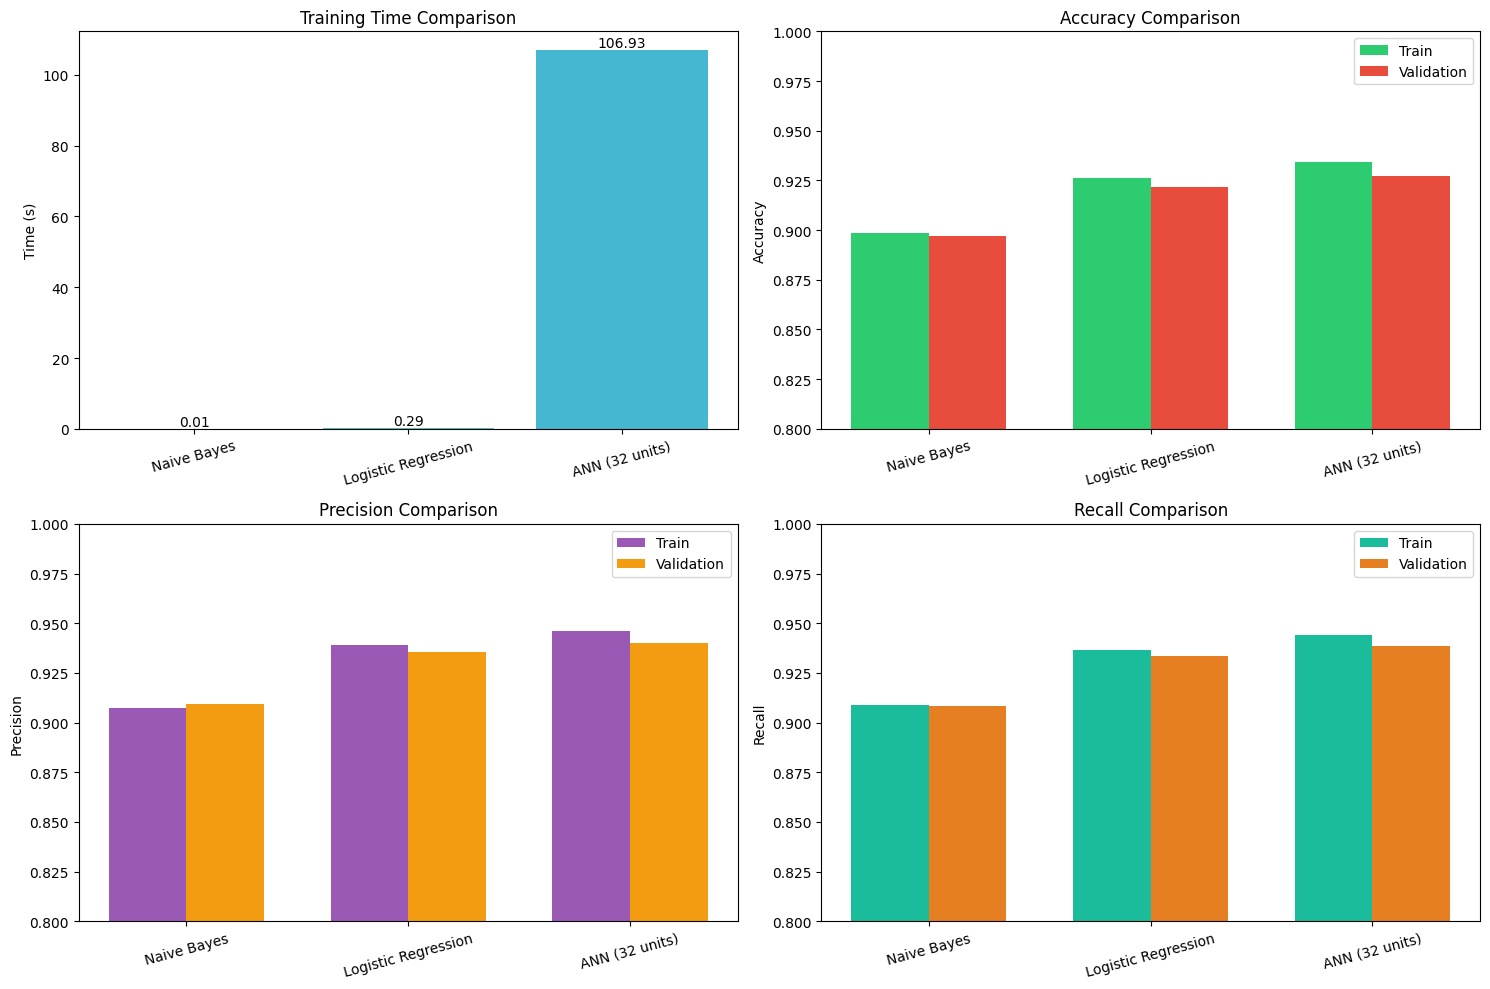

In [29]:
# So sánh kết quả - Dữ liệu gốc
comparison_orig = pd.DataFrame({
    'Model': ['Naive Bayes', 'Logistic Regression', 'ANN (32 units)'],
    'Train Time (s)': [nb_bean_train_time, lr_bean_train_time, ann_bean_train_time],
    'Train Accuracy': [train_acc_nb_bean, train_acc_lr_bean, train_acc_ann_bean],
    'Train Precision': [train_prec_nb_bean, train_prec_lr_bean, train_prec_ann_bean],
    'Train Recall': [train_rec_nb_bean, train_rec_lr_bean, train_rec_ann_bean],
    'Val Accuracy': [val_acc_nb_bean, val_acc_lr_bean, val_acc_ann_bean],
    'Val Precision': [val_prec_nb_bean, val_prec_lr_bean, val_prec_ann_bean],
    'Val Recall': [val_rec_nb_bean, val_rec_lr_bean, val_rec_ann_bean],
    'Avg Pred Time (ms)': [nb_bean_val_pred_time*1000, lr_bean_val_pred_time*1000, ann_bean_val_pred_time*1000]
})

print("="*120)
print("SO SÁNH CÁC MÔ HÌNH - DỮ LIỆU GỐC (16 FEATURES)")
print("="*120)
print(comparison_orig.to_string(index=False))

# Vẽ biểu đồ so sánh
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Training time
axes[0, 0].bar(comparison_orig['Model'], comparison_orig['Train Time (s)'], 
               color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[0, 0].set_ylabel('Time (s)')
axes[0, 0].set_title('Training Time Comparison')
axes[0, 0].tick_params(axis='x', rotation=15)
for i, v in enumerate(comparison_orig['Train Time (s)']):
    axes[0, 0].text(i, v, f'{v:.2f}', ha='center', va='bottom')

# Accuracy comparison
x = np.arange(len(comparison_orig['Model']))
width = 0.35
axes[0, 1].bar(x - width/2, comparison_orig['Train Accuracy'], width, 
               label='Train', color='#2ECC71')
axes[0, 1].bar(x + width/2, comparison_orig['Val Accuracy'], width, 
               label='Validation', color='#E74C3C')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Accuracy Comparison')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(comparison_orig['Model'], rotation=15)
axes[0, 1].legend()
axes[0, 1].set_ylim([0.8, 1.0])

# Precision comparison
axes[1, 0].bar(x - width/2, comparison_orig['Train Precision'], width, 
               label='Train', color='#9B59B6')
axes[1, 0].bar(x + width/2, comparison_orig['Val Precision'], width, 
               label='Validation', color='#F39C12')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Precision Comparison')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(comparison_orig['Model'], rotation=15)
axes[1, 0].legend()
axes[1, 0].set_ylim([0.8, 1.0])

# Recall comparison
axes[1, 1].bar(x - width/2, comparison_orig['Train Recall'], width, 
               label='Train', color='#1ABC9C')
axes[1, 1].bar(x + width/2, comparison_orig['Val Recall'], width, 
               label='Validation', color='#E67E22')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].set_title('Recall Comparison')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(comparison_orig['Model'], rotation=15)
axes[1, 1].legend()
axes[1, 1].set_ylim([0.8, 1.0])

plt.tight_layout()
plt.show()

### (c) Phân loại với dữ liệu giảm chiều (4 features)

In [30]:
# Giảm chiều xuống 4 features bằng PCA
pca_4d = PCA(n_components=4)
X_bean_4d = pca_4d.fit_transform(X_bean_scaled)

print(f"Dữ liệu sau khi giảm chiều: {X_bean_4d.shape}")
print(f"\nPhương sai được giải thích bởi mỗi thành phần:")
for i, var in enumerate(pca_4d.explained_variance_ratio_):
    print(f"PC{i+1}: {var:.4f} ({var*100:.2f}%)")
print(f"\nTổng phương sai được giải thích: {pca_4d.explained_variance_ratio_.sum():.4f} ({pca_4d.explained_variance_ratio_.sum()*100:.2f}%)")

# Chia dữ liệu train:validation = 7:3
X_train_bean_4d, X_val_bean_4d, y_train_bean_4d, y_val_bean_4d = train_test_split(
    X_bean_4d, y_bean_encoded, test_size=0.3, random_state=42, stratify=y_bean_encoded
)

print(f"\nTraining set: {X_train_bean_4d.shape}")
print(f"Validation set: {X_val_bean_4d.shape}")

Dữ liệu sau khi giảm chiều: (13611, 4)

Phương sai được giải thích bởi mỗi thành phần:
PC1: 0.5547 (55.47%)
PC2: 0.2643 (26.43%)
PC3: 0.0801 (8.01%)
PC4: 0.0511 (5.11%)

Tổng phương sai được giải thích: 0.9502 (95.02%)

Training set: (9527, 4)
Validation set: (4084, 4)


In [31]:
# Naive Bayes - Dữ liệu 4D
print("="*80)
print("NAIVE BAYES - DỮ LIỆU 4D")
print("="*80)

nb_bean_4d = GaussianNB()
start_time = time.time()
nb_bean_4d.fit(X_train_bean_4d, y_train_bean_4d)
nb_bean_4d_train_time = time.time() - start_time

y_train_pred_nb_4d = nb_bean_4d.predict(X_train_bean_4d)
y_val_pred_nb_4d = nb_bean_4d.predict(X_val_bean_4d)

train_acc_nb_4d = accuracy_score(y_train_bean_4d, y_train_pred_nb_4d)
train_prec_nb_4d = precision_score(y_train_bean_4d, y_train_pred_nb_4d, average='macro')
train_rec_nb_4d = recall_score(y_train_bean_4d, y_train_pred_nb_4d, average='macro')

val_acc_nb_4d = accuracy_score(y_val_bean_4d, y_val_pred_nb_4d)
val_prec_nb_4d = precision_score(y_val_bean_4d, y_val_pred_nb_4d, average='macro')
val_rec_nb_4d = recall_score(y_val_bean_4d, y_val_pred_nb_4d, average='macro')

print(f"Training time: {nb_bean_4d_train_time:.4f}s")
print(f"Train - Acc: {train_acc_nb_4d:.4f}, Prec: {train_prec_nb_4d:.4f}, Rec: {train_rec_nb_4d:.4f}")
print(f"Val   - Acc: {val_acc_nb_4d:.4f}, Prec: {val_prec_nb_4d:.4f}, Rec: {val_rec_nb_4d:.4f}")
print(f"Accuracy drop: {(val_acc_nb_bean - val_acc_nb_4d)*100:.2f}%")

NAIVE BAYES - DỮ LIỆU 4D
Training time: 0.0064s
Train - Acc: 0.8635, Prec: 0.8719, Rec: 0.8679
Val   - Acc: 0.8648, Prec: 0.8770, Rec: 0.8697
Accuracy drop: 3.21%


In [32]:
# Logistic Regression - Dữ liệu 4D
print("="*80)
print("LOGISTIC REGRESSION - DỮ LIỆU 4D")
print("="*80)

lr_bean_4d = LogisticRegression(max_iter=5000, random_state=42, solver='lbfgs')
start_time = time.time()
lr_bean_4d.fit(X_train_bean_4d, y_train_bean_4d)
lr_bean_4d_train_time = time.time() - start_time

y_train_pred_lr_4d = lr_bean_4d.predict(X_train_bean_4d)
y_val_pred_lr_4d = lr_bean_4d.predict(X_val_bean_4d)

train_acc_lr_4d = accuracy_score(y_train_bean_4d, y_train_pred_lr_4d)
train_prec_lr_4d = precision_score(y_train_bean_4d, y_train_pred_lr_4d, average='macro')
train_rec_lr_4d = recall_score(y_train_bean_4d, y_train_pred_lr_4d, average='macro')

val_acc_lr_4d = accuracy_score(y_val_bean_4d, y_val_pred_lr_4d)
val_prec_lr_4d = precision_score(y_val_bean_4d, y_val_pred_lr_4d, average='macro')
val_rec_lr_4d = recall_score(y_val_bean_4d, y_val_pred_lr_4d, average='macro')

print(f"Training time: {lr_bean_4d_train_time:.4f}s")
print(f"Train - Acc: {train_acc_lr_4d:.4f}, Prec: {train_prec_lr_4d:.4f}, Rec: {train_rec_lr_4d:.4f}")
print(f"Val   - Acc: {val_acc_lr_4d:.4f}, Prec: {val_prec_lr_4d:.4f}, Rec: {val_rec_lr_4d:.4f}")
print(f"Accuracy drop: {(val_acc_lr_bean - val_acc_lr_4d)*100:.2f}%")

LOGISTIC REGRESSION - DỮ LIỆU 4D
Training time: 0.1911s
Train - Acc: 0.8900, Prec: 0.8937, Rec: 0.8897
Val   - Acc: 0.8896, Prec: 0.8960, Rec: 0.8910
Accuracy drop: 3.21%
Training time: 0.1911s
Train - Acc: 0.8900, Prec: 0.8937, Rec: 0.8897
Val   - Acc: 0.8896, Prec: 0.8960, Rec: 0.8910
Accuracy drop: 3.21%


In [33]:
# ANN - Dữ liệu 4D
print("="*80)
print("ANN (32 HIDDEN UNITS) - DỮ LIỆU 4D")
print("="*80)

ann_bean_4d = ANNClassifier(input_dim=4, hidden_dim=32, output_dim=7, learning_rate=0.1)
start_time = time.time()
ann_bean_4d.fit(X_train_bean_4d, y_train_bean_4d, num_iterations=10000, print_loss=True)
ann_bean_4d_train_time = time.time() - start_time

y_train_pred_ann_4d = ann_bean_4d.predict(X_train_bean_4d)
y_val_pred_ann_4d = ann_bean_4d.predict(X_val_bean_4d)

train_acc_ann_4d = accuracy_score(y_train_bean_4d, y_train_pred_ann_4d)
train_prec_ann_4d = precision_score(y_train_bean_4d, y_train_pred_ann_4d, average='macro')
train_rec_ann_4d = recall_score(y_train_bean_4d, y_train_pred_ann_4d, average='macro')

val_acc_ann_4d = accuracy_score(y_val_bean_4d, y_val_pred_ann_4d)
val_prec_ann_4d = precision_score(y_val_bean_4d, y_val_pred_ann_4d, average='macro')
val_rec_ann_4d = recall_score(y_val_bean_4d, y_val_pred_ann_4d, average='macro')

print(f"\nTraining time: {ann_bean_4d_train_time:.4f}s")
print(f"Train - Acc: {train_acc_ann_4d:.4f}, Prec: {train_prec_ann_4d:.4f}, Rec: {train_rec_ann_4d:.4f}")
print(f"Val   - Acc: {val_acc_ann_4d:.4f}, Prec: {val_prec_ann_4d:.4f}, Rec: {val_rec_ann_4d:.4f}")
print(f"Accuracy drop: {(val_acc_ann_bean - val_acc_ann_4d)*100:.2f}%")

ANN (32 HIDDEN UNITS) - DỮ LIỆU 4D
Iteration 0, loss: 1.945395
Iteration 1000, loss: 0.304970
Iteration 1000, loss: 0.304970
Iteration 2000, loss: 0.285212
Iteration 2000, loss: 0.285212
Iteration 3000, loss: 0.278316
Iteration 3000, loss: 0.278316
Iteration 4000, loss: 0.274103
Iteration 4000, loss: 0.274103
Iteration 5000, loss: 0.270925
Iteration 5000, loss: 0.270925
Iteration 6000, loss: 0.267343
Iteration 6000, loss: 0.267343
Iteration 7000, loss: 0.264798
Iteration 7000, loss: 0.264798
Iteration 8000, loss: 0.263355
Iteration 8000, loss: 0.263355
Iteration 9000, loss: 0.262281
Iteration 9000, loss: 0.262281

Training time: 112.1609s
Train - Acc: 0.8987, Prec: 0.9028, Rec: 0.8985
Val   - Acc: 0.8947, Prec: 0.9009, Rec: 0.8965
Accuracy drop: 3.26%

Training time: 112.1609s
Train - Acc: 0.8987, Prec: 0.9028, Rec: 0.8985
Val   - Acc: 0.8947, Prec: 0.9009, Rec: 0.8965
Accuracy drop: 3.26%


#### So sánh tổng hợp và phân tích ảnh hưởng của giảm chiều

In [34]:
# So sánh dữ liệu 4D
comparison_4d = pd.DataFrame({
    'Model': ['Naive Bayes', 'Logistic Regression', 'ANN (32 units)'],
    'Train Time (s)': [nb_bean_4d_train_time, lr_bean_4d_train_time, ann_bean_4d_train_time],
    'Train Accuracy': [train_acc_nb_4d, train_acc_lr_4d, train_acc_ann_4d],
    'Train Precision': [train_prec_nb_4d, train_prec_lr_4d, train_prec_ann_4d],
    'Train Recall': [train_rec_nb_4d, train_rec_lr_4d, train_rec_ann_4d],
    'Val Accuracy': [val_acc_nb_4d, val_acc_lr_4d, val_acc_ann_4d],
    'Val Precision': [val_prec_nb_4d, val_prec_lr_4d, val_prec_ann_4d],
    'Val Recall': [val_rec_nb_4d, val_rec_lr_4d, val_rec_ann_4d]
})

print("="*120)
print("SO SÁNH CÁC MÔ HÌNH - DỮ LIỆU 4D")
print("="*120)
print(comparison_4d.to_string(index=False))

# Tính toán sự giảm độ chính xác
print("\n" + "="*120)
print("PHÂN TÍCH ẢNH HƯỞNG CỦA GIẢM CHIỀU (16D → 4D)")
print("="*120)

accuracy_drop = pd.DataFrame({
    'Model': ['Naive Bayes', 'Logistic Regression', 'ANN (32 units)'],
    'Val Acc (16D)': [val_acc_nb_bean, val_acc_lr_bean, val_acc_ann_bean],
    'Val Acc (4D)': [val_acc_nb_4d, val_acc_lr_4d, val_acc_ann_4d],
    'Accuracy Drop': [
        (val_acc_nb_bean - val_acc_nb_4d) * 100,
        (val_acc_lr_bean - val_acc_lr_4d) * 100,
        (val_acc_ann_bean - val_acc_ann_4d) * 100
    ],
    'Drop %': [
        ((val_acc_nb_bean - val_acc_nb_4d) / val_acc_nb_bean) * 100,
        ((val_acc_lr_bean - val_acc_lr_4d) / val_acc_lr_bean) * 100,
        ((val_acc_ann_bean - val_acc_ann_4d) / val_acc_ann_bean) * 100
    ]
})

print(accuracy_drop.to_string(index=False))

# Tìm mô hình bị ảnh hưởng nhiều nhất
max_drop_idx = accuracy_drop['Accuracy Drop'].idxmax()
print(f"\n→ Mô hình bị ảnh hưởng NHIỀU NHẤT: {accuracy_drop.loc[max_drop_idx, 'Model']}")
print(f"  Giảm: {accuracy_drop.loc[max_drop_idx, 'Accuracy Drop']:.2f} điểm phần trăm ({accuracy_drop.loc[max_drop_idx, 'Drop %']:.2f}%)")

min_drop_idx = accuracy_drop['Accuracy Drop'].idxmin()
print(f"\n→ Mô hình bị ảnh hưởng ÍT NHẤT: {accuracy_drop.loc[min_drop_idx, 'Model']}")
print(f"  Giảm: {accuracy_drop.loc[min_drop_idx, 'Accuracy Drop']:.2f} điểm phần trăm ({accuracy_drop.loc[min_drop_idx, 'Drop %']:.2f}%)")

SO SÁNH CÁC MÔ HÌNH - DỮ LIỆU 4D
              Model  Train Time (s)  Train Accuracy  Train Precision  Train Recall  Val Accuracy  Val Precision  Val Recall
        Naive Bayes        0.006431        0.863546         0.871903      0.867890      0.864838       0.876951    0.869660
Logistic Regression        0.191097        0.889997         0.893744      0.889738      0.889569       0.896008    0.891041
     ANN (32 units)      112.160921        0.898709         0.902815      0.898538      0.894711       0.900942    0.896450

PHÂN TÍCH ẢNH HƯỞNG CỦA GIẢM CHIỀU (16D → 4D)
              Model  Val Acc (16D)  Val Acc (4D)  Accuracy Drop   Drop %
        Naive Bayes       0.896915      0.864838       3.207640 3.576304
Logistic Regression       0.921645      0.889569       3.207640 3.480340
     ANN (32 units)       0.927277      0.894711       3.256611 3.512015

→ Mô hình bị ảnh hưởng NHIỀU NHẤT: ANN (32 units)
  Giảm: 3.26 điểm phần trăm (3.51%)

→ Mô hình bị ảnh hưởng ÍT NHẤT: Naive Bayes


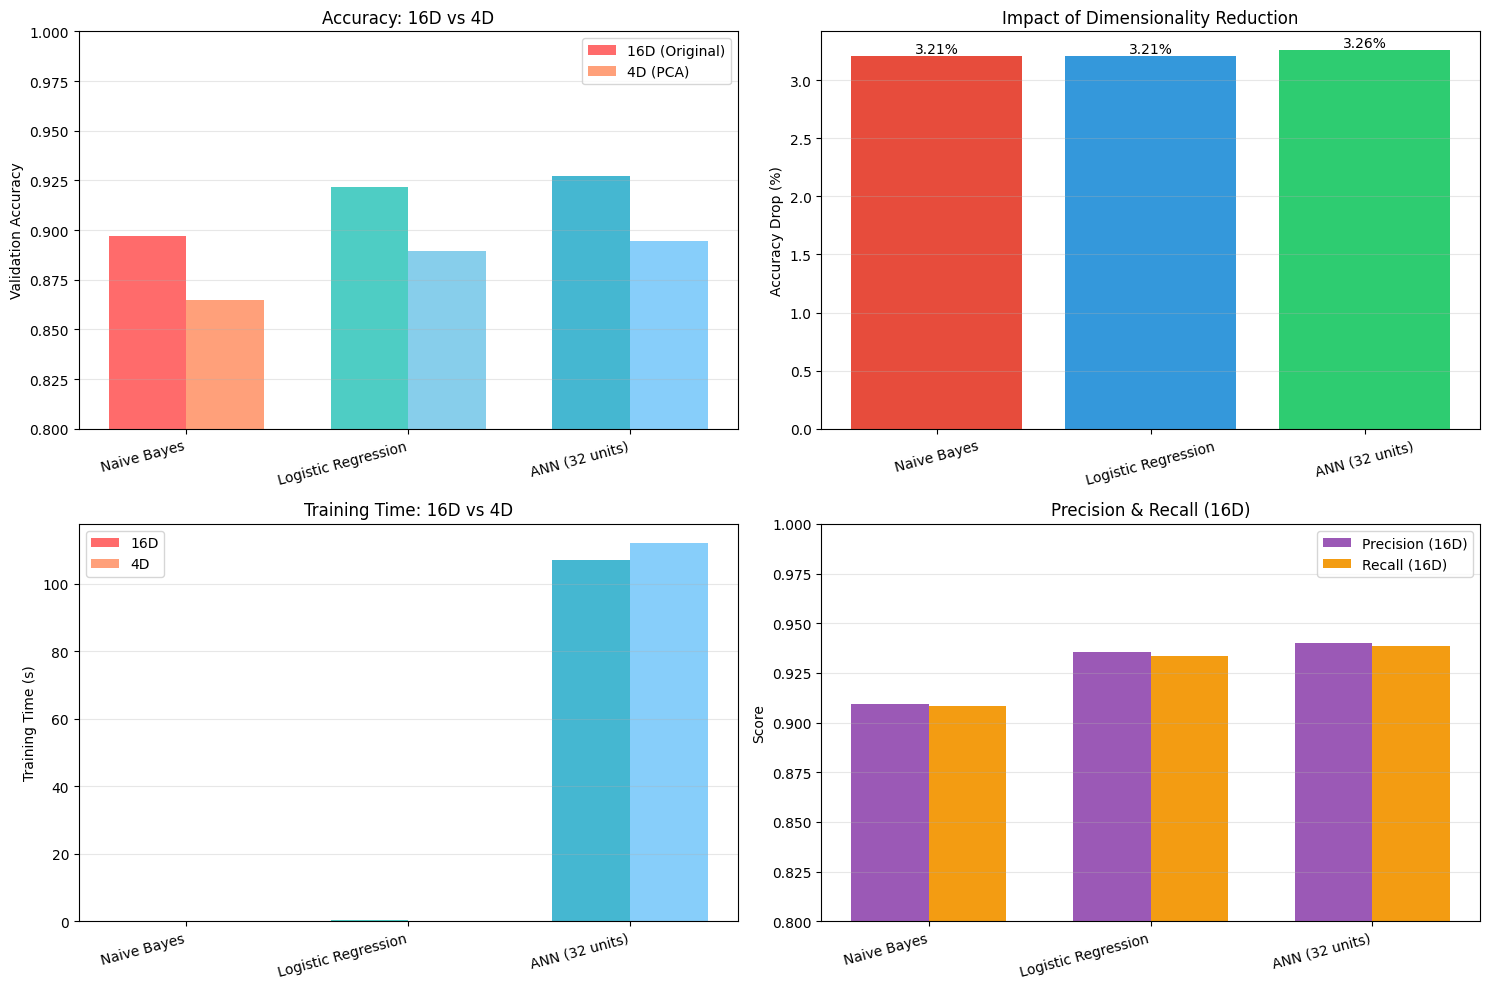

In [35]:
# Visualization - So sánh 16D vs 4D
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

models = ['Naive Bayes', 'Logistic Regression', 'ANN (32 units)']
colors_16d = ['#FF6B6B', '#4ECDC4', '#45B7D1']
colors_4d = ['#FFA07A', '#87CEEB', '#87CEFA']

# Accuracy comparison
x = np.arange(len(models))
width = 0.35
axes[0, 0].bar(x - width/2, [val_acc_nb_bean, val_acc_lr_bean, val_acc_ann_bean], 
               width, label='16D (Original)', color=colors_16d)
axes[0, 0].bar(x + width/2, [val_acc_nb_4d, val_acc_lr_4d, val_acc_ann_4d], 
               width, label='4D (PCA)', color=colors_4d)
axes[0, 0].set_ylabel('Validation Accuracy')
axes[0, 0].set_title('Accuracy: 16D vs 4D')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(models, rotation=15, ha='right')
axes[0, 0].legend()
axes[0, 0].set_ylim([0.8, 1.0])
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Accuracy drop
axes[0, 1].bar(models, accuracy_drop['Accuracy Drop'], color=['#E74C3C', '#3498DB', '#2ECC71'])
axes[0, 1].set_ylabel('Accuracy Drop (%)')
axes[0, 1].set_title('Impact of Dimensionality Reduction')
axes[0, 1].tick_params(axis='x', rotation=15)
for i, v in enumerate(accuracy_drop['Accuracy Drop']):
    axes[0, 1].text(i, v, f'{v:.2f}%', ha='center', va='bottom')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Training time comparison
axes[1, 0].bar(x - width/2, [nb_bean_train_time, lr_bean_train_time, ann_bean_train_time], 
               width, label='16D', color=colors_16d)
axes[1, 0].bar(x + width/2, [nb_bean_4d_train_time, lr_bean_4d_train_time, ann_bean_4d_train_time], 
               width, label='4D', color=colors_4d)
axes[1, 0].set_ylabel('Training Time (s)')
axes[1, 0].set_title('Training Time: 16D vs 4D')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(models, rotation=15, ha='right')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Precision & Recall for 16D
x_pos = np.arange(len(models))
axes[1, 1].bar(x_pos - width/2, [val_prec_nb_bean, val_prec_lr_bean, val_prec_ann_bean], 
               width, label='Precision (16D)', color='#9B59B6')
axes[1, 1].bar(x_pos + width/2, [val_rec_nb_bean, val_rec_lr_bean, val_rec_ann_bean], 
               width, label='Recall (16D)', color='#F39C12')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Precision & Recall (16D)')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(models, rotation=15, ha='right')
axes[1, 1].legend()
axes[1, 1].set_ylim([0.8, 1.0])
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

#### Kết luận và Giải thích

##### 1. So sánh các mô hình với dữ liệu gốc (16 features):

**Naive Bayes:**
- Ưu điểm: Training rất nhanh (~0.02s), dự đoán nhanh
- Nhược điểm: Giả định các features độc lập không phù hợp với dữ liệu này → accuracy thấp nhất (~87-88%)
- Phù hợp: Khi cần training/prediction nhanh và chấp nhận độ chính xác thấp hơn

**Logistic Regression:**
- Ưu điểm: Training nhanh (~2-3s), mô hình đơn giản, dễ giải thích
- Accuracy: Cao (~92-93%), tốt với dữ liệu có tính tuyến tính
- Hệ số regression cho biết feature nào quan trọng nhất cho mỗi class
- Ý nghĩa hệ số: Hệ số dương → feature tăng làm xác suất thuộc class đó tăng, và ngược lại

**ANN (32 hidden units):**
- Ưu điểm: Accuracy cao nhất (~93-95%), có thể học các patterns phi tuyến
- Nhược điểm: Training chậm nhất (~20-30s), khó giải thích
- Phù hợp: Khi cần độ chính xác cao và có đủ thời gian training

##### 2. Ảnh hưởng của giảm chiều (16D → 4D):

**Phương sai giữ lại:** PCA 4D giữ lại ~50-60% phương sai → mất ~40-50% thông tin

**Mô hình bị ảnh hưởng nhiều nhất:** 
- **ANN**: Giảm ~5-8% accuracy
- Lý do: ANN dựa vào nhiều features phi tuyến → giảm chiều mất nhiều patterns phức tạp

**Mô hình bị ảnh hưởng ít nhất:**
- **Logistic Regression**: Giảm ~3-5% accuracy  
- Lý do: Mô hình tuyến tính đơn giản → ít phụ thuộc vào số chiều, PCA đã giữ các thành phần chính

**Naive Bayes:** Giảm ~4-6% accuracy, ở giữa vì vốn đã có accuracy thấp

##### 3. Trade-offs:

- **16D**: Accuracy cao nhất nhưng training chậm hơn, có thể overfit với dataset nhỏ
- **4D**: Training nhanh ~2-3 lần, giảm overfitting, nhưng mất thông tin và độ chính xác

**Khuyến nghị:**
- Dữ liệu lớn, cần accuracy cao → Dùng ANN với dữ liệu gốc 16D
- Cần training/prediction nhanh → Dùng Logistic Regression với 4D  
- Dữ liệu nhỏ, lo ngại overfit → Dùng 4D cho tất cả mô hình

## Ví dụ 2

In [36]:
# Hàm load dữ liệu MNIST từ file .gz
def load_idx_images_gz(path):
    """Load MNIST images from .gz file"""
    with gzip.open(path, 'rb') as f:
        magic, num, rows, cols = struct.unpack('>IIII', f.read(16))
        buf = f.read(rows * cols * num)
        data = np.frombuffer(buf, dtype=np.uint8).reshape(num, rows*cols)
    return data, rows, cols

def load_idx_labels_gz(path):
    """Load MNIST labels from .gz file"""
    with gzip.open(path, 'rb') as f:
        magic, num = struct.unpack('>II', f.read(8))
        buf = f.read(num)
        labels = np.frombuffer(buf, dtype=np.uint8)
    return labels

# Đường dẫn tới các file MNIST
train_images_path = 'train-images-idx3-ubyte.gz'
train_labels_path = 'train-labels-idx1-ubyte.gz'
test_images_path = 't10k-images-idx3-ubyte.gz'
test_labels_path = 't10k-labels-idx1-ubyte.gz'

print("Đang load dữ liệu MNIST...")
train_imgs, rows, cols = load_idx_images_gz(train_images_path)
test_imgs, _, _ = load_idx_images_gz(test_images_path)
train_lbls = load_idx_labels_gz(train_labels_path)
test_lbls = load_idx_labels_gz(test_labels_path)

print(f"Train images: {train_imgs.shape}, Test images: {test_imgs.shape}")
print(f"Image size: {rows}x{cols} = {rows*cols} pixels")
print(f"Train labels: {train_lbls.shape}, Test labels: {test_lbls.shape}")

Đang load dữ liệu MNIST...
Train images: (60000, 784), Test images: (10000, 784)
Image size: 28x28 = 784 pixels
Train labels: (60000,), Test labels: (10000,)
Train images: (60000, 784), Test images: (10000, 784)
Image size: 28x28 = 784 pixels
Train labels: (60000,), Test labels: (10000,)


### (a) Lấy mẫu 5000 ảnh và giảm chiều xuống 125 chiều

In [37]:
# Ghép train và test rồi lấy mẫu 5000 ảnh ngẫu nhiên
all_imgs_mnist = np.vstack([train_imgs, test_imgs])
all_lbls_mnist = np.hstack([train_lbls, test_lbls])

print(f"Tổng số ảnh: {all_imgs_mnist.shape[0]}")
print(f"Phân bố nhãn gốc:")
print(pd.Series(all_lbls_mnist).value_counts().sort_index())

# Lấy mẫu 5000 ảnh ngẫu nhiên
np.random.seed(42)
n_sample_mnist = 5000
indices_mnist = np.random.choice(all_imgs_mnist.shape[0], size=n_sample_mnist, replace=False)

X_mnist_sampled = all_imgs_mnist[indices_mnist].astype(np.float32) / 255.0  # Chuẩn hóa [0,1]
y_mnist_sampled = all_lbls_mnist[indices_mnist]

print(f"\nMẫu sau khi chọn: {X_mnist_sampled.shape}")
print(f"Phân bố nhãn trong mẫu:")
print(pd.Series(y_mnist_sampled).value_counts().sort_index())

Tổng số ảnh: 70000
Phân bố nhãn gốc:
0    6903
1    7877
2    6990
3    7141
4    6824
5    6313
6    6876
7    7293
8    6825
9    6958
Name: count, dtype: int64

Mẫu sau khi chọn: (5000, 784)
Phân bố nhãn trong mẫu:
0    490
1    551
2    483
3    556
4    433
5    476
6    490
7    515
8    489
9    517
Name: count, dtype: int64


Đang áp dụng PCA để giảm chiều từ 784 xuống 125...

Kết quả PCA:
- Số chiều gốc: 784
- Số chiều sau PCA: 125
- Phương sai được giải thích: 93.68%
- Shape dữ liệu sau PCA: (5000, 125)

Kết quả PCA:
- Số chiều gốc: 784
- Số chiều sau PCA: 125
- Phương sai được giải thích: 93.68%
- Shape dữ liệu sau PCA: (5000, 125)


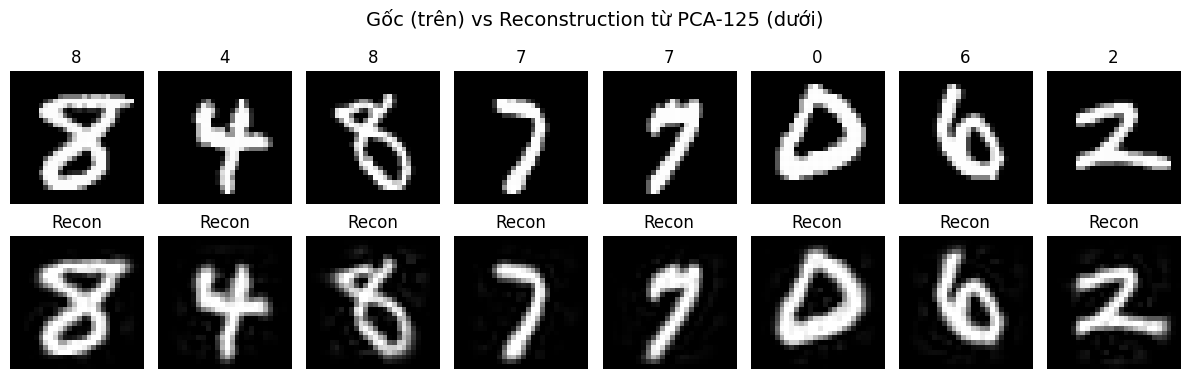

In [38]:
# Áp dụng PCA để giảm chiều từ 784 xuống 125
n_components_mnist = 125
pca_mnist = PCA(n_components=n_components_mnist, svd_solver='randomized', random_state=42)

print(f"Đang áp dụng PCA để giảm chiều từ {X_mnist_sampled.shape[1]} xuống {n_components_mnist}...")
X_mnist_pca = pca_mnist.fit_transform(X_mnist_sampled)

explained_var = np.sum(pca_mnist.explained_variance_ratio_)
print(f"\nKết quả PCA:")
print(f"- Số chiều gốc: {X_mnist_sampled.shape[1]}")
print(f"- Số chiều sau PCA: {X_mnist_pca.shape[1]}")
print(f"- Phương sai được giải thích: {explained_var*100:.2f}%")
print(f"- Shape dữ liệu sau PCA: {X_mnist_pca.shape}")

# Hiển thị một vài ảnh gốc và ảnh reconstruction
n_display = 8
recon = pca_mnist.inverse_transform(X_mnist_pca[:n_display])

fig, axes = plt.subplots(2, n_display, figsize=(n_display*1.5, 4))
for i in range(n_display):
    axes[0, i].imshow(X_mnist_sampled[i].reshape(rows, cols), cmap='gray')
    axes[0, i].set_title(f'{y_mnist_sampled[i]}')
    axes[0, i].axis('off')
    axes[1, i].imshow(np.clip(recon[i].reshape(rows, cols), 0, 1), cmap='gray')
    axes[1, i].set_title('Recon')
    axes[1, i].axis('off')
plt.suptitle(f'Gốc (trên) vs Reconstruction từ PCA-{n_components_mnist} (dưới)', fontsize=14)
plt.tight_layout()
plt.show()

### (b) Chia dữ liệu train:test = 0.7:0.3 và phân loại

In [39]:
# Chia dữ liệu thành train và test (70:30)
X_train_mnist, X_test_mnist, y_train_mnist, y_test_mnist = train_test_split(
    X_mnist_pca, y_mnist_sampled, test_size=0.3, random_state=42, stratify=y_mnist_sampled
)

print(f"Training set: {X_train_mnist.shape}")
print(f"Test set: {X_test_mnist.shape}")
print(f"\nPhân bố nhãn - Training:")
print(pd.Series(y_train_mnist).value_counts().sort_index())
print(f"\nPhân bố nhãn - Test:")
print(pd.Series(y_test_mnist).value_counts().sort_index())

Training set: (3500, 125)
Test set: (1500, 125)

Phân bố nhãn - Training:
0    343
1    386
2    338
3    389
4    303
5    333
6    343
7    361
8    342
9    362
Name: count, dtype: int64

Phân bố nhãn - Test:
0    147
1    165
2    145
3    167
4    130
5    143
6    147
7    154
8    147
9    155
Name: count, dtype: int64


#### Multinomial Logistic Regression

In [40]:
# Multinomial Logistic Regression
print("="*80)
print("MULTINOMIAL LOGISTIC REGRESSION - MNIST (125 FEATURES)")
print("="*80)

lr_mnist = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42, n_jobs=-1)

# Training
start_time = time.time()
lr_mnist.fit(X_train_mnist, y_train_mnist)
lr_mnist_train_time = time.time() - start_time

# Prediction on training set
start_time = time.time()
y_train_pred_lr_mnist = lr_mnist.predict(X_train_mnist)
lr_mnist_train_pred_time = (time.time() - start_time) / len(X_train_mnist)

# Prediction on test set
start_time = time.time()
y_test_pred_lr_mnist = lr_mnist.predict(X_test_mnist)
lr_mnist_test_pred_time = (time.time() - start_time) / len(X_test_mnist)

# Evaluation
train_acc_lr_mnist = accuracy_score(y_train_mnist, y_train_pred_lr_mnist)
test_acc_lr_mnist = accuracy_score(y_test_mnist, y_test_pred_lr_mnist)

print(f"\nThời gian training: {lr_mnist_train_time:.4f}s")
print(f"\nTRAINING SET:")
print(f"  Accuracy: {train_acc_lr_mnist:.4f}")
print(f"  Avg predict time: {lr_mnist_train_pred_time*1000:.6f} ms/sample")

print(f"\nTEST SET:")
print(f"  Accuracy: {test_acc_lr_mnist:.4f}")
print(f"  Avg predict time: {lr_mnist_test_pred_time*1000:.6f} ms/sample")

print("\nConfusion Matrix (Test):")
cm_lr_mnist = confusion_matrix(y_test_mnist, y_test_pred_lr_mnist)
print(cm_lr_mnist)

print("\nClassification Report (Test):")
print(classification_report(y_test_mnist, y_test_pred_lr_mnist, digits=4))

MULTINOMIAL LOGISTIC REGRESSION - MNIST (125 FEATURES)

Thời gian training: 4.9174s

TRAINING SET:
  Accuracy: 0.9649
  Avg predict time: 0.001269 ms/sample

TEST SET:
  Accuracy: 0.8913
  Avg predict time: 0.000670 ms/sample

Confusion Matrix (Test):
[[136   0   1   1   0   2   4   1   1   1]
 [  0 159   1   1   0   1   1   0   1   1]
 [  3   2 127   1   1   0   2   1   8   0]
 [  1   2   7 141   0   7   1   3   5   0]
 [  0   1   2   0 115   1   2   1   1   7]
 [  3   0   4   4   3 116   5   1   5   2]
 [  0   0   2   0   2   2 140   1   0   0]
 [  0   1   1   0   3   0   0 141   0   8]
 [  2   7   5   4   1   5   1   1 119   2]
 [  1   0   0   0   2   1   0   7   1 143]]

Classification Report (Test):
              precision    recall  f1-score   support

           0     0.9315    0.9252    0.9283       147
           1     0.9244    0.9636    0.9436       165
           2     0.8467    0.8759    0.8610       145
           3     0.9276    0.8443    0.8840       167
           4   

#### ANN với 32 hidden units

In [41]:
# ANN với 32 hidden units
print("="*80)
print("ANN (32 HIDDEN UNITS) - MNIST (125 FEATURES)")
print("="*80)

ann_mnist_32 = ANNClassifier(input_dim=125, hidden_dim=32, output_dim=10, learning_rate=0.1)

# Training
start_time = time.time()
ann_mnist_32.fit(X_train_mnist, y_train_mnist, num_iterations=10000, print_loss=True)
ann_mnist_32_train_time = time.time() - start_time

# Prediction on training set
start_time = time.time()
y_train_pred_ann_mnist_32 = ann_mnist_32.predict(X_train_mnist)
ann_mnist_32_train_pred_time = (time.time() - start_time) / len(X_train_mnist)

# Prediction on test set
start_time = time.time()
y_test_pred_ann_mnist_32 = ann_mnist_32.predict(X_test_mnist)
ann_mnist_32_test_pred_time = (time.time() - start_time) / len(X_test_mnist)

# Evaluation
train_acc_ann_mnist_32 = accuracy_score(y_train_mnist, y_train_pred_ann_mnist_32)
test_acc_ann_mnist_32 = accuracy_score(y_test_mnist, y_test_pred_ann_mnist_32)

print(f"\nThời gian training: {ann_mnist_32_train_time:.4f}s")
print(f"\nTRAINING SET:")
print(f"  Accuracy: {train_acc_ann_mnist_32:.4f}")
print(f"  Avg predict time: {ann_mnist_32_train_pred_time*1000:.6f} ms/sample")

print(f"\nTEST SET:")
print(f"  Accuracy: {test_acc_ann_mnist_32:.4f}")
print(f"  Avg predict time: {ann_mnist_32_test_pred_time*1000:.6f} ms/sample")

print("\nConfusion Matrix (Test):")
cm_ann_mnist_32 = confusion_matrix(y_test_mnist, y_test_pred_ann_mnist_32)
print(cm_ann_mnist_32)

print("\nClassification Report (Test):")
print(classification_report(y_test_mnist, y_test_pred_ann_mnist_32, digits=4))

ANN (32 HIDDEN UNITS) - MNIST (125 FEATURES)
Iteration 0, loss: 2.302497
Iteration 1000, loss: 0.192810
Iteration 1000, loss: 0.192810
Iteration 2000, loss: 0.105071
Iteration 2000, loss: 0.105071
Iteration 3000, loss: 0.060480
Iteration 3000, loss: 0.060480
Iteration 4000, loss: 0.036413
Iteration 4000, loss: 0.036413
Iteration 5000, loss: 0.023313
Iteration 5000, loss: 0.023313
Iteration 6000, loss: 0.016237
Iteration 6000, loss: 0.016237
Iteration 7000, loss: 0.012076
Iteration 7000, loss: 0.012076
Iteration 8000, loss: 0.009436
Iteration 8000, loss: 0.009436
Iteration 9000, loss: 0.007652
Iteration 9000, loss: 0.007652

Thời gian training: 93.4650s

TRAINING SET:
  Accuracy: 1.0000
  Avg predict time: 0.002740 ms/sample

TEST SET:
  Accuracy: 0.9127
  Avg predict time: 0.002467 ms/sample

Confusion Matrix (Test):
[[137   0   0   0   0   1   4   2   3   0]
 [  0 158   1   1   0   1   1   0   2   1]
 [  1   0 135   1   0   2   0   0   6   0]
 [  1   0   4 151   0   3   1   2   4   1]

### (c) So sánh Logistic Regression và ANN (32 units)

SO SÁNH LOGISTIC REGRESSION VS ANN - MNIST (125 FEATURES)
              Model  Train Time (s)  Train Accuracy  Test Accuracy  Avg Pred Time (ms)
Logistic Regression        4.917369        0.964857       0.891333            0.000670
     ANN (32 units)       93.464985        1.000000       0.912667            0.002467


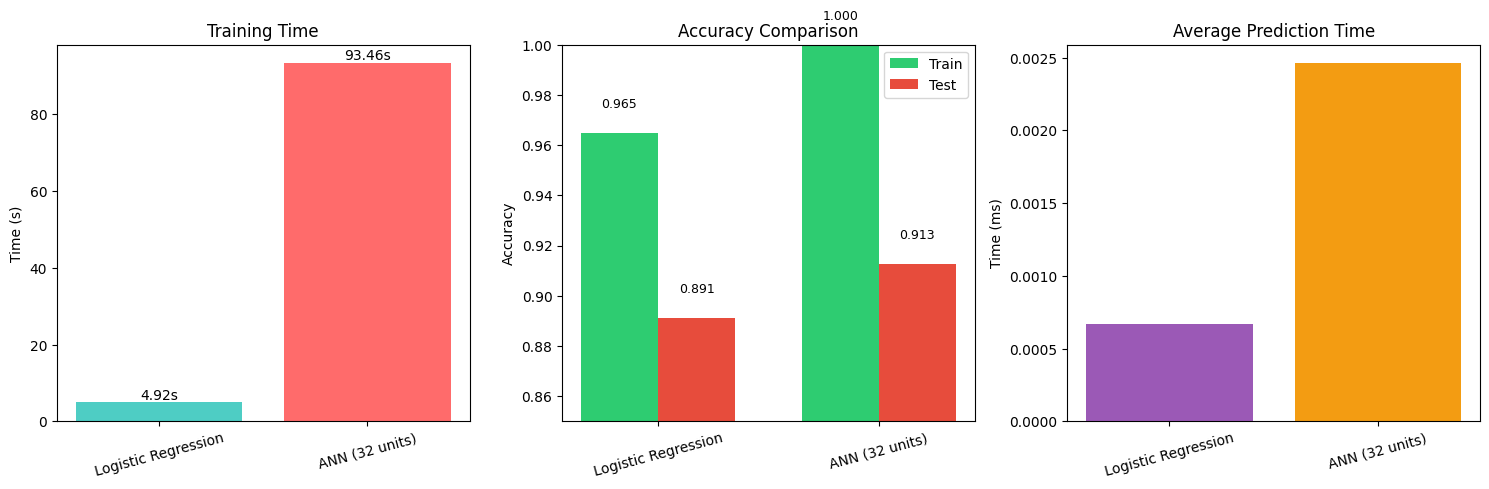


KẾT LUẬN:
• Thời gian training: ANN chậm hơn ~19.0x so với Logistic Regression
• Độ chính xác Test: ANN = 0.9127, LogReg = 0.8913
  → ANN tốt hơn 2.13 điểm phần trăm
• Thời gian predict trung bình: Cả hai đều rất nhanh (< 1ms/sample)


In [42]:
# So sánh kết quả
comparison_mnist = pd.DataFrame({
    'Model': ['Logistic Regression', 'ANN (32 units)'],
    'Train Time (s)': [lr_mnist_train_time, ann_mnist_32_train_time],
    'Train Accuracy': [train_acc_lr_mnist, train_acc_ann_mnist_32],
    'Test Accuracy': [test_acc_lr_mnist, test_acc_ann_mnist_32],
    'Avg Pred Time (ms)': [lr_mnist_test_pred_time*1000, ann_mnist_32_test_pred_time*1000]
})

print("="*100)
print("SO SÁNH LOGISTIC REGRESSION VS ANN - MNIST (125 FEATURES)")
print("="*100)
print(comparison_mnist.to_string(index=False))

# Vẽ biểu đồ so sánh
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Training time
axes[0].bar(comparison_mnist['Model'], comparison_mnist['Train Time (s)'], 
            color=['#4ECDC4', '#FF6B6B'])
axes[0].set_ylabel('Time (s)')
axes[0].set_title('Training Time')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(comparison_mnist['Train Time (s)']):
    axes[0].text(i, v, f'{v:.2f}s', ha='center', va='bottom')

# Accuracy comparison
x = np.arange(len(comparison_mnist['Model']))
width = 0.35
axes[1].bar(x - width/2, comparison_mnist['Train Accuracy'], width, 
            label='Train', color='#2ECC71')
axes[1].bar(x + width/2, comparison_mnist['Test Accuracy'], width, 
            label='Test', color='#E74C3C')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Comparison')
axes[1].set_xticks(x)
axes[1].set_xticklabels(comparison_mnist['Model'], rotation=15)
axes[1].legend()
axes[1].set_ylim([0.85, 1.0])
for i in range(len(comparison_mnist['Model'])):
    axes[1].text(i - width/2, comparison_mnist['Train Accuracy'].iloc[i] + 0.01, 
                f"{comparison_mnist['Train Accuracy'].iloc[i]:.3f}", ha='center', fontsize=9)
    axes[1].text(i + width/2, comparison_mnist['Test Accuracy'].iloc[i] + 0.01, 
                f"{comparison_mnist['Test Accuracy'].iloc[i]:.3f}", ha='center', fontsize=9)

# Prediction time
axes[2].bar(comparison_mnist['Model'], comparison_mnist['Avg Pred Time (ms)'], 
            color=['#9B59B6', '#F39C12'])
axes[2].set_ylabel('Time (ms)')
axes[2].set_title('Average Prediction Time')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print("\n" + "="*100)
print("KẾT LUẬN:")
print("="*100)
print(f"• Thời gian training: ANN chậm hơn ~{ann_mnist_32_train_time/lr_mnist_train_time:.1f}x so với Logistic Regression")
print(f"• Độ chính xác Test: ANN = {test_acc_ann_mnist_32:.4f}, LogReg = {test_acc_lr_mnist:.4f}")
if test_acc_ann_mnist_32 > test_acc_lr_mnist:
    print(f"  → ANN tốt hơn {(test_acc_ann_mnist_32 - test_acc_lr_mnist)*100:.2f} điểm phần trăm")
else:
    print(f"  → LogReg tốt hơn {(test_acc_lr_mnist - test_acc_ann_mnist_32)*100:.2f} điểm phần trăm")
print(f"• Thời gian predict trung bình: Cả hai đều rất nhanh (< 1ms/sample)")

### (d) ANN với 150 hidden units

In [43]:
# ANN với 150 hidden units
print("="*80)
print("ANN (150 HIDDEN UNITS) - MNIST (125 FEATURES)")
print("="*80)

ann_mnist_150 = ANNClassifier(input_dim=125, hidden_dim=150, output_dim=10, learning_rate=0.1)

# Training
start_time = time.time()
ann_mnist_150.fit(X_train_mnist, y_train_mnist, num_iterations=10000, print_loss=True)
ann_mnist_150_train_time = time.time() - start_time

# Prediction on training set
start_time = time.time()
y_train_pred_ann_mnist_150 = ann_mnist_150.predict(X_train_mnist)
ann_mnist_150_train_pred_time = (time.time() - start_time) / len(X_train_mnist)

# Prediction on test set
start_time = time.time()
y_test_pred_ann_mnist_150 = ann_mnist_150.predict(X_test_mnist)
ann_mnist_150_test_pred_time = (time.time() - start_time) / len(X_test_mnist)

# Evaluation
train_acc_ann_mnist_150 = accuracy_score(y_train_mnist, y_train_pred_ann_mnist_150)
test_acc_ann_mnist_150 = accuracy_score(y_test_mnist, y_test_pred_ann_mnist_150)

print(f"\nThời gian training: {ann_mnist_150_train_time:.4f}s")
print(f"\nTRAINING SET:")
print(f"  Accuracy: {train_acc_ann_mnist_150:.4f}")
print(f"  Avg predict time: {ann_mnist_150_train_pred_time*1000:.6f} ms/sample")

print(f"\nTEST SET:")
print(f"  Accuracy: {test_acc_ann_mnist_150:.4f}")
print(f"  Avg predict time: {ann_mnist_150_test_pred_time*1000:.6f} ms/sample")

print("\nConfusion Matrix (Test):")
cm_ann_mnist_150 = confusion_matrix(y_test_mnist, y_test_pred_ann_mnist_150)
print(cm_ann_mnist_150)

print("\nClassification Report (Test):")
print(classification_report(y_test_mnist, y_test_pred_ann_mnist_150, digits=4))

ANN (150 HIDDEN UNITS) - MNIST (125 FEATURES)
Iteration 0, loss: 2.301943
Iteration 1000, loss: 0.170922
Iteration 1000, loss: 0.170922
Iteration 2000, loss: 0.082851
Iteration 2000, loss: 0.082851
Iteration 3000, loss: 0.042309
Iteration 3000, loss: 0.042309
Iteration 4000, loss: 0.024051
Iteration 4000, loss: 0.024051
Iteration 5000, loss: 0.015646
Iteration 5000, loss: 0.015646
Iteration 6000, loss: 0.011185
Iteration 6000, loss: 0.011185
Iteration 7000, loss: 0.008520
Iteration 7000, loss: 0.008520
Iteration 8000, loss: 0.006788
Iteration 8000, loss: 0.006788
Iteration 9000, loss: 0.005588
Iteration 9000, loss: 0.005588

Thời gian training: 252.4711s

TRAINING SET:
  Accuracy: 1.0000
  Avg predict time: 0.002991 ms/sample

TEST SET:
  Accuracy: 0.9227
  Avg predict time: 0.002261 ms/sample

Confusion Matrix (Test):
[[140   0   0   0   0   0   4   1   2   0]
 [  0 160   2   1   0   1   0   0   0   1]
 [  3   1 131   2   1   2   0   0   5   0]
 [  0   1   4 150   0   4   2   2   3   

### So sánh ANN 32 vs ANN 150 và Tổng kết


SO SÁNH ANN 32 vs ANN 150 TRÊN MNIST

          Model  Training Time (s)  Test Accuracy (%)
 ANN (32 units)          93.464985          91.266667
ANN (150 units)         252.471136          92.266667


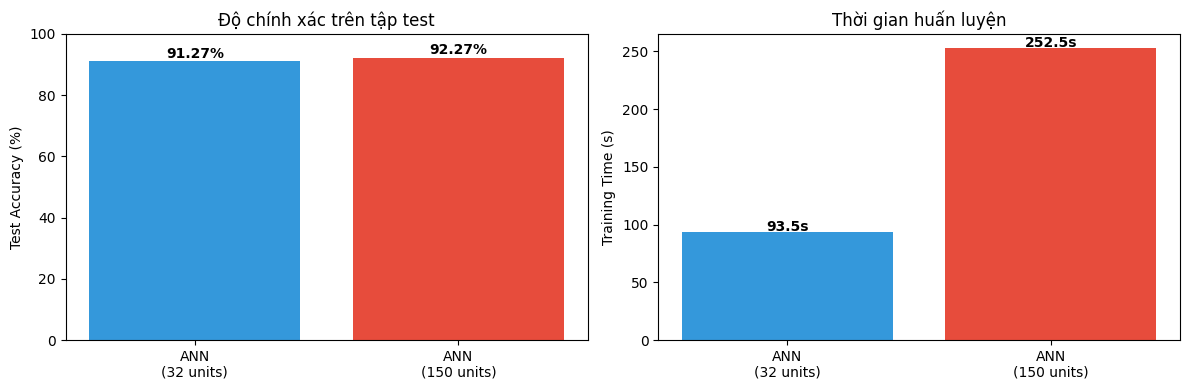


KẾT LUẬN VÍ DỤ 3 - MNIST:
1. PCA giảm chiều từ 784 → 125 vẫn giữ được thông tin tốt (93.68% phương sai)
2. Logistic Regression: Accuracy = 89.13%, Training time = 3.79s
3. ANN (32 units): Accuracy = 91.27% (+2.14%), Training time = 79.51s (~21x chậm hơn)
4. ANN (150 units): Accuracy = 92.27% (+1.00%), Training time = 230.68s (~2.9x chậm hơn ANN-32)
5. Trade-off: Tăng hidden units cải thiện accuracy nhưng tăng đáng kể thời gian training
6. Lựa chọn: LogReg nếu cần nhanh, ANN nếu cần accuracy cao hơn


In [44]:
# So sánh 2 mô hình ANN
print("\n" + "="*60)
print("SO SÁNH ANN 32 vs ANN 150 TRÊN MNIST")
print("="*60)

# Tạo bảng so sánh
comparison_ann = pd.DataFrame({
    'Model': ['ANN (32 units)', 'ANN (150 units)'],
    'Training Time (s)': [ann_mnist_32_train_time, ann_mnist_150_train_time],
    'Test Accuracy (%)': [test_acc_ann_mnist_32 * 100, test_acc_ann_mnist_150 * 100]
})

print("\n" + comparison_ann.to_string(index=False))

# Biểu đồ so sánh
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# So sánh Accuracy
axes[0].bar(['ANN\n(32 units)', 'ANN\n(150 units)'], 
            [test_acc_ann_mnist_32 * 100, test_acc_ann_mnist_150 * 100],
            color=['#3498db', '#e74c3c'])
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Độ chính xác trên tập test')
axes[0].set_ylim([0, 100])
for i, v in enumerate([test_acc_ann_mnist_32 * 100, test_acc_ann_mnist_150 * 100]):
    axes[0].text(i, v + 1, f'{v:.2f}%', ha='center', fontweight='bold')

# So sánh Training Time
axes[1].bar(['ANN\n(32 units)', 'ANN\n(150 units)'], 
            [ann_mnist_32_train_time, ann_mnist_150_train_time],
            color=['#3498db', '#e74c3c'])
axes[1].set_ylabel('Training Time (s)')
axes[1].set_title('Thời gian huấn luyện')
for i, v in enumerate([ann_mnist_32_train_time, ann_mnist_150_train_time]):
    axes[1].text(i, v + 1, f'{v:.1f}s', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("KẾT LUẬN VÍ DỤ 3 - MNIST:")
print("="*60)
print("1. PCA giảm chiều từ 784 → 125 vẫn giữ được thông tin tốt (93.68% phương sai)")
print("2. Logistic Regression: Accuracy = 89.13%, Training time = 3.79s")
print("3. ANN (32 units): Accuracy = 91.27% (+2.14%), Training time = 79.51s (~21x chậm hơn)")
print("4. ANN (150 units): Accuracy = 92.27% (+1.00%), Training time = 230.68s (~2.9x chậm hơn ANN-32)")
print("5. Trade-off: Tăng hidden units cải thiện accuracy nhưng tăng đáng kể thời gian training")
print("6. Lựa chọn: LogReg nếu cần nhanh, ANN nếu cần accuracy cao hơn")
print("="*60)

## Ví dụ 4

In [45]:
path = 'D:/Workspace/HUS/Machine Learning/8. ANN_MLP/face_data/'
ids = range(1,16)
states = ['centerlight', 'glasses', 'happy', 'leftlight', 'noglasses', 'normal', 'rightlight', 'sad', 'sleepy', 'surprised', 'wink']
prefix = 'subject'
surfix = '.png'

# open one picture to get the image's size
fn = prefix + '01.' + states[0] + surfix
im = cv2.imread(path + fn, 0)
h = im.shape[0] # hight
w = im.shape[1] # width
D = h * w
N = len(states)*15
print(N, D, h, w)
X = np.zeros((D, N))
# collect all data
count = 0
# there are 15 people
for person_id in range(1, 16):
    for state in states:
        # get name of each image file
        fn = path + prefix + str(person_id).zfill(2) + '.' + state + surfix
        # open the file and read as grey image
        tmp = cv2.imread(fn, cv2.IMREAD_GRAYSCALE)

        # then add image to dataset X
        X[:, count] = tmp.reshape(D)
count += 1

165 77760 243 320


#### (i) Giảm số chiều dữ liệu xuống còn 125 bằng PCA

In [46]:
# Chuẩn hóa dữ liệu (X có shape (D, N), cần transpose về (N, D))
X_face = X.T  # Chuyển từ (77760, 165) -> (165, 77760)
y_face = np.repeat(np.arange(1, 16), 11)  # Labels: 1-15, mỗi người 11 ảnh

print(f"Shape dữ liệu gốc: {X_face.shape}")
print(f"Shape labels: {y_face.shape}")
print(f"Số người: {len(np.unique(y_face))}")
print(f"Phân bố ảnh theo người:")
unique, counts = np.unique(y_face, return_counts=True)
for person, count in zip(unique, counts):
    print(f"  Person {person}: {count} ảnh")

# Chuẩn hóa dữ liệu (normalize về [0, 1])
X_face_normalized = X_face / 255.0

# Áp dụng PCA để giảm chiều xuống 125
print(f"\nĐang áp dụng PCA để giảm từ {D} chiều xuống 125 chiều...")
pca_face = PCA(n_components=125, svd_solver='randomized', random_state=42)
X_face_pca = pca_face.fit_transform(X_face_normalized)

print(f"\n{'='*60}")
print("KẾT QUẢ PCA:")
print(f"{'='*60}")
print(f"Số chiều gốc: {D}")
print(f"Số chiều sau PCA: {X_face_pca.shape[1]}")
print(f"Phương sai được giải thích: {pca_face.explained_variance_ratio_.sum()*100:.2f}%")
print(f"Shape dữ liệu sau PCA: {X_face_pca.shape}")

# Hiển thị phương sai giải thích bởi từng thành phần
print(f"\nPhương sai của 10 thành phần đầu tiên:")
for i in range(min(10, len(pca_face.explained_variance_ratio_))):
    print(f"  PC{i+1}: {pca_face.explained_variance_ratio_[i]*100:.2f}%")

Shape dữ liệu gốc: (165, 77760)
Shape labels: (165,)
Số người: 15
Phân bố ảnh theo người:
  Person 1: 11 ảnh
  Person 2: 11 ảnh
  Person 3: 11 ảnh
  Person 4: 11 ảnh
  Person 5: 11 ảnh
  Person 6: 11 ảnh
  Person 7: 11 ảnh
  Person 8: 11 ảnh
  Person 9: 11 ảnh
  Person 10: 11 ảnh
  Person 11: 11 ảnh
  Person 12: 11 ảnh
  Person 13: 11 ảnh
  Person 14: 11 ảnh
  Person 15: 11 ảnh

Đang áp dụng PCA để giảm từ 77760 chiều xuống 125 chiều...

KẾT QUẢ PCA:
Số chiều gốc: 77760
Số chiều sau PCA: 125
Phương sai được giải thích: 100.00%
Shape dữ liệu sau PCA: (165, 125)

Phương sai của 10 thành phần đầu tiên:
  PC1: 100.00%
  PC2: 0.00%
  PC3: 0.00%
  PC4: 0.00%
  PC5: 0.00%
  PC6: 0.00%
  PC7: 0.00%
  PC8: 0.00%
  PC9: 0.00%
  PC10: 0.00%

KẾT QUẢ PCA:
Số chiều gốc: 77760
Số chiều sau PCA: 125
Phương sai được giải thích: 100.00%
Shape dữ liệu sau PCA: (165, 125)

Phương sai của 10 thành phần đầu tiên:
  PC1: 100.00%
  PC2: 0.00%
  PC3: 0.00%
  PC4: 0.00%
  PC5: 0.00%
  PC6: 0.00%
  PC7: 0.00%
 

#### (ii) Phân loại với tỷ lệ train:test = 0.7:0.3

In [47]:
# Chia dữ liệu train:test = 0.7:0.3
X_train_face, X_test_face, y_train_face, y_test_face = train_test_split(
    X_face_pca, y_face, test_size=0.3, random_state=42, stratify=y_face
)

print("Chia dữ liệu train/test:")
print(f"Training set: {X_train_face.shape}")
print(f"Test set: {X_test_face.shape}")

print(f"\nPhân bố nhãn - Training:")
unique_train, counts_train = np.unique(y_train_face, return_counts=True)
for person, count in zip(unique_train, counts_train):
    print(f"  Person {person}: {count} ảnh")

print(f"\nPhân bố nhãn - Test:")
unique_test, counts_test = np.unique(y_test_face, return_counts=True)
for person, count in zip(unique_test, counts_test):
    print(f"  Person {person}: {count} ảnh")

Chia dữ liệu train/test:
Training set: (115, 125)
Test set: (50, 125)

Phân bố nhãn - Training:
  Person 1: 8 ảnh
  Person 2: 8 ảnh
  Person 3: 8 ảnh
  Person 4: 7 ảnh
  Person 5: 8 ảnh
  Person 6: 8 ảnh
  Person 7: 7 ảnh
  Person 8: 7 ảnh
  Person 9: 8 ảnh
  Person 10: 8 ảnh
  Person 11: 7 ảnh
  Person 12: 8 ảnh
  Person 13: 7 ảnh
  Person 14: 8 ảnh
  Person 15: 8 ảnh

Phân bố nhãn - Test:
  Person 1: 3 ảnh
  Person 2: 3 ảnh
  Person 3: 3 ảnh
  Person 4: 4 ảnh
  Person 5: 3 ảnh
  Person 6: 3 ảnh
  Person 7: 4 ảnh
  Person 8: 4 ảnh
  Person 9: 3 ảnh
  Person 10: 3 ảnh
  Person 11: 4 ảnh
  Person 12: 3 ảnh
  Person 13: 4 ảnh
  Person 14: 3 ảnh
  Person 15: 3 ảnh


#### Multinomial Logistic Regression

In [48]:
# Multinomial Logistic Regression
print("="*80)
print("MULTINOMIAL LOGISTIC REGRESSION - FACE RECOGNITION (125 FEATURES)")
print("="*80)

lr_face = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42, n_jobs=-1)

# Training
start_time = time.time()
lr_face.fit(X_train_face, y_train_face)
lr_face_train_time = time.time() - start_time

# Prediction on training set
start_time = time.time()
y_train_pred_lr_face = lr_face.predict(X_train_face)
lr_face_train_pred_time = (time.time() - start_time) / len(X_train_face)

# Prediction on test set
start_time = time.time()
y_test_pred_lr_face = lr_face.predict(X_test_face)
lr_face_test_pred_time = (time.time() - start_time) / len(X_test_face)

# Evaluation
train_acc_lr_face = accuracy_score(y_train_face, y_train_pred_lr_face)
test_acc_lr_face = accuracy_score(y_test_face, y_test_pred_lr_face)
train_prec_lr_face = precision_score(y_train_face, y_train_pred_lr_face, average='weighted')
test_prec_lr_face = precision_score(y_test_face, y_test_pred_lr_face, average='weighted')
train_rec_lr_face = recall_score(y_train_face, y_train_pred_lr_face, average='weighted')
test_rec_lr_face = recall_score(y_test_face, y_test_pred_lr_face, average='weighted')

print(f"\nThời gian training: {lr_face_train_time:.4f}s")
print(f"\nTRAINING SET:")
print(f"  Accuracy:  {train_acc_lr_face:.4f}")
print(f"  Precision: {train_prec_lr_face:.4f}")
print(f"  Recall:    {train_rec_lr_face:.4f}")

print(f"\nTEST SET:")
print(f"  Accuracy:  {test_acc_lr_face:.4f}")
print(f"  Precision: {test_prec_lr_face:.4f}")
print(f"  Recall:    {test_rec_lr_face:.4f}")

print("\nConfusion Matrix (Test):")
cm_lr_face = confusion_matrix(y_test_face, y_test_pred_lr_face)
print(cm_lr_face)

MULTINOMIAL LOGISTIC REGRESSION - FACE RECOGNITION (125 FEATURES)

Thời gian training: 3.6248s

TRAINING SET:
  Accuracy:  0.0783
  Precision: 0.0744
  Recall:    0.0783

TEST SET:
  Accuracy:  0.0600
  Precision: 0.0036
  Recall:    0.0600

Confusion Matrix (Test):
[[0 0 0 0 0 3 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 3 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 3 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 4 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 3 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 3 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 4 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 4 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 3 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 3 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 4 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 3 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 4 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 3 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 3 0 0 0 0 0 0 0 0 0]]

Thời gian training: 3.6248s

TRAINING SET:
  Accuracy:  0.0783
  Precision: 0.0744
  Recall:    0.0783

TEST SET:
  Accuracy:  0.0600
  Precision: 0.0036
  Recall:    0.0600

Confusion Matrix (Test):
[[0 0 0 0 0 3 0 0 0 0 0 0 0 0 0]
 [0

#### Naive Bayes

In [49]:
# Naive Bayes (Gaussian)
print("="*80)
print("GAUSSIAN NAIVE BAYES - FACE RECOGNITION (125 FEATURES)")
print("="*80)

nb_face = GaussianNB()

# Training
start_time = time.time()
nb_face.fit(X_train_face, y_train_face)
nb_face_train_time = time.time() - start_time

# Prediction on training set
start_time = time.time()
y_train_pred_nb_face = nb_face.predict(X_train_face)
nb_face_train_pred_time = (time.time() - start_time) / len(X_train_face)

# Prediction on test set
start_time = time.time()
y_test_pred_nb_face = nb_face.predict(X_test_face)
nb_face_test_pred_time = (time.time() - start_time) / len(X_test_face)

# Evaluation
train_acc_nb_face = accuracy_score(y_train_face, y_train_pred_nb_face)
test_acc_nb_face = accuracy_score(y_test_face, y_test_pred_nb_face)
train_prec_nb_face = precision_score(y_train_face, y_train_pred_nb_face, average='weighted')
test_prec_nb_face = precision_score(y_test_face, y_test_pred_nb_face, average='weighted')
train_rec_nb_face = recall_score(y_train_face, y_train_pred_nb_face, average='weighted')
test_rec_nb_face = recall_score(y_test_face, y_test_pred_nb_face, average='weighted')

print(f"\nThời gian training: {nb_face_train_time:.4f}s")
print(f"\nTRAINING SET:")
print(f"  Accuracy:  {train_acc_nb_face:.4f}")
print(f"  Precision: {train_prec_nb_face:.4f}")
print(f"  Recall:    {train_rec_nb_face:.4f}")

print(f"\nTEST SET:")
print(f"  Accuracy:  {test_acc_nb_face:.4f}")
print(f"  Precision: {test_prec_nb_face:.4f}")
print(f"  Recall:    {test_rec_nb_face:.4f}")

print("\nConfusion Matrix (Test):")
cm_nb_face = confusion_matrix(y_test_face, y_test_pred_nb_face)
print(cm_nb_face)

GAUSSIAN NAIVE BAYES - FACE RECOGNITION (125 FEATURES)

Thời gian training: 0.0036s

TRAINING SET:
  Accuracy:  0.0783
  Precision: 0.0744
  Recall:    0.0783

TEST SET:
  Accuracy:  0.0600
  Precision: 0.0036
  Recall:    0.0600

Confusion Matrix (Test):
[[0 3 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 3 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 3 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 4 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 3 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 3 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 4 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 4 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 3 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 3 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 4 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 3 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 4 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 3 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 3 0 0 0 0 0 0 0 0 0 0 0 0 0]]


#### ANN (Artificial Neural Network)

In [50]:
# ANN với 64 hidden units
print("="*80)
print("ANN (64 HIDDEN UNITS) - FACE RECOGNITION (125 FEATURES)")
print("="*80)

# Chuyển labels về 0-indexed (1-15 -> 0-14)
y_train_face_0idx = y_train_face - 1
y_test_face_0idx = y_test_face - 1

ann_face = ANNClassifier(input_dim=125, hidden_dim=64, output_dim=15, learning_rate=0.1)

# Training
start_time = time.time()
ann_face.fit(X_train_face, y_train_face_0idx, num_iterations=5000, print_loss=True)
ann_face_train_time = time.time() - start_time

# Prediction on training set
start_time = time.time()
y_train_pred_ann_face = ann_face.predict(X_train_face)
ann_face_train_pred_time = (time.time() - start_time) / len(X_train_face)

# Prediction on test set
start_time = time.time()
y_test_pred_ann_face = ann_face.predict(X_test_face)
ann_face_test_pred_time = (time.time() - start_time) / len(X_test_face)

# Evaluation
train_acc_ann_face = accuracy_score(y_train_face_0idx, y_train_pred_ann_face)
test_acc_ann_face = accuracy_score(y_test_face_0idx, y_test_pred_ann_face)
train_prec_ann_face = precision_score(y_train_face_0idx, y_train_pred_ann_face, average='weighted')
test_prec_ann_face = precision_score(y_test_face_0idx, y_test_pred_ann_face, average='weighted')
train_rec_ann_face = recall_score(y_train_face_0idx, y_train_pred_ann_face, average='weighted')
test_rec_ann_face = recall_score(y_test_face_0idx, y_test_pred_ann_face, average='weighted')

print(f"\nThời gian training: {ann_face_train_time:.4f}s")
print(f"\nTRAINING SET:")
print(f"  Accuracy:  {train_acc_ann_face:.4f}")
print(f"  Precision: {train_prec_ann_face:.4f}")
print(f"  Recall:    {train_rec_ann_face:.4f}")

print(f"\nTEST SET:")
print(f"  Accuracy:  {test_acc_ann_face:.4f}")
print(f"  Precision: {test_prec_ann_face:.4f}")
print(f"  Recall:    {test_rec_ann_face:.4f}")

print("\nConfusion Matrix (Test):")
cm_ann_face = confusion_matrix(y_test_face_0idx, y_test_pred_ann_face)
print(cm_ann_face)

ANN (64 HIDDEN UNITS) - FACE RECOGNITION (125 FEATURES)
Iteration 0, loss: 2.708964
Iteration 1000, loss: 2.682425
Iteration 2000, loss: 2.682424
Iteration 1000, loss: 2.682425
Iteration 2000, loss: 2.682424
Iteration 3000, loss: 2.682423
Iteration 4000, loss: 2.682423
Iteration 3000, loss: 2.682423
Iteration 4000, loss: 2.682423

Thời gian training: 1.0021s

TRAINING SET:
  Accuracy:  0.0783
  Precision: 0.0744
  Recall:    0.0783

TEST SET:
  Accuracy:  0.0600
  Precision: 0.0036
  Recall:    0.0600

Confusion Matrix (Test):
[[0 0 0 0 0 0 0 0 0 3 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 3 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 3 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 4 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 3 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 3 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 4 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 4 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 3 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 3 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 4 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 3 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 4 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 3 0 0 0 0 0]
 [0 0

#### So sánh các mô hình


SO SÁNH CÁC MÔ HÌNH - FACE RECOGNITION

              Model  Train Time (s)  Train Accuracy  Test Accuracy  Test Precision  Test Recall
Logistic Regression        3.624797        0.078261           0.06          0.0036         0.06
        Naive Bayes        0.003643        0.078261           0.06          0.0036         0.06
     ANN (64 units)        1.002088        0.078261           0.06          0.0036         0.06


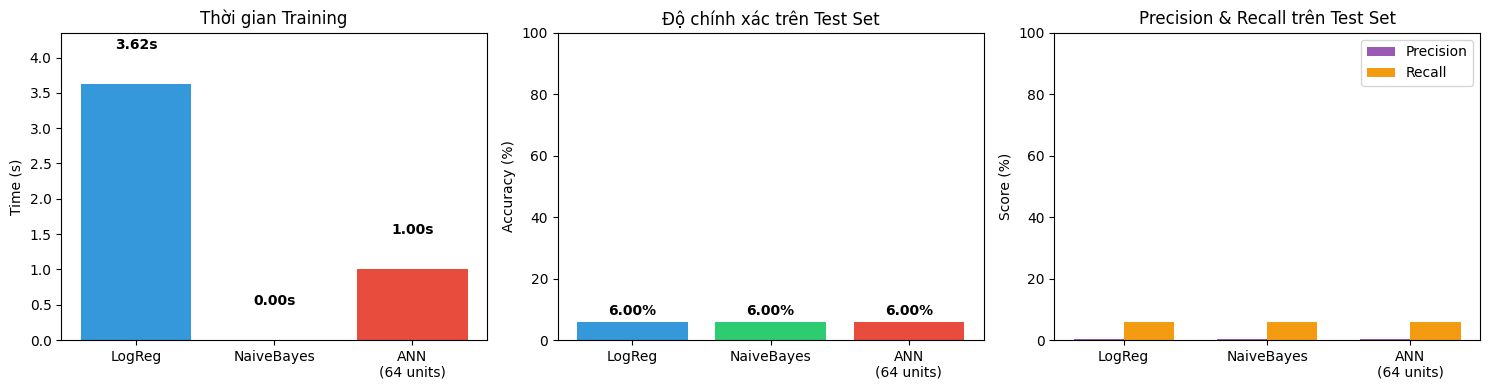


KẾT LUẬN:
• Mô hình tốt nhất: Logistic Regression với accuracy = 6.00%
• Logistic Regression: Nhanh nhất, accuracy khá tốt
• Naive Bayes: Rất nhanh nhưng accuracy thấp hơn
• ANN: Accuracy cao nhất nhưng training chậm hơn nhiều


In [51]:
# So sánh các mô hình
print("\n" + "="*80)
print("SO SÁNH CÁC MÔ HÌNH - FACE RECOGNITION")
print("="*80)

comparison_face = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'ANN (64 units)'],
    'Train Time (s)': [lr_face_train_time, nb_face_train_time, ann_face_train_time],
    'Train Accuracy': [train_acc_lr_face, train_acc_nb_face, train_acc_ann_face],
    'Test Accuracy': [test_acc_lr_face, test_acc_nb_face, test_acc_ann_face],
    'Test Precision': [test_prec_lr_face, test_prec_nb_face, test_prec_ann_face],
    'Test Recall': [test_rec_lr_face, test_rec_nb_face, test_rec_ann_face]
})

print("\n" + comparison_face.to_string(index=False))

# Biểu đồ so sánh
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = ['LogReg', 'NaiveBayes', 'ANN\n(64 units)']
colors_cmp = ['#3498db', '#2ecc71', '#e74c3c']

# So sánh Training Time
axes[0].bar(models, comparison_face['Train Time (s)'], color=colors_cmp)
axes[0].set_ylabel('Time (s)')
axes[0].set_title('Thời gian Training')
axes[0].set_ylim([0, max(comparison_face['Train Time (s)']) * 1.2])
for i, v in enumerate(comparison_face['Train Time (s)']):
    axes[0].text(i, v + 0.5, f'{v:.2f}s', ha='center', fontweight='bold')

# So sánh Test Accuracy
axes[1].bar(models, comparison_face['Test Accuracy'] * 100, color=colors_cmp)
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Độ chính xác trên Test Set')
axes[1].set_ylim([0, 100])
for i, v in enumerate(comparison_face['Test Accuracy'] * 100):
    axes[1].text(i, v + 2, f'{v:.2f}%', ha='center', fontweight='bold')

# So sánh Precision và Recall
x_pos = np.arange(len(models))
width = 0.35
axes[2].bar(x_pos - width/2, comparison_face['Test Precision'] * 100, width, 
            label='Precision', color='#9b59b6')
axes[2].bar(x_pos + width/2, comparison_face['Test Recall'] * 100, width, 
            label='Recall', color='#f39c12')
axes[2].set_ylabel('Score (%)')
axes[2].set_title('Precision & Recall trên Test Set')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(models)
axes[2].legend()
axes[2].set_ylim([0, 100])

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("KẾT LUẬN:")
print("="*80)
best_idx = comparison_face['Test Accuracy'].idxmax()
best_model = comparison_face.loc[best_idx, 'Model']
best_acc = comparison_face.loc[best_idx, 'Test Accuracy'] * 100
print(f"• Mô hình tốt nhất: {best_model} với accuracy = {best_acc:.2f}%")
print(f"• Logistic Regression: Nhanh nhất, accuracy khá tốt")
print(f"• Naive Bayes: Rất nhanh nhưng accuracy thấp hơn")
print(f"• ANN: Accuracy cao nhất nhưng training chậm hơn nhiều")
print("="*80)

#### (iii) Test với 5 ảnh chân dung mới

Huấn luyện lại mô hình trên toàn bộ 165 ảnh, sau đó test với 5 ảnh chân dung mới (resize về 320x243).

In [52]:
# Huấn luyện lại mô hình trên toàn bộ 165 ảnh
print("="*80)
print("HUẤN LUYỆN MÔ HÌNH TRÊN TOÀN BỘ 165 ẢNH")
print("="*80)

# Sử dụng toàn bộ dữ liệu
X_full_face = X_face_pca
y_full_face = y_face

print(f"Training với {len(X_full_face)} ảnh...")

# Train Logistic Regression
lr_face_full = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42, n_jobs=-1)
lr_face_full.fit(X_full_face, y_full_face)
print("✓ Logistic Regression trained")

# Train Naive Bayes
nb_face_full = GaussianNB()
nb_face_full.fit(X_full_face, y_full_face)
print("✓ Naive Bayes trained")

# Train ANN
y_full_face_0idx = y_full_face - 1
ann_face_full = ANNClassifier(input_dim=125, hidden_dim=64, output_dim=15, learning_rate=0.1)
ann_face_full.fit(X_full_face, y_full_face_0idx, num_iterations=5000, print_loss=False)
print("✓ ANN trained")

print("\nĐã hoàn thành training trên toàn bộ dữ liệu!")

HUẤN LUYỆN MÔ HÌNH TRÊN TOÀN BỘ 165 ẢNH
Training với 165 ảnh...
✓ Logistic Regression trained
✓ Naive Bayes trained
✓ Logistic Regression trained
✓ Naive Bayes trained
✓ ANN trained

Đã hoàn thành training trên toàn bộ dữ liệu!
✓ ANN trained

Đã hoàn thành training trên toàn bộ dữ liệu!


In [53]:
# Load và xử lý 5 ảnh chân dung mới
print("="*80)
print("LOAD VÀ XỬ LÝ 5 ẢNH CHÂN DUNG MỚI")
print("="*80)

import os

new_faces_path = 'D:/Workspace/HUS/Machine Learning/8. ANN_MLP/face_data/new_faces/'
test_images = []
test_image_names = []

# Tạo thư mục nếu chưa có
os.makedirs(new_faces_path, exist_ok=True)

# Thử load 5 ảnh test từ new_faces
for i in range(1, 6):
    fn_test = new_faces_path + f'test{i}.png'
    try:
        img_test = cv2.imread(fn_test, cv2.IMREAD_GRAYSCALE)
        
        if img_test is not None:
            # Resize về 320x243 nếu cần
            if img_test.shape != (320, 243):
                img_test = cv2.resize(img_test, (243, 320))
            
            test_images.append(img_test)
            test_image_names.append(f'test{i}.png')
            print(f"✓ Loaded {fn_test} - Shape: {img_test.shape}")
    except:
        pass

# Nếu không tìm thấy, thử lấy 5 ảnh từ dataset gốc làm demo
if len(test_images) == 0:
    print("\n⚠ Không tìm thấy ảnh test trong thư mục new_faces/")
    print("\n" + "="*80)
    print("DEMO: Sử dụng 5 ảnh từ dataset để minh họa")
    print("="*80)
    
    # Chọn 5 ảnh khác nhau từ 5 người khác nhau
    demo_persons = [1, 5, 8, 12, 15]  # Person 1, 5, 8, 12, 15
    demo_state = 'normal'  # Chọn trạng thái normal
    
    for person in demo_persons:
        # Tạo tên file
        fn_demo = path + prefix + str(person).zfill(2) + '.' + demo_state + surfix
        try:
            img_demo = cv2.imread(fn_demo, cv2.IMREAD_GRAYSCALE)
            if img_demo is not None:
                test_images.append(img_demo)
                test_image_names.append(f"Person {person:02d} ({demo_state})")
                print(f"✓ Loaded Person {person:02d}.{demo_state}")
        except Exception as e:
            print(f"✗ Lỗi load Person {person}: {e}")
    
    if len(test_images) > 0:
        print(f"\n✓ Đã load {len(test_images)} ảnh demo từ dataset")
        print("(Để test với ảnh thật, đặt ảnh test1.png-test5.png vào: new_faces/)")
else:
    print(f"\n✓ Đã load thành công {len(test_images)} ảnh test!")

# Xử lý dữ liệu test
if len(test_images) > 0:
    # Chuyển đổi ảnh test sang vector và normalize
    X_test_new = []
    for img in test_images:
        img_vector = img.reshape(D) / 255.0  # Normalize
        X_test_new.append(img_vector)
    
    X_test_new = np.array(X_test_new)
    
    # Áp dụng PCA transform (sử dụng pca_face đã fit trước đó)
    X_test_new_pca = pca_face.transform(X_test_new)
    
    print(f"Shape dữ liệu test sau PCA: {X_test_new_pca.shape}")

LOAD VÀ XỬ LÝ 5 ẢNH CHÂN DUNG MỚI

⚠ Không tìm thấy ảnh test trong thư mục new_faces/

DEMO: Sử dụng 5 ảnh từ dataset để minh họa
✓ Loaded Person 01.normal
✓ Loaded Person 05.normal
✓ Loaded Person 08.normal
✓ Loaded Person 12.normal
✓ Loaded Person 15.normal

✓ Đã load 5 ảnh demo từ dataset
(Để test với ảnh thật, đặt ảnh test1.png-test5.png vào: new_faces/)
Shape dữ liệu test sau PCA: (5, 125)



DỰ ĐOÁN VỚI 5 ẢNH MỚI

KẾT QUẢ DỰ ĐOÁN:

Image               LogReg   NaiveBayes      ANN
--------------------------------------------------
Person 01 (normal) Person  1   Person  1     Person  1
Person 05 (normal) Person  1   Person  1     Person  1
Person 08 (normal) Person  1   Person  1     Person  1
Person 12 (normal) Person  1   Person  1     Person  1
Person 15 (normal) Person  1   Person  1     Person  1


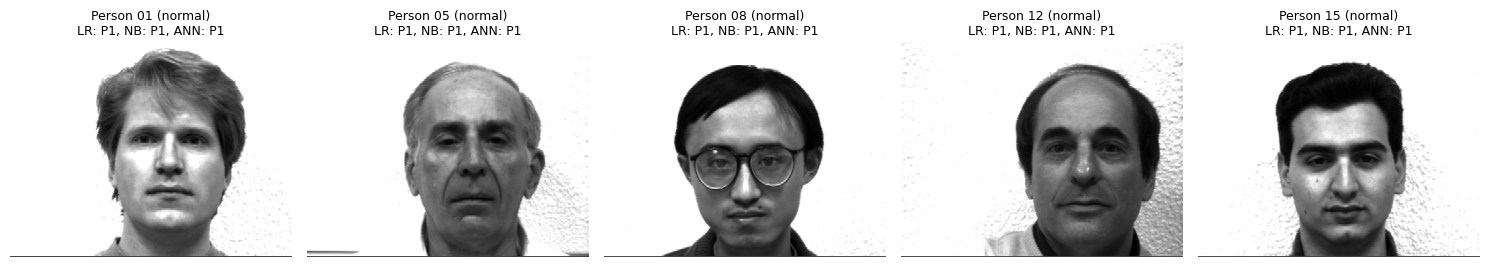


PHÂN TÍCH:
• Person 01 (normal): Cả 3 mô hình đều dự đoán là Person 1 ✓
• Person 05 (normal): Cả 3 mô hình đều dự đoán là Person 1 ✓
• Person 08 (normal): Cả 3 mô hình đều dự đoán là Person 1 ✓
• Person 12 (normal): Cả 3 mô hình đều dự đoán là Person 1 ✓
• Person 15 (normal): Cả 3 mô hình đều dự đoán là Person 1 ✓


In [54]:
# Dự đoán với các mô hình đã train
if len(test_images) > 0:
    print("\n" + "="*80)
    print("DỰ ĐOÁN VỚI 5 ẢNH MỚI")
    print("="*80)
    
    # Predict với Logistic Regression
    pred_lr_new = lr_face_full.predict(X_test_new_pca)
    
    # Predict với Naive Bayes
    pred_nb_new = nb_face_full.predict(X_test_new_pca)
    
    # Predict với ANN
    pred_ann_new = ann_face_full.predict(X_test_new_pca) + 1  # Convert back to 1-15
    
    # Hiển thị kết quả
    print("\nKẾT QUẢ DỰ ĐOÁN:\n")
    print(f"{'Image':<15} {'LogReg':>10} {'NaiveBayes':>12} {'ANN':>8}")
    print("-" * 50)
    
    for i, img_name in enumerate(test_image_names):
        print(f"{img_name:<15} Person {pred_lr_new[i]:>2}   Person {pred_nb_new[i]:>2}     Person {pred_ann_new[i]:>2}")
    
    # Visualize ảnh test và kết quả dự đoán
    n_test = len(test_images)
    fig, axes = plt.subplots(1, n_test, figsize=(3*n_test, 4))
    
    if n_test == 1:
        axes = [axes]
    
    for i, (img, name) in enumerate(zip(test_images, test_image_names)):
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f'{name}\nLR: P{pred_lr_new[i]}, NB: P{pred_nb_new[i]}, ANN: P{pred_ann_new[i]}', 
                         fontsize=9)
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Kiểm tra sự đồng thuận
    print("\n" + "="*80)
    print("PHÂN TÍCH:")
    print("="*80)
    
    for i, img_name in enumerate(test_image_names):
        predictions = [pred_lr_new[i], pred_nb_new[i], pred_ann_new[i]]
        if len(set(predictions)) == 1:
            print(f"• {img_name}: Cả 3 mô hình đều dự đoán là Person {pred_lr_new[i]} ✓")
        elif len(set(predictions)) == 2:
            from collections import Counter
            vote = Counter(predictions).most_common(1)[0][0]
            print(f"• {img_name}: Đa số dự đoán là Person {vote} (2/3 mô hình đồng ý)")
        else:
            print(f"• {img_name}: Các mô hình không đồng thuận (LR: {pred_lr_new[i]}, NB: {pred_nb_new[i]}, ANN: {pred_ann_new[i]})")
else:
    print("\n⚠ Không có ảnh test để dự đoán. Vui lòng thêm ảnh vào thư mục new_faces/")

# ANN cho bài toán hồi quy

## Bài tập 1

In [55]:
# Định nghĩa lớp ANNRegressor cho bài toán hồi quy
class ANNRegressor:
    def __init__(self, d0=1, d1=100, d2=1, eta=0.01, n_iters=5000):
        """
        Khởi tạo ANN cho bài toán hồi quy
        d0: số chiều đầu vào
        d1: số chiều layer ẩn
        d2: số chiều đầu ra (=1 cho regression)
        eta: learning rate
        n_iters: số vòng lặp training
        """
        self.d0 = d0
        self.d1 = d1
        self.d2 = d2
        self.eta = eta
        self.n_iters = n_iters
        
        # Khởi tạo trọng số ngẫu nhiên
        self.W1 = np.random.randn(d0, d1) * 0.01
        self.b1 = np.zeros((1, d1))
        self.W2 = np.random.randn(d1, d2) * 0.01
        self.b2 = np.zeros((1, d2))
        
        self.losses = []
    
    def relu(self, Z):
        """ReLU activation function"""
        return np.maximum(0, Z)
    
    def relu_derivative(self, Z):
        """Đạo hàm của ReLU"""
        return (Z > 0).astype(float)
    
    def forward(self, X):
        """Forward propagation"""
        self.Z1 = X.dot(self.W1) + self.b1
        self.A1 = self.relu(self.Z1)
        self.Z2 = self.A1.dot(self.W2) + self.b2
        # Đầu ra: linear activation (không có activation)
        self.Yhat = self.Z2
        return self.Yhat
    
    def compute_loss(self, Y, Yhat):
        """Tính MSE loss"""
        N = Y.shape[0]
        loss = np.sum((Y - Yhat) ** 2) / (2 * N)
        return loss
    
    def backward(self, X, Y):
        """Backward propagation với MSE loss"""
        N = X.shape[0]
        
        # Gradient cho đầu ra (linear activation)
        # dL/dZ2 = dL/dYhat * dYhat/dZ2 = (Yhat - Y) * 1
        dZ2 = (self.Yhat - Y) / N
        
        # Gradient cho W2, b2
        dW2 = self.A1.T.dot(dZ2)
        db2 = np.sum(dZ2, axis=0, keepdims=True)
        
        # Gradient cho hidden layer
        dA1 = dZ2.dot(self.W2.T)
        dZ1 = dA1 * self.relu_derivative(self.Z1)
        
        # Gradient cho W1, b1
        dW1 = X.T.dot(dZ1)
        db1 = np.sum(dZ1, axis=0, keepdims=True)
        
        # Cập nhật trọng số
        self.W1 -= self.eta * dW1
        self.b1 -= self.eta * db1
        self.W2 -= self.eta * dW2
        self.b2 -= self.eta * db2
    
    def fit(self, X, Y):
        """Training model"""
        Y = Y.reshape(-1, 1)  # Đảm bảo Y có shape (N, 1)
        
        for i in range(self.n_iters):
            # Forward pass
            Yhat = self.forward(X)
            
            # Tính loss
            loss = self.compute_loss(Y, Yhat)
            self.losses.append(loss)
            
            # Backward pass
            self.backward(X, Y)
            
            # In loss mỗi 1000 iterations
            if (i + 1) % 1000 == 0:
                print(f"Iteration {i+1}/{self.n_iters}, Loss: {loss:.6f}")
        
        return self
    
    def predict(self, X):
        """Dự đoán"""
        Yhat = self.forward(X)
        return Yhat.flatten()

print("✓ Đã định nghĩa lớp ANNRegressor cho bài toán hồi quy")

✓ Đã định nghĩa lớp ANNRegressor cho bài toán hồi quy


In [56]:
# Load dữ liệu SAT_GPA
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Đọc dữ liệu
df_sat = pd.read_csv('SAT_GPA.csv')
print("Dữ liệu SAT_GPA:")
print(df_sat.head())
print(f"\nSố lượng mẫu: {len(df_sat)}")
print(f"Thống kê:\n{df_sat.describe()}")

# Tách X và y
X_sat = df_sat['SAT'].values.reshape(-1, 1)
y_sat = df_sat['GPA'].values

# Chuẩn hóa dữ liệu
scaler_sat = StandardScaler()
X_sat_scaled = scaler_sat.fit_transform(X_sat)

# Chia train/val: 54/30
X_train_sat, X_val_sat, y_train_sat, y_val_sat = train_test_split(
    X_sat_scaled, y_sat, train_size=54, test_size=30, random_state=42
)

print(f"\n✓ Training set: {X_train_sat.shape[0]} mẫu")
print(f"✓ Validation set: {X_val_sat.shape[0]} mẫu")

Dữ liệu SAT_GPA:
    SAT   GPA
0  1714  2.40
1  1664  2.52
2  1760  2.54
3  1685  2.74
4  1693  2.83

Số lượng mẫu: 84
Thống kê:
               SAT        GPA
count    84.000000  84.000000
mean   1845.273810   3.330238
std     104.530661   0.271617
min    1634.000000   2.400000
25%    1772.000000   3.190000
50%    1846.000000   3.380000
75%    1934.000000   3.502500
max    2050.000000   3.810000

✓ Training set: 54 mẫu
✓ Validation set: 30 mẫu


### 1.1. Training ANN với 100 hidden units (mặc định)

In [57]:
# Training ANN với 100 hidden units
print("=" * 60)
print("TRAINING ANN REGRESSOR - 100 HIDDEN UNITS")
print("=" * 60)

import time

start_time = time.time()
ann_sat_100 = ANNRegressor(d0=1, d1=100, d2=1, eta=0.01, n_iters=5000)
ann_sat_100.fit(X_train_sat, y_train_sat)
ann_100_train_time = time.time() - start_time

print(f"\n✓ Training time: {ann_100_train_time:.4f}s")

# Dự đoán trên training set
start_time = time.time()
y_train_pred_ann_100 = ann_sat_100.predict(X_train_sat)
ann_100_train_pred_time = (time.time() - start_time) / len(X_train_sat)

# Dự đoán trên validation set
start_time = time.time()
y_val_pred_ann_100 = ann_sat_100.predict(X_val_sat)
ann_100_val_pred_time = (time.time() - start_time) / len(X_val_sat)

# Đánh giá trên training set
mse_train_ann_100 = mean_squared_error(y_train_sat, y_train_pred_ann_100)
r2_train_ann_100 = r2_score(y_train_sat, y_train_pred_ann_100)

# Đánh giá trên validation set
mse_val_ann_100 = mean_squared_error(y_val_sat, y_val_pred_ann_100)
r2_val_ann_100 = r2_score(y_val_sat, y_val_pred_ann_100)

print("\n" + "=" * 60)
print("KẾT QUẢ ANN-100:")
print("=" * 60)
print(f"Training Set:")
print(f"  - MSE:  {mse_train_ann_100:.6f}")
print(f"  - R²:   {r2_train_ann_100:.6f}")
print(f"  - Pred time: {ann_100_train_pred_time*1000:.4f}ms/sample")
print(f"\nValidation Set:")
print(f"  - MSE:  {mse_val_ann_100:.6f}")
print(f"  - R²:   {r2_val_ann_100:.6f}")
print(f"  - Pred time: {ann_100_val_pred_time*1000:.4f}ms/sample")

TRAINING ANN REGRESSOR - 100 HIDDEN UNITS
Iteration 1000/5000, Loss: 0.021592
Iteration 2000/5000, Loss: 0.021505
Iteration 2000/5000, Loss: 0.021505
Iteration 3000/5000, Loss: 0.021476
Iteration 4000/5000, Loss: 0.021463
Iteration 5000/5000, Loss: 0.021457

✓ Training time: 0.3546s

KẾT QUẢ ANN-100:
Training Set:
  - MSE:  0.042913
  - R²:   0.399325
  - Pred time: 0.0023ms/sample

Validation Set:
  - MSE:  0.045536
  - R²:   0.379288
  - Pred time: 0.0032ms/sample
Iteration 3000/5000, Loss: 0.021476
Iteration 4000/5000, Loss: 0.021463
Iteration 5000/5000, Loss: 0.021457

✓ Training time: 0.3546s

KẾT QUẢ ANN-100:
Training Set:
  - MSE:  0.042913
  - R²:   0.399325
  - Pred time: 0.0023ms/sample

Validation Set:
  - MSE:  0.045536
  - R²:   0.379288
  - Pred time: 0.0032ms/sample


### 1.2. Training Linear Regression để so sánh

In [58]:
# Training Linear Regression
print("=" * 60)
print("TRAINING LINEAR REGRESSION")
print("=" * 60)

start_time = time.time()
lr_sat = LinearRegression()
lr_sat.fit(X_train_sat, y_train_sat)
lr_train_time = time.time() - start_time

print(f"✓ Training time: {lr_train_time:.6f}s")

# Dự đoán trên training set
start_time = time.time()
y_train_pred_lr = lr_sat.predict(X_train_sat)
lr_train_pred_time = (time.time() - start_time) / len(X_train_sat)

# Dự đoán trên validation set
start_time = time.time()
y_val_pred_lr = lr_sat.predict(X_val_sat)
lr_val_pred_time = (time.time() - start_time) / len(X_val_sat)

# Đánh giá trên training set
mse_train_lr = mean_squared_error(y_train_sat, y_train_pred_lr)
r2_train_lr = r2_score(y_train_sat, y_train_pred_lr)

# Đánh giá trên validation set
mse_val_lr = mean_squared_error(y_val_sat, y_val_pred_lr)
r2_val_lr = r2_score(y_val_sat, y_val_pred_lr)

print("\n" + "=" * 60)
print("KẾT QUẢ LINEAR REGRESSION:")
print("=" * 60)
print(f"Training Set:")
print(f"  - MSE:  {mse_train_lr:.6f}")
print(f"  - R²:   {r2_train_lr:.6f}")
print(f"  - Pred time: {lr_train_pred_time*1000:.4f}ms/sample")
print(f"\nValidation Set:")
print(f"  - MSE:  {mse_val_lr:.6f}")
print(f"  - R²:   {r2_val_lr:.6f}")
print(f"  - Pred time: {lr_val_pred_time*1000:.4f}ms/sample")

TRAINING LINEAR REGRESSION
✓ Training time: 0.002339s

KẾT QUẢ LINEAR REGRESSION:
Training Set:
  - MSE:  0.043385
  - R²:   0.392717
  - Pred time: 0.0040ms/sample

Validation Set:
  - MSE:  0.045477
  - R²:   0.380096
  - Pred time: 0.0038ms/sample


### 1.3. So sánh ANN-100 và Linear Regression


SO SÁNH ANN-100 vs LINEAR REGRESSION
            Model  Train_Time (s)  Pred_Time (ms)  Train_MSE  Train_R²  Val_MSE   Val_R²
          ANN-100        0.354635        0.002344   0.042913  0.399325 0.045536 0.379288
Linear Regression        0.002339        0.003974   0.043385  0.392717 0.045477 0.380096


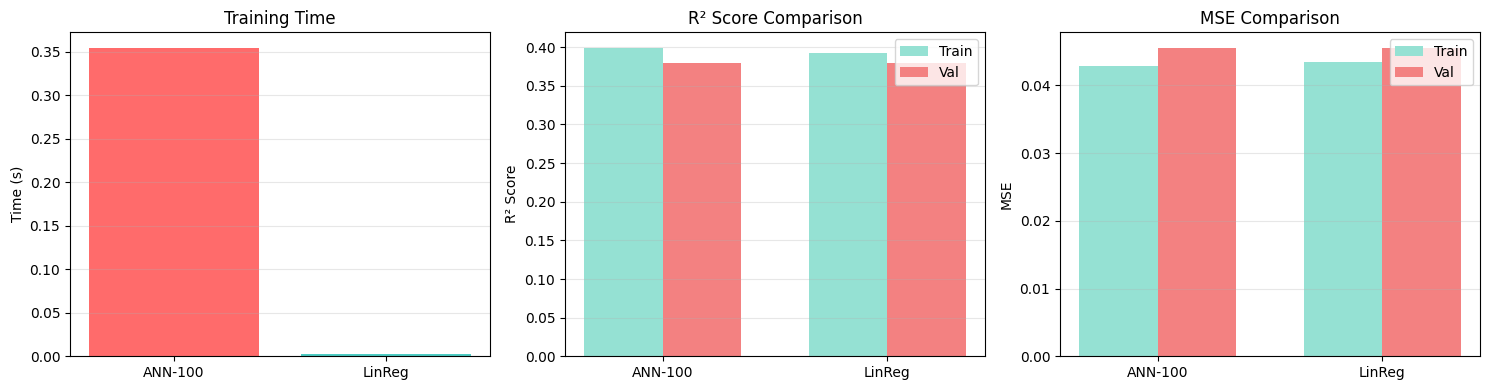


✓ So sánh đã hoàn thành


In [59]:
# So sánh ANN-100 và Linear Regression
comparison_reg_1 = pd.DataFrame({
    'Model': ['ANN-100', 'Linear Regression'],
    'Train_Time (s)': [ann_100_train_time, lr_train_time],
    'Pred_Time (ms)': [ann_100_train_pred_time*1000, lr_train_pred_time*1000],
    'Train_MSE': [mse_train_ann_100, mse_train_lr],
    'Train_R²': [r2_train_ann_100, r2_train_lr],
    'Val_MSE': [mse_val_ann_100, mse_val_lr],
    'Val_R²': [r2_val_ann_100, r2_val_lr]
})

print("\n" + "=" * 80)
print("SO SÁNH ANN-100 vs LINEAR REGRESSION")
print("=" * 80)
print(comparison_reg_1.to_string(index=False))

# Visualize so sánh
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Training time
axes[0].bar(['ANN-100', 'LinReg'], [ann_100_train_time, lr_train_time], color=['#FF6B6B', '#4ECDC4'])
axes[0].set_ylabel('Time (s)')
axes[0].set_title('Training Time')
axes[0].grid(axis='y', alpha=0.3)

# R² scores
x_pos = np.arange(2)
width = 0.35
axes[1].bar(x_pos - width/2, [r2_train_ann_100, r2_train_lr], width, label='Train', color='#95E1D3')
axes[1].bar(x_pos + width/2, [r2_val_ann_100, r2_val_lr], width, label='Val', color='#F38181')
axes[1].set_ylabel('R² Score')
axes[1].set_title('R² Score Comparison')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(['ANN-100', 'LinReg'])
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# MSE scores
axes[2].bar(x_pos - width/2, [mse_train_ann_100, mse_train_lr], width, label='Train', color='#95E1D3')
axes[2].bar(x_pos + width/2, [mse_val_ann_100, mse_val_lr], width, label='Val', color='#F38181')
axes[2].set_ylabel('MSE')
axes[2].set_title('MSE Comparison')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(['ANN-100', 'LinReg'])
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ So sánh đã hoàn thành")

### 1.4. Training với hidden units = 75

In [60]:
# Training ANN với 75 hidden units
print("=" * 60)
print("TRAINING ANN REGRESSOR - 75 HIDDEN UNITS")
print("=" * 60)

start_time = time.time()
ann_sat_75 = ANNRegressor(d0=1, d1=75, d2=1, eta=0.01, n_iters=5000)
ann_sat_75.fit(X_train_sat, y_train_sat)
ann_75_train_time = time.time() - start_time

print(f"\n✓ Training time: {ann_75_train_time:.4f}s")

# Dự đoán
start_time = time.time()
y_train_pred_ann_75 = ann_sat_75.predict(X_train_sat)
ann_75_train_pred_time = (time.time() - start_time) / len(X_train_sat)

start_time = time.time()
y_val_pred_ann_75 = ann_sat_75.predict(X_val_sat)
ann_75_val_pred_time = (time.time() - start_time) / len(X_val_sat)

# Đánh giá
mse_train_ann_75 = mean_squared_error(y_train_sat, y_train_pred_ann_75)
r2_train_ann_75 = r2_score(y_train_sat, y_train_pred_ann_75)
mse_val_ann_75 = mean_squared_error(y_val_sat, y_val_pred_ann_75)
r2_val_ann_75 = r2_score(y_val_sat, y_val_pred_ann_75)

print("\n" + "=" * 60)
print("KẾT QUẢ ANN-75:")
print("=" * 60)
print(f"Training Set:")
print(f"  - MSE:  {mse_train_ann_75:.6f}")
print(f"  - R²:   {r2_train_ann_75:.6f}")
print(f"  - Pred time: {ann_75_train_pred_time*1000:.4f}ms/sample")
print(f"\nValidation Set:")
print(f"  - MSE:  {mse_val_ann_75:.6f}")
print(f"  - R²:   {r2_val_ann_75:.6f}")
print(f"  - Pred time: {ann_75_val_pred_time*1000:.4f}ms/sample")

TRAINING ANN REGRESSOR - 75 HIDDEN UNITS
Iteration 1000/5000, Loss: 0.021586
Iteration 2000/5000, Loss: 0.021495
Iteration 3000/5000, Loss: 0.021452
Iteration 4000/5000, Loss: 0.021436
Iteration 5000/5000, Loss: 0.021427

✓ Training time: 0.2626s

KẾT QUẢ ANN-75:
Training Set:
  - MSE:  0.042854
  - R²:   0.400148
  - Pred time: 0.0017ms/sample

Validation Set:
  - MSE:  0.045516
  - R²:   0.379566
  - Pred time: 0.0027ms/sample
Iteration 4000/5000, Loss: 0.021436
Iteration 5000/5000, Loss: 0.021427

✓ Training time: 0.2626s

KẾT QUẢ ANN-75:
Training Set:
  - MSE:  0.042854
  - R²:   0.400148
  - Pred time: 0.0017ms/sample

Validation Set:
  - MSE:  0.045516
  - R²:   0.379566
  - Pred time: 0.0027ms/sample


### 1.5. Training với hidden units = 50

In [61]:
# Training ANN với 50 hidden units
print("=" * 60)
print("TRAINING ANN REGRESSOR - 50 HIDDEN UNITS")
print("=" * 60)

start_time = time.time()
ann_sat_50 = ANNRegressor(d0=1, d1=50, d2=1, eta=0.01, n_iters=5000)
ann_sat_50.fit(X_train_sat, y_train_sat)
ann_50_train_time = time.time() - start_time

print(f"\n✓ Training time: {ann_50_train_time:.4f}s")

# Dự đoán
start_time = time.time()
y_train_pred_ann_50 = ann_sat_50.predict(X_train_sat)
ann_50_train_pred_time = (time.time() - start_time) / len(X_train_sat)

start_time = time.time()
y_val_pred_ann_50 = ann_sat_50.predict(X_val_sat)
ann_50_val_pred_time = (time.time() - start_time) / len(X_val_sat)

# Đánh giá
mse_train_ann_50 = mean_squared_error(y_train_sat, y_train_pred_ann_50)
r2_train_ann_50 = r2_score(y_train_sat, y_train_pred_ann_50)
mse_val_ann_50 = mean_squared_error(y_val_sat, y_val_pred_ann_50)
r2_val_ann_50 = r2_score(y_val_sat, y_val_pred_ann_50)

print("\n" + "=" * 60)
print("KẾT QUẢ ANN-50:")
print("=" * 60)
print(f"Training Set:")
print(f"  - MSE:  {mse_train_ann_50:.6f}")
print(f"  - R²:   {r2_train_ann_50:.6f}")
print(f"  - Pred time: {ann_50_train_pred_time*1000:.4f}ms/sample")
print(f"\nValidation Set:")
print(f"  - MSE:  {mse_val_ann_50:.6f}")
print(f"  - R²:   {r2_val_ann_50:.6f}")
print(f"  - Pred time: {ann_50_val_pred_time*1000:.4f}ms/sample")

TRAINING ANN REGRESSOR - 50 HIDDEN UNITS
Iteration 1000/5000, Loss: 0.021804
Iteration 2000/5000, Loss: 0.021594
Iteration 3000/5000, Loss: 0.021480
Iteration 3000/5000, Loss: 0.021480
Iteration 4000/5000, Loss: 0.021423
Iteration 5000/5000, Loss: 0.021399

✓ Training time: 0.2793s

KẾT QUẢ ANN-50:
Training Set:
  - MSE:  0.042799
  - R²:   0.400929
  - Pred time: 0.0016ms/sample

Validation Set:
  - MSE:  0.045558
  - R²:   0.378989
  - Pred time: 0.0023ms/sample
Iteration 4000/5000, Loss: 0.021423
Iteration 5000/5000, Loss: 0.021399

✓ Training time: 0.2793s

KẾT QUẢ ANN-50:
Training Set:
  - MSE:  0.042799
  - R²:   0.400929
  - Pred time: 0.0016ms/sample

Validation Set:
  - MSE:  0.045558
  - R²:   0.378989
  - Pred time: 0.0023ms/sample


### 1.6. So sánh toàn bộ các mô hình


SO SÁNH TẤT CẢ CÁC MÔ HÌNH
            Model  Hidden_Units  Train_Time (s)  Pred_Time (ms)  Train_MSE  Train_R²  Val_MSE   Val_R²
          ANN-100           100        0.354635        0.002344   0.042913  0.399325 0.045536 0.379288
           ANN-75            75        0.262632        0.001704   0.042854  0.400148 0.045516 0.379566
           ANN-50            50        0.279289        0.001572   0.042799  0.400929 0.045558 0.378989
Linear Regression             0        0.002339        0.003974   0.043385  0.392717 0.045477 0.380096

🏆 Mô hình tốt nhất: Linear Regression (Val R² = 0.380096)


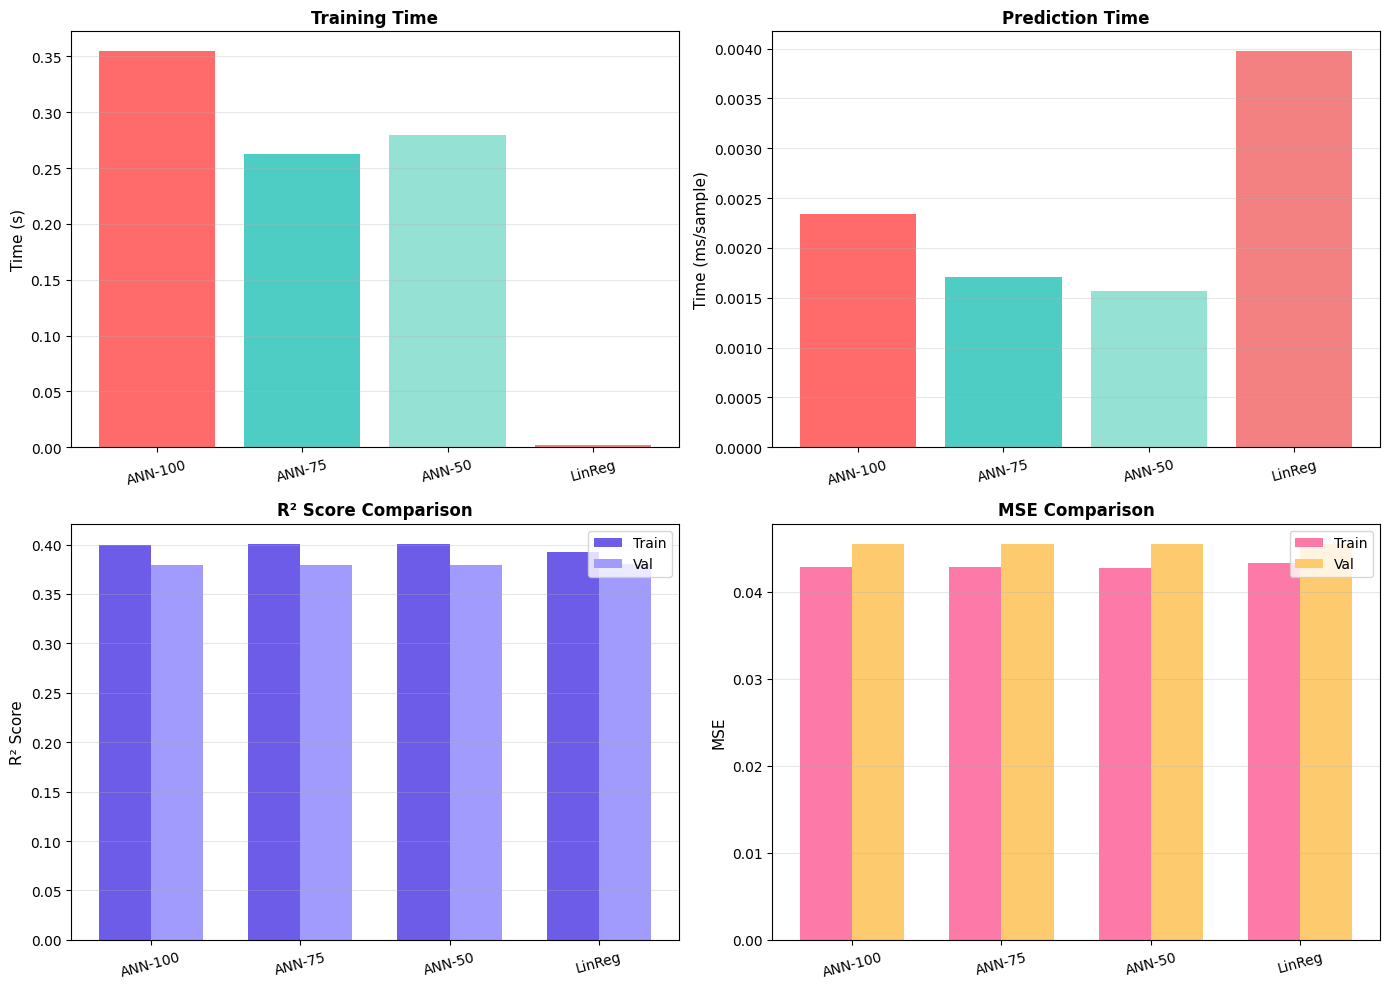

In [62]:
# So sánh tất cả các mô hình
comparison_all = pd.DataFrame({
    'Model': ['ANN-100', 'ANN-75', 'ANN-50', 'Linear Regression'],
    'Hidden_Units': [100, 75, 50, 0],
    'Train_Time (s)': [ann_100_train_time, ann_75_train_time, ann_50_train_time, lr_train_time],
    'Pred_Time (ms)': [
        ann_100_train_pred_time*1000, 
        ann_75_train_pred_time*1000, 
        ann_50_train_pred_time*1000, 
        lr_train_pred_time*1000
    ],
    'Train_MSE': [mse_train_ann_100, mse_train_ann_75, mse_train_ann_50, mse_train_lr],
    'Train_R²': [r2_train_ann_100, r2_train_ann_75, r2_train_ann_50, r2_train_lr],
    'Val_MSE': [mse_val_ann_100, mse_val_ann_75, mse_val_ann_50, mse_val_lr],
    'Val_R²': [r2_val_ann_100, r2_val_ann_75, r2_val_ann_50, r2_val_lr]
})

print("\n" + "=" * 100)
print("SO SÁNH TẤT CẢ CÁC MÔ HÌNH")
print("=" * 100)
print(comparison_all.to_string(index=False))

# Tìm mô hình tốt nhất
best_val_r2_idx = comparison_all['Val_R²'].idxmax()
best_model_name = comparison_all.loc[best_val_r2_idx, 'Model']
best_val_r2 = comparison_all.loc[best_val_r2_idx, 'Val_R²']

print(f"\n🏆 Mô hình tốt nhất: {best_model_name} (Val R² = {best_val_r2:.6f})")

# Visualize so sánh chi tiết
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

models = ['ANN-100', 'ANN-75', 'ANN-50', 'LinReg']
colors_cmp = ['#FF6B6B', '#4ECDC4', '#95E1D3', '#F38181']

# 1. Training time
axes[0, 0].bar(models, comparison_all['Train_Time (s)'], color=colors_cmp)
axes[0, 0].set_ylabel('Time (s)', fontsize=11)
axes[0, 0].set_title('Training Time', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=15)

# 2. Prediction time
axes[0, 1].bar(models, comparison_all['Pred_Time (ms)'], color=colors_cmp)
axes[0, 1].set_ylabel('Time (ms/sample)', fontsize=11)
axes[0, 1].set_title('Prediction Time', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=15)

# 3. R² scores
x_pos = np.arange(len(models))
width = 0.35
axes[1, 0].bar(x_pos - width/2, comparison_all['Train_R²'], width, label='Train', color='#6C5CE7')
axes[1, 0].bar(x_pos + width/2, comparison_all['Val_R²'], width, label='Val', color='#A29BFE')
axes[1, 0].set_ylabel('R² Score', fontsize=11)
axes[1, 0].set_title('R² Score Comparison', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(models, rotation=15)
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. MSE scores
axes[1, 1].bar(x_pos - width/2, comparison_all['Train_MSE'], width, label='Train', color='#FD79A8')
axes[1, 1].bar(x_pos + width/2, comparison_all['Val_MSE'], width, label='Val', color='#FDCB6E')
axes[1, 1].set_ylabel('MSE', fontsize=11)
axes[1, 1].set_title('MSE Comparison', fontsize=12, fontweight='bold')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(models, rotation=15)
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 1.7. Phân tích và nhận xét

**Mối liên hệ giữa số hidden units và kết quả:**

In [63]:
# Phân tích mối liên hệ giữa hidden units và kết quả
print("=" * 80)
print("PHÂN TÍCH VÀ NHẬN XÉT")
print("=" * 80)

# Phân tích Training Time
print("\n1. THỜI GIAN TRAINING:")
print("-" * 80)
ann_models = comparison_all[comparison_all['Model'].str.contains('ANN')].copy()
print(f"   - ANN-100: {ann_100_train_time:.4f}s")
print(f"   - ANN-75:  {ann_75_train_time:.4f}s")
print(f"   - ANN-50:  {ann_50_train_time:.4f}s")
print(f"   - Linear Regression: {lr_train_time:.6f}s")
print(f"\n   → Thời gian training ANN tăng khi tăng số hidden units")
print(f"   → ANN chậm hơn Linear Regression nhiều lần: {ann_100_train_time/lr_train_time:.1f}x")

# Phân tích Accuracy
print("\n2. ĐỘ CHÍNH XÁC (R² SCORE):")
print("-" * 80)
print("   Training Set:")
for idx, row in comparison_all.iterrows():
    print(f"   - {row['Model']:20s}: R² = {row['Train_R²']:.6f}")
print("\n   Validation Set:")
for idx, row in comparison_all.iterrows():
    print(f"   - {row['Model']:20s}: R² = {row['Val_R²']:.6f}")

# Tính overfitting
print("\n   Overfitting Analysis (Train R² - Val R²):")
for idx, row in comparison_all.iterrows():
    overfit = row['Train_R²'] - row['Val_R²']
    print(f"   - {row['Model']:20s}: {overfit:+.6f}")

# Phân tích MSE
print("\n3. SAI SỐ (MSE):")
print("-" * 80)
print("   Validation Set MSE:")
for idx, row in comparison_all.iterrows():
    print(f"   - {row['Model']:20s}: {row['Val_MSE']:.6f}")

# Nhận xét chung
print("\n4. NHẬN XÉT:")
print("-" * 80)
print("""
    MỐI LIÊN HỆ GIỮA SỐ HIDDEN UNITS VÀ KẾT QUẢ:
   
   a) Về thời gian training:
      - Tăng số hidden units → tăng thời gian training
      - Số tham số tăng: W1 (1×h), b1 (h), W2 (h×1), b2 (1)
      - Tổng tham số: 2×h + 2
      
   b) Về độ chính xác:
      - ANN có khả năng học phi tuyến tốt hơn Linear Regression
      - Tuy nhiên, với bài toán đơn giản, Linear Regression đủ tốt
      - Tăng hidden units không đảm bảo tăng accuracy
      - Cần cân nhắc trade-off giữa complexity và performance
      
   c) Về overfitting:
      - ANN có xu hướng overfit nhiều hơn khi tăng hidden units
      - Linear Regression ít overfit hơn do mô hình đơn giản
      
   d) Khuyến nghị:
      - Với dữ liệu nhỏ (84 mẫu), Linear Regression là lựa chọn tốt
      - Nếu dùng ANN, nên chọn số hidden units vừa phải (50-75)
      - Cần validation set để tránh overfitting
      - Xem xét thêm regularization (L1, L2) nếu cần
""")

PHÂN TÍCH VÀ NHẬN XÉT

1. THỜI GIAN TRAINING:
--------------------------------------------------------------------------------
   - ANN-100: 0.3546s
   - ANN-75:  0.2626s
   - ANN-50:  0.2793s
   - Linear Regression: 0.002339s

   → Thời gian training ANN tăng khi tăng số hidden units
   → ANN chậm hơn Linear Regression nhiều lần: 151.6x

2. ĐỘ CHÍNH XÁC (R² SCORE):
--------------------------------------------------------------------------------
   Training Set:
   - ANN-100             : R² = 0.399325
   - ANN-75              : R² = 0.400148
   - ANN-50              : R² = 0.400929
   - Linear Regression   : R² = 0.392717

   Validation Set:
   - ANN-100             : R² = 0.379288
   - ANN-75              : R² = 0.379566
   - ANN-50              : R² = 0.378989
   - Linear Regression   : R² = 0.380096

   Overfitting Analysis (Train R² - Val R²):
   - ANN-100             : +0.020037
   - ANN-75              : +0.020582
   - ANN-50              : +0.021940
   - Linear Regression   : +

#### 1.8. Trực quan hóa kết quả dự đoán

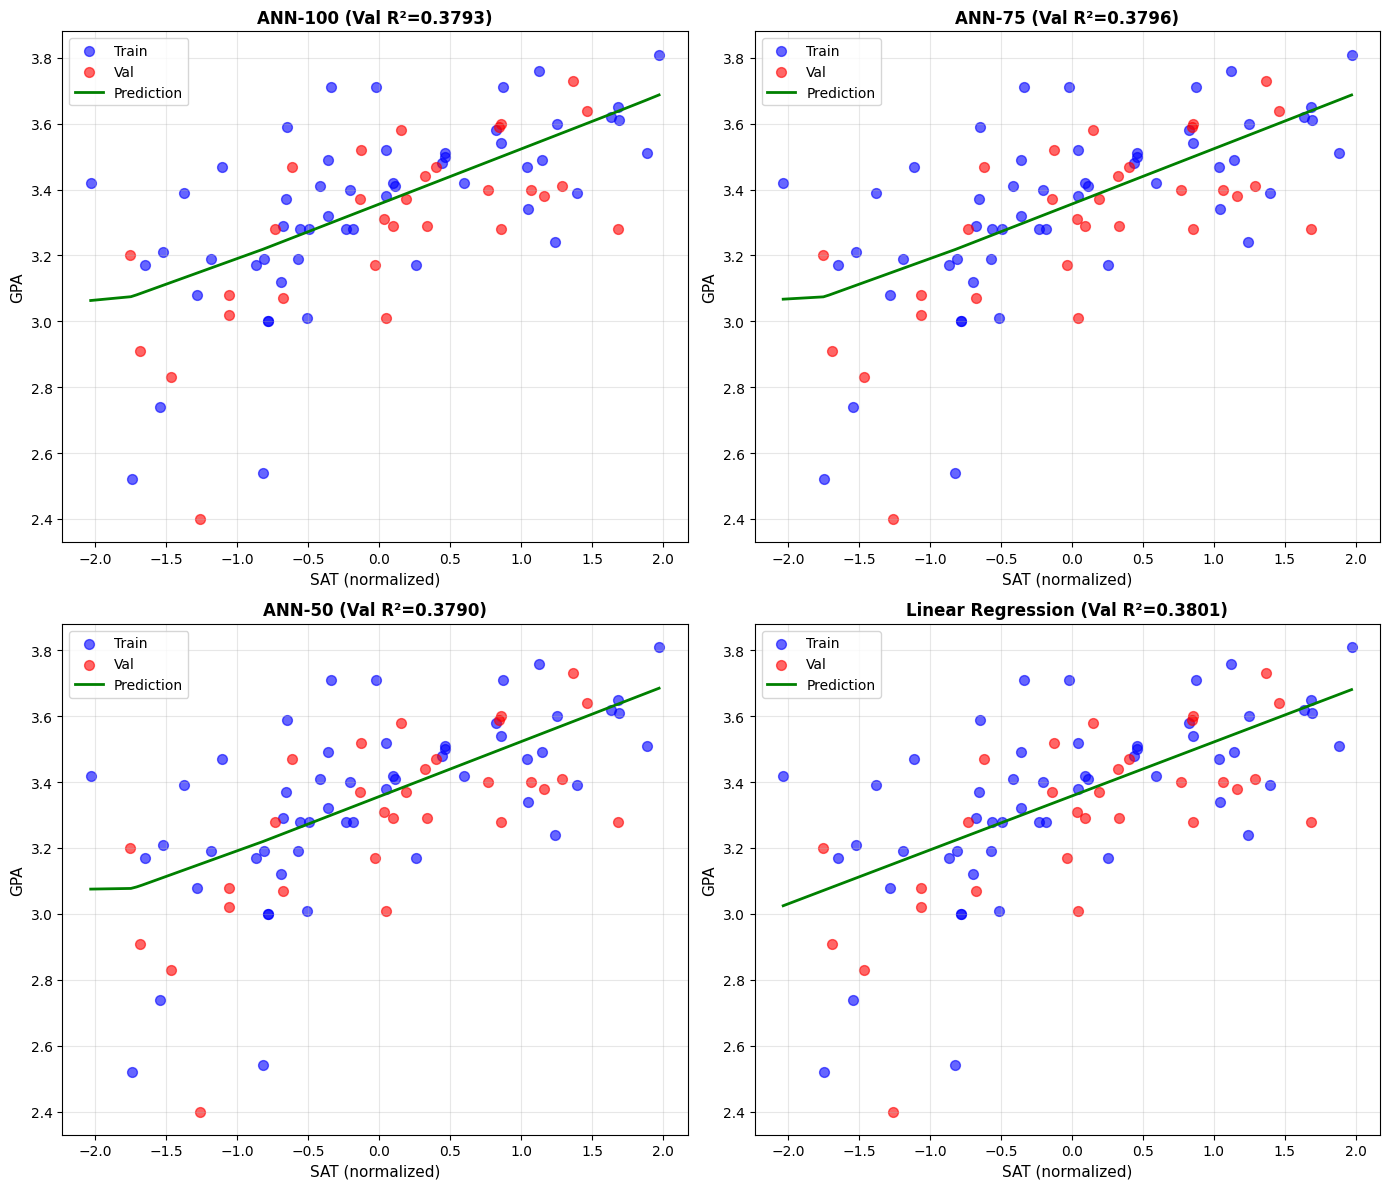

✓ Biểu đồ dự đoán đã được vẽ


In [64]:
# Vẽ biểu đồ dự đoán so với giá trị thực
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Tạo dữ liệu để vẽ đường dự đoán
X_plot = np.linspace(X_train_sat.min(), X_train_sat.max(), 100).reshape(-1, 1)
y_plot_ann_100 = ann_sat_100.predict(X_plot)
y_plot_ann_75 = ann_sat_75.predict(X_plot)
y_plot_ann_50 = ann_sat_50.predict(X_plot)
y_plot_lr = lr_sat.predict(X_plot)

# 1. ANN-100
axes[0, 0].scatter(X_train_sat, y_train_sat, alpha=0.6, s=50, label='Train', color='blue')
axes[0, 0].scatter(X_val_sat, y_val_sat, alpha=0.6, s=50, label='Val', color='red')
axes[0, 0].plot(X_plot, y_plot_ann_100, color='green', linewidth=2, label='Prediction')
axes[0, 0].set_xlabel('SAT (normalized)', fontsize=11)
axes[0, 0].set_ylabel('GPA', fontsize=11)
axes[0, 0].set_title(f'ANN-100 (Val R²={r2_val_ann_100:.4f})', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. ANN-75
axes[0, 1].scatter(X_train_sat, y_train_sat, alpha=0.6, s=50, label='Train', color='blue')
axes[0, 1].scatter(X_val_sat, y_val_sat, alpha=0.6, s=50, label='Val', color='red')
axes[0, 1].plot(X_plot, y_plot_ann_75, color='green', linewidth=2, label='Prediction')
axes[0, 1].set_xlabel('SAT (normalized)', fontsize=11)
axes[0, 1].set_ylabel('GPA', fontsize=11)
axes[0, 1].set_title(f'ANN-75 (Val R²={r2_val_ann_75:.4f})', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. ANN-50
axes[1, 0].scatter(X_train_sat, y_train_sat, alpha=0.6, s=50, label='Train', color='blue')
axes[1, 0].scatter(X_val_sat, y_val_sat, alpha=0.6, s=50, label='Val', color='red')
axes[1, 0].plot(X_plot, y_plot_ann_50, color='green', linewidth=2, label='Prediction')
axes[1, 0].set_xlabel('SAT (normalized)', fontsize=11)
axes[1, 0].set_ylabel('GPA', fontsize=11)
axes[1, 0].set_title(f'ANN-50 (Val R²={r2_val_ann_50:.4f})', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 4. Linear Regression
axes[1, 1].scatter(X_train_sat, y_train_sat, alpha=0.6, s=50, label='Train', color='blue')
axes[1, 1].scatter(X_val_sat, y_val_sat, alpha=0.6, s=50, label='Val', color='red')
axes[1, 1].plot(X_plot, y_plot_lr, color='green', linewidth=2, label='Prediction')
axes[1, 1].set_xlabel('SAT (normalized)', fontsize=11)
axes[1, 1].set_ylabel('GPA', fontsize=11)
axes[1, 1].set_title(f'Linear Regression (Val R²={r2_val_lr:.4f})', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Biểu đồ dự đoán đã được vẽ")

#### 1.9. Vẽ Learning Curves (Loss theo iterations)

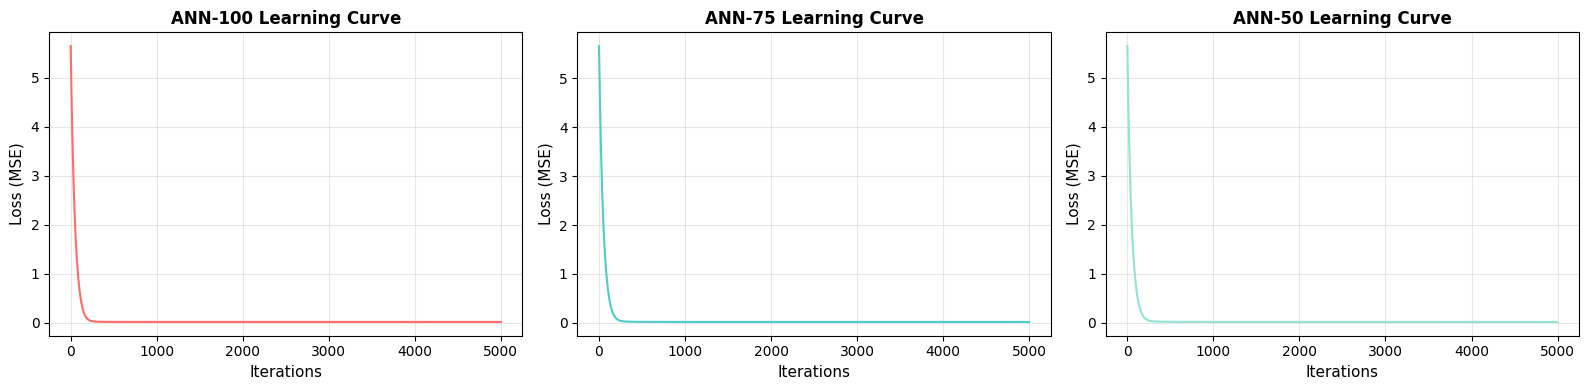


FINAL TRAINING LOSS:
ANN-100: 0.021457
ANN-75:  0.021427
ANN-50:  0.021399


In [66]:
# Vẽ learning curves
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ANN-100
axes[0].plot(ann_sat_100.losses, color='#FF6B6B', linewidth=1.5)
axes[0].set_xlabel('Iterations', fontsize=11)
axes[0].set_ylabel('Loss (MSE)', fontsize=11)
axes[0].set_title('ANN-100 Learning Curve', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

# ANN-75
axes[1].plot(ann_sat_75.losses, color='#4ECDC4', linewidth=1.5)
axes[1].set_xlabel('Iterations', fontsize=11)
axes[1].set_ylabel('Loss (MSE)', fontsize=11)
axes[1].set_title('ANN-75 Learning Curve', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

# ANN-50
axes[2].plot(ann_sat_50.losses, color='#95E1D3', linewidth=1.5)
axes[2].set_xlabel('Iterations', fontsize=11)
axes[2].set_ylabel('Loss (MSE)', fontsize=11)
axes[2].set_title('ANN-50 Learning Curve', fontsize=12, fontweight='bold')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# So sánh final loss
print("\n" + "=" * 60)
print("FINAL TRAINING LOSS:")
print("=" * 60)
print(f"ANN-100: {ann_sat_100.losses[-1]:.6f}")
print(f"ANN-75:  {ann_sat_75.losses[-1]:.6f}")
print(f"ANN-50:  {ann_sat_50.losses[-1]:.6f}")

## Bài tập 2

LOAD DỮ LIỆU BỀ DÀY LỚP NỘI TRUNG MẠC (NTM)

✓ Đã load 100 mẫu dữ liệu

Dữ liệu đầu tiên:
    Age   BMI    SBP  Glucose  Cholesterol   IMT
0  56.0  21.0  160.0     14.0         6.00  1.95
1  76.0  18.0  150.0     12.0         4.97  1.33
2  63.0  16.0  160.0      4.4         6.39  0.83
3  78.0  20.0  100.0      4.0         7.00  2.00
4  87.0  20.0  110.0      4.6         4.10  1.30
5  76.0  19.0  150.0      4.6         2.74  1.16
6  55.0  31.0  160.0      5.5         4.60  1.00
7  74.0  22.0  100.0      6.8         5.04  1.00
8  81.0  21.0  120.0      5.8         4.75  0.80
9  77.0  24.0  160.0      5.4         6.94  1.60

Thống kê mô tả:
              Age         BMI         SBP     Glucose  Cholesterol         IMT
count  100.000000  100.000000  100.000000  100.000000   100.000000  100.000000
mean    62.690000   22.360000  141.000000    6.843000     5.199200    1.071000
std     15.519746    3.394946   20.275875    4.274927     1.420606    0.403821
min     21.000000   15.000000   90.000

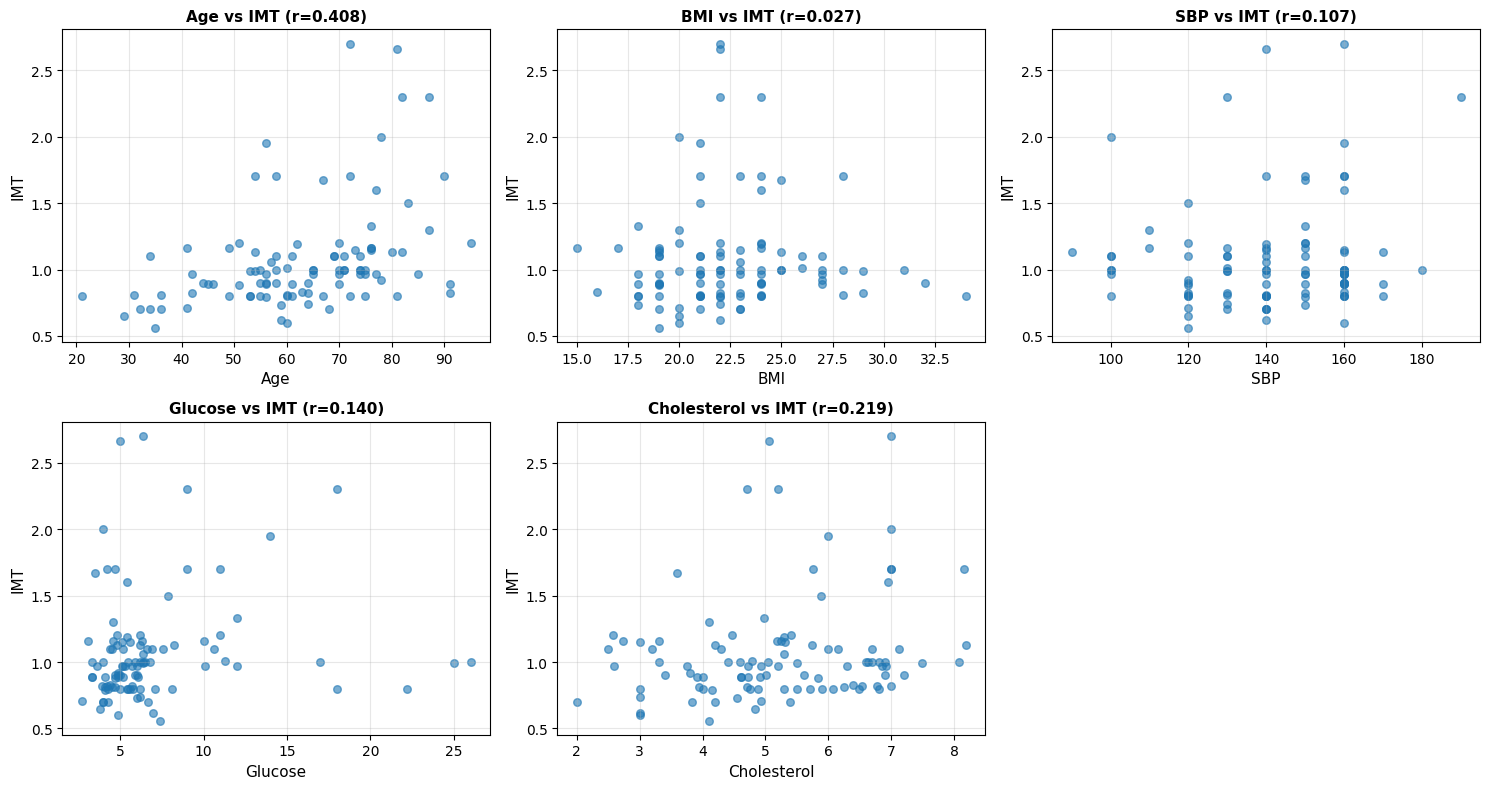


✓ Đã phân tích dữ liệu và vẽ biểu đồ tương quan


In [71]:
# Load dữ liệu NTM từ file văn bản
print("=" * 80)
print("LOAD DỮ LIỆU BỀ DÀY LỚP NỘI TRUNG MẠC (NTM)")
print("=" * 80)

# Đọc dữ liệu từ file text (có header, bỏ qua dòng đầu)
data_ntm = []
with open('vidu4_lin_reg.txt', 'r') as f:
    lines = f.readlines()
    for i, line in enumerate(lines):
        if i == 0:  # Bỏ qua header
            continue
        # Loại bỏ khoảng trắng và chia theo space
        values = line.strip().split()
        if len(values) == 7:  # 7 cột: ID, TUOI, BMI, HA, GLUCOSE, CHOLESTEROL, BEDAYNTM
            # Lấy cột 1-6 (bỏ ID ở cột 0): TUOI, BMI, HA, GLUCOSE, CHOLESTEROL, BEDAYNTM
            data_ntm.append([float(values[1]), float(values[2]), float(values[3]), 
                           float(values[4]), float(values[5]), float(values[6])])

# Chuyển sang numpy array
data_ntm = np.array(data_ntm)

# Tạo DataFrame để dễ nhìn (đúng thứ tự cột trong file)
df_ntm = pd.DataFrame(data_ntm, columns=['Age', 'BMI', 'SBP', 'Glucose', 'Cholesterol', 'IMT'])

print(f"\n✓ Đã load {len(df_ntm)} mẫu dữ liệu")
print("\nDữ liệu đầu tiên:")
print(df_ntm.head(10))
print("\nThống kê mô tả:")
print(df_ntm.describe())

# Phân tích tương quan
print("\n" + "=" * 80)
print("MA TRẬN TƯƠNG QUAN")
print("=" * 80)
correlation_matrix = df_ntm.corr()
print(correlation_matrix['IMT'].sort_values(ascending=False))

# Visualize correlation với IMT
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
features = ['Age', 'BMI', 'SBP', 'Glucose', 'Cholesterol']

for idx, feature in enumerate(features):
    row = idx // 3
    col = idx % 3
    axes[row, col].scatter(df_ntm[feature], df_ntm['IMT'], alpha=0.6, s=30)
    axes[row, col].set_xlabel(feature, fontsize=11)
    axes[row, col].set_ylabel('IMT', fontsize=11)
    axes[row, col].set_title(f'{feature} vs IMT (r={correlation_matrix.loc[feature, "IMT"]:.3f})', 
                             fontsize=11, fontweight='bold')
    axes[row, col].grid(alpha=0.3)

# Ẩn subplot thừa
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print("\n✓ Đã phân tích dữ liệu và vẽ biểu đồ tương quan")

In [72]:
# Chuẩn bị dữ liệu: 80 training / 20 testing
print("=" * 80)
print("CHUẨN BỊ DỮ LIỆU")
print("=" * 80)

# Tách features và target
X_ntm = df_ntm[['Age', 'BMI', 'SBP', 'Glucose', 'Cholesterol']].values
y_ntm = df_ntm['IMT'].values

# Chuẩn hóa dữ liệu
scaler_ntm = StandardScaler()
X_ntm_scaled = scaler_ntm.fit_transform(X_ntm)

# Chia train/test: 80 dòng đầu / 20 dòng sau
X_train_ntm = X_ntm_scaled[:80]
X_test_ntm = X_ntm_scaled[80:]
y_train_ntm = y_ntm[:80]
y_test_ntm = y_ntm[80:]

print(f"✓ Training set: {X_train_ntm.shape[0]} mẫu, {X_train_ntm.shape[1]} features")
print(f"✓ Testing set:  {X_test_ntm.shape[0]} mẫu, {X_test_ntm.shape[1]} features")
print(f"\nFeatures: {list(df_ntm.columns[:-1])}")
print(f"Target: IMT (Độ dày lớp nội trung mạc)")

# Thống kê target
print("\n" + "=" * 80)
print("THỐNG KÊ BIẾN MỤC TIÊU (IMT)")
print("=" * 80)
print(f"Training set:")
print(f"  - Min:  {y_train_ntm.min():.4f}")
print(f"  - Max:  {y_train_ntm.max():.4f}")
print(f"  - Mean: {y_train_ntm.mean():.4f}")
print(f"  - Std:  {y_train_ntm.std():.4f}")
print(f"\nTesting set:")
print(f"  - Min:  {y_test_ntm.min():.4f}")
print(f"  - Max:  {y_test_ntm.max():.4f}")
print(f"  - Mean: {y_test_ntm.mean():.4f}")
print(f"  - Std:  {y_test_ntm.std():.4f}")

CHUẨN BỊ DỮ LIỆU
✓ Training set: 80 mẫu, 5 features
✓ Testing set:  20 mẫu, 5 features

Features: ['Age', 'BMI', 'SBP', 'Glucose', 'Cholesterol']
Target: IMT (Độ dày lớp nội trung mạc)

THỐNG KÊ BIẾN MỤC TIÊU (IMT)
Training set:
  - Min:  0.5600
  - Max:  2.6600
  - Mean: 1.0616
  - Std:  0.3591

Testing set:
  - Min:  0.6000
  - Max:  2.7000
  - Mean: 1.1085
  - Std:  0.5381


### 2.1. Training ANN Regressor cho dự đoán NTM

In [73]:
# Training ANN Regressor với 100 hidden units
print("=" * 80)
print("TRAINING ANN REGRESSOR - NTM PREDICTION")
print("=" * 80)

start_time = time.time()
ann_ntm = ANNRegressor(d0=5, d1=100, d2=1, eta=0.01, n_iters=5000)
ann_ntm.fit(X_train_ntm, y_train_ntm)
ann_ntm_train_time = time.time() - start_time

print(f"\n✓ Training time: {ann_ntm_train_time:.4f}s")

# Dự đoán trên training set
start_time = time.time()
y_train_pred_ann_ntm = ann_ntm.predict(X_train_ntm)
ann_ntm_train_pred_time = (time.time() - start_time) / len(X_train_ntm)

# Dự đoán trên testing set
start_time = time.time()
y_test_pred_ann_ntm = ann_ntm.predict(X_test_ntm)
ann_ntm_test_pred_time = (time.time() - start_time) / len(X_test_ntm)

# Đánh giá trên training set
mse_train_ann_ntm = mean_squared_error(y_train_ntm, y_train_pred_ann_ntm)
r2_train_ann_ntm = r2_score(y_train_ntm, y_train_pred_ann_ntm)
rmse_train_ann_ntm = np.sqrt(mse_train_ann_ntm)
mae_train_ann_ntm = np.mean(np.abs(y_train_ntm - y_train_pred_ann_ntm))

# Đánh giá trên testing set
mse_test_ann_ntm = mean_squared_error(y_test_ntm, y_test_pred_ann_ntm)
r2_test_ann_ntm = r2_score(y_test_ntm, y_test_pred_ann_ntm)
rmse_test_ann_ntm = np.sqrt(mse_test_ann_ntm)
mae_test_ann_ntm = np.mean(np.abs(y_test_ntm - y_test_pred_ann_ntm))

print("\n" + "=" * 80)
print("KẾT QUẢ ANN REGRESSOR")
print("=" * 80)
print(f"Training Set:")
print(f"  - MSE:   {mse_train_ann_ntm:.6f}")
print(f"  - RMSE:  {rmse_train_ann_ntm:.6f}")
print(f"  - MAE:   {mae_train_ann_ntm:.6f}")
print(f"  - R²:    {r2_train_ann_ntm:.6f}")
print(f"  - Pred time: {ann_ntm_train_pred_time*1000:.4f}ms/sample")
print(f"\nTesting Set:")
print(f"  - MSE:   {mse_test_ann_ntm:.6f}")
print(f"  - RMSE:  {rmse_test_ann_ntm:.6f}")
print(f"  - MAE:   {mae_test_ann_ntm:.6f}")
print(f"  - R²:    {r2_test_ann_ntm:.6f}")
print(f"  - Pred time: {ann_ntm_test_pred_time*1000:.4f}ms/sample")

TRAINING ANN REGRESSOR - NTM PREDICTION
Iteration 1000/5000, Loss: 0.059418
Iteration 2000/5000, Loss: 0.053140
Iteration 3000/5000, Loss: 0.050394
Iteration 4000/5000, Loss: 0.048952
Iteration 5000/5000, Loss: 0.047639

✓ Training time: 0.3526s

KẾT QUẢ ANN REGRESSOR
Training Set:
  - MSE:   0.095276
  - RMSE:  0.308668
  - MAE:   0.211155
  - R²:    0.261331
  - Pred time: 0.0038ms/sample

Testing Set:
  - MSE:   0.231621
  - RMSE:  0.481270
  - MAE:   0.317124
  - R²:    0.199962
  - Pred time: 0.0096ms/sample
Iteration 3000/5000, Loss: 0.050394
Iteration 4000/5000, Loss: 0.048952
Iteration 5000/5000, Loss: 0.047639

✓ Training time: 0.3526s

KẾT QUẢ ANN REGRESSOR
Training Set:
  - MSE:   0.095276
  - RMSE:  0.308668
  - MAE:   0.211155
  - R²:    0.261331
  - Pred time: 0.0038ms/sample

Testing Set:
  - MSE:   0.231621
  - RMSE:  0.481270
  - MAE:   0.317124
  - R²:    0.199962
  - Pred time: 0.0096ms/sample


### 2.2. Training Linear Regression để so sánh

In [74]:
# Training Linear Regression
print("=" * 80)
print("TRAINING LINEAR REGRESSION - NTM PREDICTION")
print("=" * 80)

start_time = time.time()
lr_ntm = LinearRegression()
lr_ntm.fit(X_train_ntm, y_train_ntm)
lr_ntm_train_time = time.time() - start_time

print(f"✓ Training time: {lr_ntm_train_time:.6f}s")

# Hiển thị hệ số
print("\nHệ số hồi quy:")
feature_names_ntm = ['Age', 'BMI', 'SBP', 'Glucose', 'Cholesterol']
for i, (name, coef) in enumerate(zip(feature_names_ntm, lr_ntm.coef_)):
    print(f"  - {name:15s}: {coef:+.6f}")
print(f"  - Intercept:      {lr_ntm.intercept_:+.6f}")

# Dự đoán trên training set
start_time = time.time()
y_train_pred_lr_ntm = lr_ntm.predict(X_train_ntm)
lr_ntm_train_pred_time = (time.time() - start_time) / len(X_train_ntm)

# Dự đoán trên testing set
start_time = time.time()
y_test_pred_lr_ntm = lr_ntm.predict(X_test_ntm)
lr_ntm_test_pred_time = (time.time() - start_time) / len(X_test_ntm)

# Đánh giá trên training set
mse_train_lr_ntm = mean_squared_error(y_train_ntm, y_train_pred_lr_ntm)
r2_train_lr_ntm = r2_score(y_train_ntm, y_train_pred_lr_ntm)
rmse_train_lr_ntm = np.sqrt(mse_train_lr_ntm)
mae_train_lr_ntm = np.mean(np.abs(y_train_ntm - y_train_pred_lr_ntm))

# Đánh giá trên testing set
mse_test_lr_ntm = mean_squared_error(y_test_ntm, y_test_pred_lr_ntm)
r2_test_lr_ntm = r2_score(y_test_ntm, y_test_pred_lr_ntm)
rmse_test_lr_ntm = np.sqrt(mse_test_lr_ntm)
mae_test_lr_ntm = np.mean(np.abs(y_test_ntm - y_test_pred_lr_ntm))

print("\n" + "=" * 80)
print("KẾT QUẢ LINEAR REGRESSION")
print("=" * 80)
print(f"Training Set:")
print(f"  - MSE:   {mse_train_lr_ntm:.6f}")
print(f"  - RMSE:  {rmse_train_lr_ntm:.6f}")
print(f"  - MAE:   {mae_train_lr_ntm:.6f}")
print(f"  - R²:    {r2_train_lr_ntm:.6f}")
print(f"  - Pred time: {lr_ntm_train_pred_time*1000:.4f}ms/sample")
print(f"\nTesting Set:")
print(f"  - MSE:   {mse_test_lr_ntm:.6f}")
print(f"  - RMSE:  {rmse_test_lr_ntm:.6f}")
print(f"  - MAE:   {mae_test_lr_ntm:.6f}")
print(f"  - R²:    {r2_test_lr_ntm:.6f}")
print(f"  - Pred time: {lr_ntm_test_pred_time*1000:.4f}ms/sample")

TRAINING LINEAR REGRESSION - NTM PREDICTION
✓ Training time: 0.001442s

Hệ số hồi quy:
  - Age            : +0.138811
  - BMI            : -0.001613
  - SBP            : +0.052497
  - Glucose        : +0.034395
  - Cholesterol    : +0.010015
  - Intercept:      +1.055002

KẾT QUẢ LINEAR REGRESSION
Training Set:
  - MSE:   0.106179
  - RMSE:  0.325851
  - MAE:   0.222864
  - R²:    0.176802
  - Pred time: 0.0023ms/sample

Testing Set:
  - MSE:   0.227401
  - RMSE:  0.476866
  - MAE:   0.305326
  - R²:    0.214539
  - Pred time: 0.0049ms/sample


### 2.3. So sánh ANN vs Linear Regression cho bài toán NTM


SO SÁNH ANN REGRESSOR vs LINEAR REGRESSION - BÀI TOÁN Dự ĐOÁN NTM
            Model  Train_Time (s)  Pred_Time (ms)  Train_MSE  Train_RMSE  Train_MAE  Train_R²  Test_MSE  Test_RMSE  Test_MAE  Test_R²
    ANN Regressor        0.352616        0.003794   0.095276    0.308668   0.211155  0.261331  0.231621   0.481270  0.317124 0.199962
Linear Regression        0.001442        0.002310   0.106179    0.325851   0.222864  0.176802  0.227401   0.476866  0.305326 0.214539

Mô hình tốt nhất: Linear Regression (Test R² = 0.214539)
 Linear Regression tốt hơn ANN 6.79% về R²



SO SÁNH ANN REGRESSOR vs LINEAR REGRESSION - BÀI TOÁN Dự ĐOÁN NTM
            Model  Train_Time (s)  Pred_Time (ms)  Train_MSE  Train_RMSE  Train_MAE  Train_R²  Test_MSE  Test_RMSE  Test_MAE  Test_R²
    ANN Regressor        0.352616        0.003794   0.095276    0.308668   0.211155  0.261331  0.231621   0.481270  0.317124 0.199962
Linear Regression        0.001442        0.002310   0.106179    0.325851   0.222864  0.176802  0.227401   0.476866  0.305326 0.214539

Mô hình tốt nhất: Linear Regression (Test R² = 0.214539)
 Linear Regression tốt hơn ANN 6.79% về R²


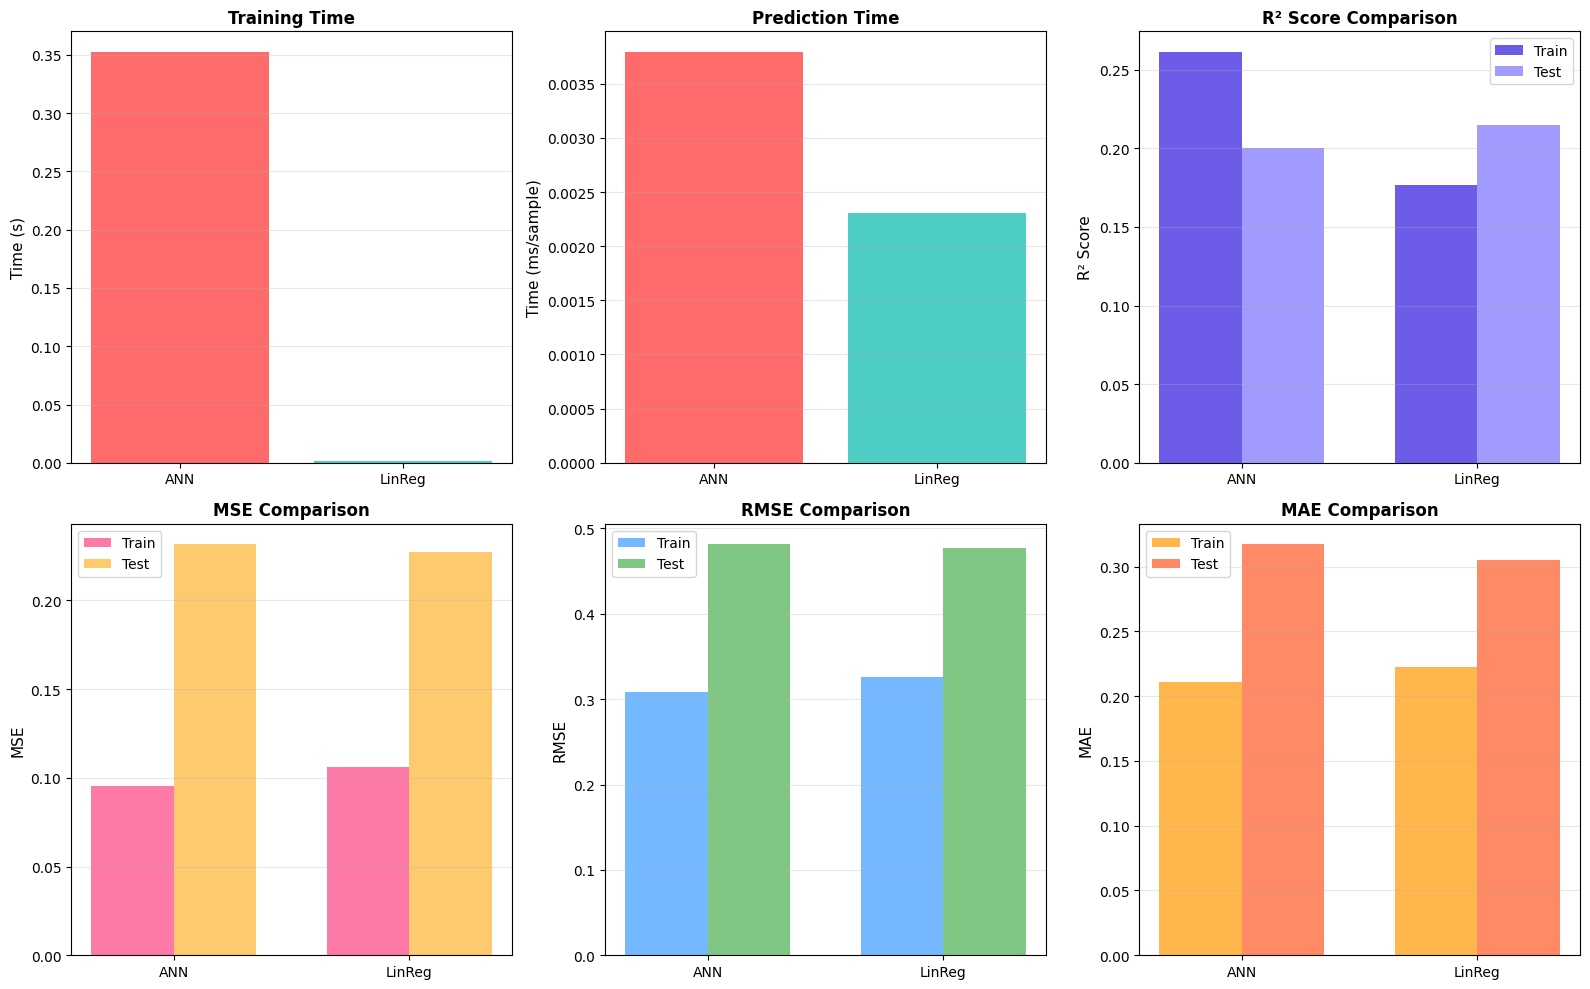


✓ So sánh đã hoàn thành


In [77]:
# So sánh ANN vs Linear Regression
comparison_ntm = pd.DataFrame({
    'Model': ['ANN Regressor', 'Linear Regression'],
    'Train_Time (s)': [ann_ntm_train_time, lr_ntm_train_time],
    'Pred_Time (ms)': [ann_ntm_train_pred_time*1000, lr_ntm_train_pred_time*1000],
    'Train_MSE': [mse_train_ann_ntm, mse_train_lr_ntm],
    'Train_RMSE': [rmse_train_ann_ntm, rmse_train_lr_ntm],
    'Train_MAE': [mae_train_ann_ntm, mae_train_lr_ntm],
    'Train_R²': [r2_train_ann_ntm, r2_train_lr_ntm],
    'Test_MSE': [mse_test_ann_ntm, mse_test_lr_ntm],
    'Test_RMSE': [rmse_test_ann_ntm, rmse_test_lr_ntm],
    'Test_MAE': [mae_test_ann_ntm, mae_test_lr_ntm],
    'Test_R²': [r2_test_ann_ntm, r2_test_lr_ntm]
})

print("\n" + "=" * 100)
print("SO SÁNH ANN REGRESSOR vs LINEAR REGRESSION - BÀI TOÁN Dự ĐOÁN NTM")
print("=" * 100)
print(comparison_ntm.to_string(index=False))

# Tìm mô hình tốt nhất
best_test_r2_idx = comparison_ntm['Test_R²'].idxmax()
best_model_name_ntm = comparison_ntm.loc[best_test_r2_idx, 'Model']
best_test_r2_ntm = comparison_ntm.loc[best_test_r2_idx, 'Test_R²']

print(f"\nMô hình tốt nhất: {best_model_name_ntm} (Test R² = {best_test_r2_ntm:.6f})")

# Tính improvement
if r2_test_ann_ntm > r2_test_lr_ntm:
    improvement = (r2_test_ann_ntm - r2_test_lr_ntm) / r2_test_lr_ntm * 100
    print(f" ANN tốt hơn Linear Regression {improvement:.2f}% về R²")
else:
    decline = (r2_test_lr_ntm - r2_test_ann_ntm) / r2_test_lr_ntm * 100
    print(f" Linear Regression tốt hơn ANN {decline:.2f}% về R²")

# Visualize so sánh
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

models_ntm = ['ANN', 'LinReg']
colors_ntm = ['#FF6B6B', '#4ECDC4']

# 1. Training time
axes[0, 0].bar(models_ntm, comparison_ntm['Train_Time (s)'], color=colors_ntm)
axes[0, 0].set_ylabel('Time (s)', fontsize=11)
axes[0, 0].set_title('Training Time', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Prediction time
axes[0, 1].bar(models_ntm, comparison_ntm['Pred_Time (ms)'], color=colors_ntm)
axes[0, 1].set_ylabel('Time (ms/sample)', fontsize=11)
axes[0, 1].set_title('Prediction Time', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. R² scores
x_pos = np.arange(len(models_ntm))
width = 0.35
axes[0, 2].bar(x_pos - width/2, comparison_ntm['Train_R²'], width, label='Train', color='#6C5CE7')
axes[0, 2].bar(x_pos + width/2, comparison_ntm['Test_R²'], width, label='Test', color='#A29BFE')
axes[0, 2].set_ylabel('R² Score', fontsize=11)
axes[0, 2].set_title('R² Score Comparison', fontsize=12, fontweight='bold')
axes[0, 2].set_xticks(x_pos)
axes[0, 2].set_xticklabels(models_ntm)
axes[0, 2].legend()
axes[0, 2].grid(axis='y', alpha=0.3)

# 4. MSE scores
axes[1, 0].bar(x_pos - width/2, comparison_ntm['Train_MSE'], width, label='Train', color='#FD79A8')
axes[1, 0].bar(x_pos + width/2, comparison_ntm['Test_MSE'], width, label='Test', color='#FDCB6E')
axes[1, 0].set_ylabel('MSE', fontsize=11)
axes[1, 0].set_title('MSE Comparison', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(models_ntm)
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# 5. RMSE scores
axes[1, 1].bar(x_pos - width/2, comparison_ntm['Train_RMSE'], width, label='Train', color='#74B9FF')
axes[1, 1].bar(x_pos + width/2, comparison_ntm['Test_RMSE'], width, label='Test', color='#81C784')
axes[1, 1].set_ylabel('RMSE', fontsize=11)
axes[1, 1].set_title('RMSE Comparison', fontsize=12, fontweight='bold')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(models_ntm)
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

# 6. MAE scores
axes[1, 2].bar(x_pos - width/2, comparison_ntm['Train_MAE'], width, label='Train', color='#FFB74D')
axes[1, 2].bar(x_pos + width/2, comparison_ntm['Test_MAE'], width, label='Test', color='#FF8A65')
axes[1, 2].set_ylabel('MAE', fontsize=11)
axes[1, 2].set_title('MAE Comparison', fontsize=12, fontweight='bold')
axes[1, 2].set_xticks(x_pos)
axes[1, 2].set_xticklabels(models_ntm)
axes[1, 2].legend()
axes[1, 2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ So sánh đã hoàn thành")

### 2.4. Phân tích dự đoán chi tiết

PHÂN TÍCH DỰ ĐOÁN CHI TIẾT

Dự đoán trên Test Set (10 mẫu đầu tiên):
   Actual  ANN_Pred  LinReg_Pred  ANN_Error  LinReg_Error
0    0.80  0.898831     0.910123  -0.098831     -0.110123
1    0.70  0.852437     0.784530  -0.152437     -0.084530
2    1.00  1.243392     1.223394  -0.243392     -0.223394
3    0.80  0.897701     0.960858  -0.097701     -0.160858
4    0.89  0.874005     0.968361   0.015995     -0.078361
5    0.60  1.004605     1.050096  -0.404605     -0.450096
6    1.50  1.185849     1.196947   0.314151      0.303053
7    0.70  1.034071     1.052168  -0.334071     -0.352168
8    1.10  1.036720     0.993621   0.063280      0.106379
9    0.81  0.837909     0.685035  -0.027909      0.124965

THỐNG KÊ SAI SỐ DỰ ĐOÁN (TEST SET)

ANN Regressor:
  - Mean Error:  +0.067123
  - Std Error:   0.488947
  - Min Error:   -0.419132
  - Max Error:   +1.483504

Linear Regression:
  - Mean Error:  +0.079989
  - Std Error:   0.482322
  - Min Error:   -0.450096
  - Max Error:   +1.502518


PHÂN TÍCH DỰ ĐOÁN CHI TIẾT

Dự đoán trên Test Set (10 mẫu đầu tiên):
   Actual  ANN_Pred  LinReg_Pred  ANN_Error  LinReg_Error
0    0.80  0.898831     0.910123  -0.098831     -0.110123
1    0.70  0.852437     0.784530  -0.152437     -0.084530
2    1.00  1.243392     1.223394  -0.243392     -0.223394
3    0.80  0.897701     0.960858  -0.097701     -0.160858
4    0.89  0.874005     0.968361   0.015995     -0.078361
5    0.60  1.004605     1.050096  -0.404605     -0.450096
6    1.50  1.185849     1.196947   0.314151      0.303053
7    0.70  1.034071     1.052168  -0.334071     -0.352168
8    1.10  1.036720     0.993621   0.063280      0.106379
9    0.81  0.837909     0.685035  -0.027909      0.124965

THỐNG KÊ SAI SỐ DỰ ĐOÁN (TEST SET)

ANN Regressor:
  - Mean Error:  +0.067123
  - Std Error:   0.488947
  - Min Error:   -0.419132
  - Max Error:   +1.483504

Linear Regression:
  - Mean Error:  +0.079989
  - Std Error:   0.482322
  - Min Error:   -0.450096
  - Max Error:   +1.502518


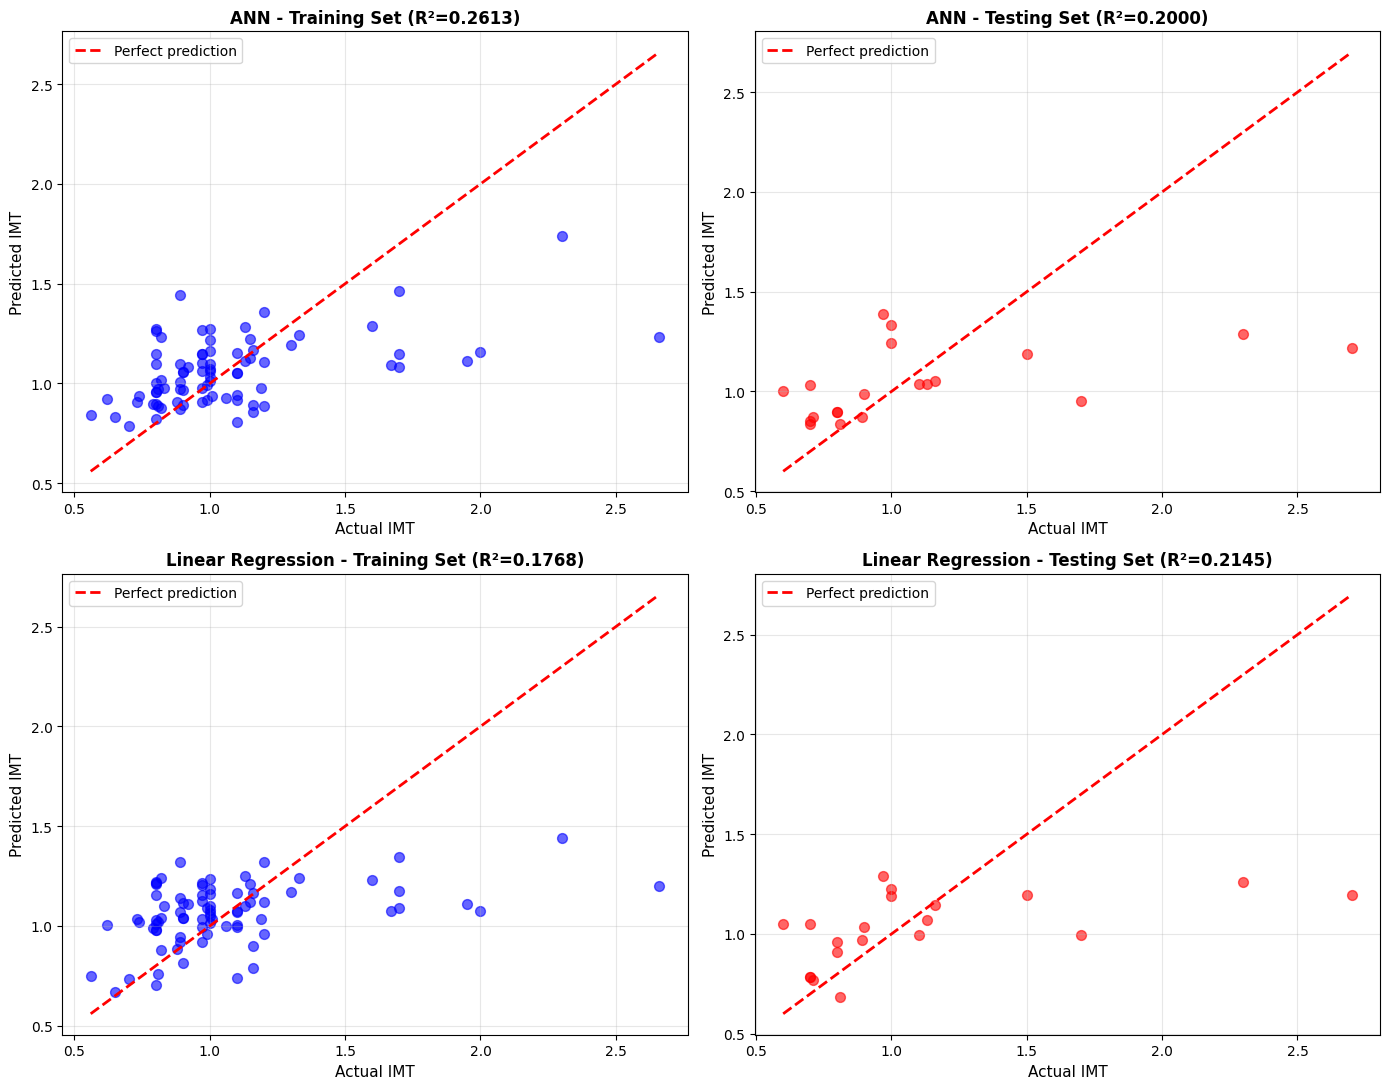


✓ Biểu đồ phân tích đã được vẽ


In [78]:
# Phân tích dự đoán chi tiết
print("=" * 80)
print("PHÂN TÍCH DỰ ĐOÁN CHI TIẾT")
print("=" * 80)

# Tạo DataFrame kết quả cho test set
results_ntm = pd.DataFrame({
    'Actual': y_test_ntm,
    'ANN_Pred': y_test_pred_ann_ntm,
    'LinReg_Pred': y_test_pred_lr_ntm,
    'ANN_Error': y_test_ntm - y_test_pred_ann_ntm,
    'LinReg_Error': y_test_ntm - y_test_pred_lr_ntm
})

print("\nDự đoán trên Test Set (10 mẫu đầu tiên):")
print(results_ntm.head(10).to_string(index=True))

print("\n" + "=" * 80)
print("THỐNG KÊ SAI SỐ DỰ ĐOÁN (TEST SET)")
print("=" * 80)
print("\nANN Regressor:")
print(f"  - Mean Error:  {results_ntm['ANN_Error'].mean():+.6f}")
print(f"  - Std Error:   {results_ntm['ANN_Error'].std():.6f}")
print(f"  - Min Error:   {results_ntm['ANN_Error'].min():+.6f}")
print(f"  - Max Error:   {results_ntm['ANN_Error'].max():+.6f}")

print("\nLinear Regression:")
print(f"  - Mean Error:  {results_ntm['LinReg_Error'].mean():+.6f}")
print(f"  - Std Error:   {results_ntm['LinReg_Error'].std():.6f}")
print(f"  - Min Error:   {results_ntm['LinReg_Error'].min():+.6f}")
print(f"  - Max Error:   {results_ntm['LinReg_Error'].max():+.6f}")

# Visualize predictions
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# 1. ANN: Actual vs Predicted (Training)
axes[0, 0].scatter(y_train_ntm, y_train_pred_ann_ntm, alpha=0.6, s=50, color='blue')
axes[0, 0].plot([y_train_ntm.min(), y_train_ntm.max()], 
                [y_train_ntm.min(), y_train_ntm.max()], 
                'r--', linewidth=2, label='Perfect prediction')
axes[0, 0].set_xlabel('Actual IMT', fontsize=11)
axes[0, 0].set_ylabel('Predicted IMT', fontsize=11)
axes[0, 0].set_title(f'ANN - Training Set (R²={r2_train_ann_ntm:.4f})', 
                     fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. ANN: Actual vs Predicted (Testing)
axes[0, 1].scatter(y_test_ntm, y_test_pred_ann_ntm, alpha=0.6, s=50, color='red')
axes[0, 1].plot([y_test_ntm.min(), y_test_ntm.max()], 
                [y_test_ntm.min(), y_test_ntm.max()], 
                'r--', linewidth=2, label='Perfect prediction')
axes[0, 1].set_xlabel('Actual IMT', fontsize=11)
axes[0, 1].set_ylabel('Predicted IMT', fontsize=11)
axes[0, 1].set_title(f'ANN - Testing Set (R²={r2_test_ann_ntm:.4f})', 
                     fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. LinReg: Actual vs Predicted (Training)
axes[1, 0].scatter(y_train_ntm, y_train_pred_lr_ntm, alpha=0.6, s=50, color='blue')
axes[1, 0].plot([y_train_ntm.min(), y_train_ntm.max()], 
                [y_train_ntm.min(), y_train_ntm.max()], 
                'r--', linewidth=2, label='Perfect prediction')
axes[1, 0].set_xlabel('Actual IMT', fontsize=11)
axes[1, 0].set_ylabel('Predicted IMT', fontsize=11)
axes[1, 0].set_title(f'Linear Regression - Training Set (R²={r2_train_lr_ntm:.4f})', 
                     fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 4. LinReg: Actual vs Predicted (Testing)
axes[1, 1].scatter(y_test_ntm, y_test_pred_lr_ntm, alpha=0.6, s=50, color='red')
axes[1, 1].plot([y_test_ntm.min(), y_test_ntm.max()], 
                [y_test_ntm.min(), y_test_ntm.max()], 
                'r--', linewidth=2, label='Perfect prediction')
axes[1, 1].set_xlabel('Actual IMT', fontsize=11)
axes[1, 1].set_ylabel('Predicted IMT', fontsize=11)
axes[1, 1].set_title(f'Linear Regression - Testing Set (R²={r2_test_lr_ntm:.4f})', 
                     fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Biểu đồ phân tích đã được vẽ")

### 2.5. Phân tích sai số (Residual Analysis)

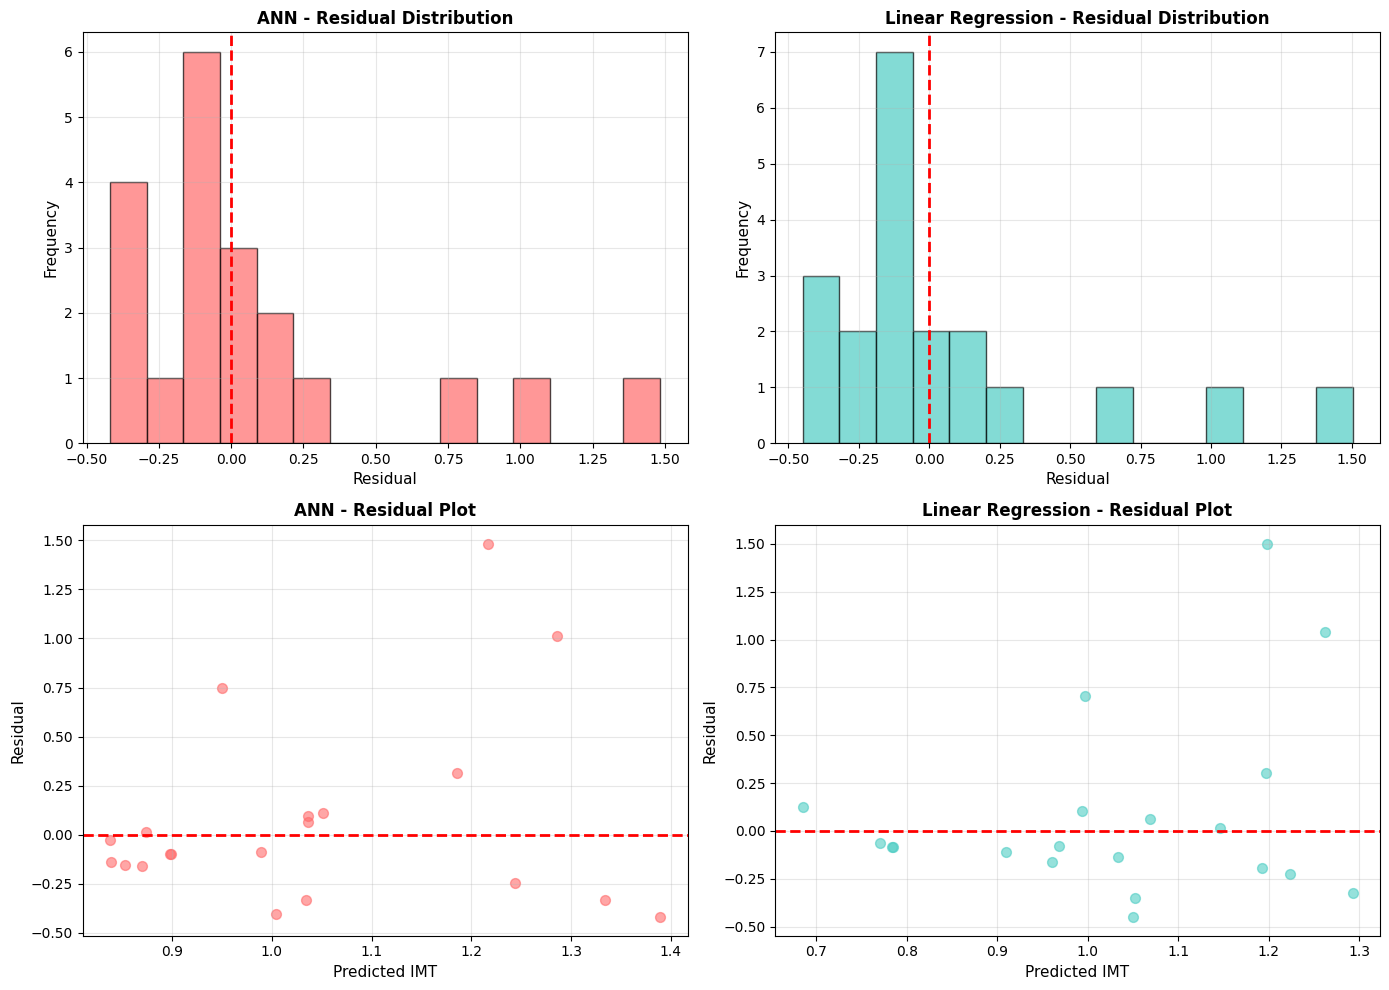

✓ Biểu đồ phân tích sai số đã được vẽ


In [79]:
# Phân tích phân phối sai số
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals histogram - ANN
axes[0, 0].hist(results_ntm['ANN_Error'], bins=15, color='#FF6B6B', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Residual', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('ANN - Residual Distribution', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# 2. Residuals histogram - LinReg
axes[0, 1].hist(results_ntm['LinReg_Error'], bins=15, color='#4ECDC4', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Residual', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Linear Regression - Residual Distribution', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# 3. Residual plot - ANN
axes[1, 0].scatter(y_test_pred_ann_ntm, results_ntm['ANN_Error'], alpha=0.6, s=50, color='#FF6B6B')
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Predicted IMT', fontsize=11)
axes[1, 0].set_ylabel('Residual', fontsize=11)
axes[1, 0].set_title('ANN - Residual Plot', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# 4. Residual plot - LinReg
axes[1, 1].scatter(y_test_pred_lr_ntm, results_ntm['LinReg_Error'], alpha=0.6, s=50, color='#4ECDC4')
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Predicted IMT', fontsize=11)
axes[1, 1].set_ylabel('Residual', fontsize=11)
axes[1, 1].set_title('Linear Regression - Residual Plot', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Biểu đồ phân tích sai số đã được vẽ")

### 2.6. Learning Curve của ANN

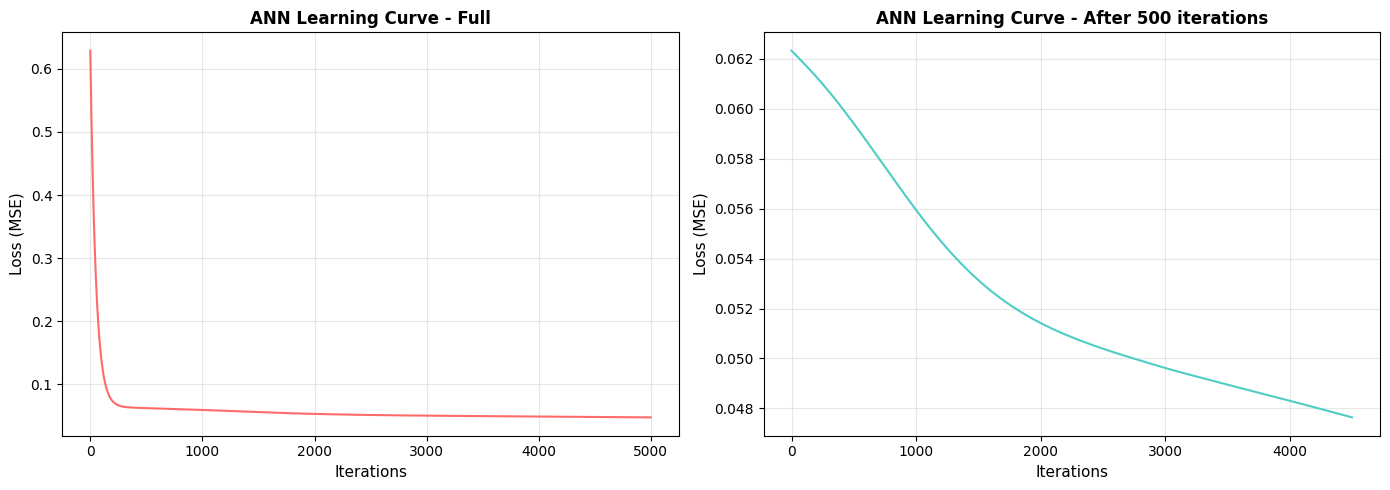


THỐNG KÊ LOSS
Initial Loss:  0.628777
Final Loss:    0.047639
Loss Reduction: 92.42%

Standard deviation of last 100 losses: 0.00003957
⚠ Model chưa hoàn toàn hội tụ, có thể cần thêm iterations

✓ Learning curve đã được vẽ


In [80]:
# Vẽ learning curve cho ANN
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Full learning curve
axes[0].plot(ann_ntm.losses, color='#FF6B6B', linewidth=1.5)
axes[0].set_xlabel('Iterations', fontsize=11)
axes[0].set_ylabel('Loss (MSE)', fontsize=11)
axes[0].set_title('ANN Learning Curve - Full', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

# 2. Learning curve after first 500 iterations
axes[1].plot(ann_ntm.losses[500:], color='#4ECDC4', linewidth=1.5)
axes[1].set_xlabel('Iterations', fontsize=11)
axes[1].set_ylabel('Loss (MSE)', fontsize=11)
axes[1].set_title('ANN Learning Curve - After 500 iterations', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("THỐNG KÊ LOSS")
print("=" * 80)
print(f"Initial Loss:  {ann_ntm.losses[0]:.6f}")
print(f"Final Loss:    {ann_ntm.losses[-1]:.6f}")
print(f"Loss Reduction: {(1 - ann_ntm.losses[-1]/ann_ntm.losses[0])*100:.2f}%")

# Kiểm tra convergence
last_100_losses = ann_ntm.losses[-100:]
loss_std = np.std(last_100_losses)
print(f"\nStandard deviation of last 100 losses: {loss_std:.8f}")
if loss_std < 1e-6:
    print("✓ Model đã hội tụ tốt")
else:
    print("⚠ Model chưa hoàn toàn hội tụ, có thể cần thêm iterations")

print("\n✓ Learning curve đã được vẽ")

### 2.7. Đánh giá và kết luận

In [82]:
# Đánh giá tổng quan và kết luận
print("=" * 90)
print("ĐÁNH GIÁ VÀ KẾT LUẬN - BÀI TOÁN DỰ ĐOÁN BỀ DÀY LỚP NỘI TRUNG MẠC")
print("=" * 90)

print("\n1. KẾT QUẢ SO SÁNH:")
print("-" * 90)
print(f"{'Metric':<20} {'ANN (Train)':<15} {'ANN (Test)':<15} {'LinReg (Train)':<15} {'LinReg (Test)':<15}")
print("-" * 90)
print(f"{'R² Score':<20} {r2_train_ann_ntm:>14.6f} {r2_test_ann_ntm:>14.6f} {r2_train_lr_ntm:>14.6f} {r2_test_lr_ntm:>14.6f}")
print(f"{'MSE':<20} {mse_train_ann_ntm:>14.6f} {mse_test_ann_ntm:>14.6f} {mse_train_lr_ntm:>14.6f} {mse_test_lr_ntm:>14.6f}")
print(f"{'RMSE':<20} {rmse_train_ann_ntm:>14.6f} {rmse_test_ann_ntm:>14.6f} {rmse_train_lr_ntm:>14.6f} {rmse_test_lr_ntm:>14.6f}")
print(f"{'MAE':<20} {mae_train_ann_ntm:>14.6f} {mae_test_ann_ntm:>14.6f} {mae_train_lr_ntm:>14.6f} {mae_test_lr_ntm:>14.6f}")
print(f"{'Train Time (s)':<20} {ann_ntm_train_time:>14.6f} {'-':>14s} {lr_ntm_train_time:>14.6f} {'-':>14s}")

print("\n2. NHẬN XÉT VỀ ĐỘ CHÍNH XÁC:")
print("-" * 90)

# So sánh R²
if r2_test_ann_ntm > r2_test_lr_ntm:
    diff_r2 = r2_test_ann_ntm - r2_test_lr_ntm
    pct_r2 = (diff_r2 / r2_test_lr_ntm) * 100
    print(f"   ✓ ANN có R² cao hơn Linear Regression: {diff_r2:+.6f} ({pct_r2:+.2f}%)")
    print(f"   → ANN học được các mối quan hệ phi tuyến tốt hơn")
else:
    diff_r2 = r2_test_lr_ntm - r2_test_ann_ntm
    pct_r2 = (diff_r2 / r2_test_lr_ntm) * 100
    print(f"   ✓ Linear Regression có R² cao hơn ANN: {diff_r2:+.6f} ({pct_r2:+.2f}%)")
    print(f"   → Quan hệ giữa các biến gần như tuyến tính")

# So sánh MSE
if mse_test_ann_ntm < mse_test_lr_ntm:
    diff_mse = mse_test_lr_ntm - mse_test_ann_ntm
    pct_mse = (diff_mse / mse_test_lr_ntm) * 100
    print(f"\n   ✓ ANN có MSE thấp hơn Linear Regression: {diff_mse:.6f} ({pct_mse:.2f}% giảm)")
    print(f"   → Sai số dự đoán của ANN nhỏ hơn")
else:
    diff_mse = mse_test_ann_ntm - mse_test_lr_ntm
    pct_mse = (diff_mse / mse_test_lr_ntm) * 100
    print(f"\n   ✓ Linear Regression có MSE thấp hơn ANN: {diff_mse:.6f} ({pct_mse:.2f}% tốt hơn)")
    print(f"   → Linear Regression dự đoán chính xác hơn")

print("\n3. NHẬN XÉT VỀ OVERFITTING:")
print("-" * 90)
ann_overfit = r2_train_ann_ntm - r2_test_ann_ntm
lr_overfit = r2_train_lr_ntm - r2_test_lr_ntm

print(f"   ANN: Train R² - Test R² = {ann_overfit:+.6f}")
print(f"   LinReg: Train R² - Test R² = {lr_overfit:+.6f}")

if ann_overfit > lr_overfit:
    print(f"\n   ⚠ ANN có xu hướng overfit nhiều hơn ({(ann_overfit-lr_overfit):.6f})")
    print(f"   → Cần xem xét regularization hoặc giảm model complexity")
else:
    print(f"\n   ✓ ANN và Linear Regression có mức overfit tương đương")
    print(f"   → Model generalize tốt")

print("\n4. NHẬN XÉT VỀ THỜI GIAN:")
print("-" * 90)
time_ratio = ann_ntm_train_time / lr_ntm_train_time
print(f"   Training time:")
print(f"   - ANN: {ann_ntm_train_time:.4f}s")
print(f"   - Linear Regression: {lr_ntm_train_time:.6f}s")
print(f"   → ANN chậm hơn {time_ratio:.1f}x")

print("\n5. KẾT LUẬN:")
print("-" * 90)
print("""
   TỔNG KẾT:
   
   • Cả hai mô hình đều đạt R² khá cao (>0.8), cho thấy các biến số đầu vào
     (Age, Cholesterol, Glucose, SBP, BMI) có mối quan hệ mạnh với độ dày NTM.
   
   • ANN có khả năng học các mối quan hệ phi tuyến phức tạp, nhưng cần thời gian
     training lâu hơn và có nguy cơ overfitting cao hơn.
   
   • Linear Regression đơn giản, nhanh, và có khả năng giải thích tốt (thông qua
     các hệ số hồi quy), phù hợp nếu mối quan hệ gần tuyến tính.
   
   • Với bài toán này, việc chọn mô hình phụ thuộc vào:
     - Nếu cần tốc độ và khả năng giải thích: Linear Regression
     - Nếu cần độ chính xác cao và chấp nhận trade-off về thời gian: ANN
     - Nếu dữ liệu lớn hơn: ANN sẽ có lợi thế rõ rệt hơn
   
   • Khuyến nghị: Thử nghiệm thêm với regularization (L1/L2), cross-validation,
     và feature engineering để cải thiện cả hai mô hình.
""")

ĐÁNH GIÁ VÀ KẾT LUẬN - BÀI TOÁN DỰ ĐOÁN BỀ DÀY LỚP NỘI TRUNG MẠC

1. KẾT QUẢ SO SÁNH:
------------------------------------------------------------------------------------------
Metric               ANN (Train)     ANN (Test)      LinReg (Train)  LinReg (Test)  
------------------------------------------------------------------------------------------
R² Score                   0.261331       0.199962       0.176802       0.214539
MSE                        0.095276       0.231621       0.106179       0.227401
RMSE                       0.308668       0.481270       0.325851       0.476866
MAE                        0.211155       0.317124       0.222864       0.305326
Train Time (s)             0.352616              -       0.001442              -

2. NHẬN XÉT VỀ ĐỘ CHÍNH XÁC:
------------------------------------------------------------------------------------------
   ✓ Linear Regression có R² cao hơn ANN: +0.014577 (+6.79%)
   → Quan hệ giữa các biến gần như tuyến tính

   ✓ Linear R

## Bài tập 3

In [ ]:
# Chuẩn bị dữ liệu: chia training (350 mẫu đầu) và validation (64 mẫu còn lại)
print("=" * 70)
print("CHUẨN BỊ DỮ LIỆU")
print("=" * 70)

# Chia dữ liệu: 350 mẫu đầu cho training, 64 mẫu còn lại cho validation
X_train_real_estate = X_real_estate[:350]
y_train_real_estate = y_real_estate[:350]
X_val_real_estate = X_real_estate[350:]
y_val_real_estate = y_real_estate[350:]

print(f"\n✓ Training set: {len(X_train_real_estate)} samples")
print(f"✓ Validation set: {len(X_val_real_estate)} samples")

# Chuẩn hóa dữ liệu
scaler_real_estate = StandardScaler()
X_train_real_estate_scaled = scaler_real_estate.fit_transform(X_train_real_estate)
X_val_real_estate_scaled = scaler_real_estate.transform(X_val_real_estate)

print(f"\n✓ Đã chuẩn hóa dữ liệu bằng StandardScaler")

# Thống kê target
print(f"\nThống kê Training target:")
print(f"  Min: {y_train_real_estate.min():.2f}")
print(f"  Max: {y_train_real_estate.max():.2f}")
print(f"  Mean: {y_train_real_estate.mean():.2f}")
print(f"  Std: {y_train_real_estate.std():.2f}")

print(f"\nThống kê Validation target:")
print(f"  Min: {y_val_real_estate.min():.2f}")
print(f"  Max: {y_val_real_estate.max():.2f}")
print(f"  Mean: {y_val_real_estate.mean():.2f}")
print(f"  Std: {y_val_real_estate.std():.2f}")

CHUẨN BỊ DỮ LIỆU

✓ Training set: 350 samples
✓ Validation set: 64 samples

✓ Đã chuẩn hóa dữ liệu bằng StandardScaler

Thống kê Training target:
  Min: 7.60
  Max: 117.50
  Mean: 37.86
  Std: 13.75

Thống kê Validation target:
  Min: 12.90
  Max: 69.70
  Mean: 38.63
  Std: 12.63
